In [15]:
# Instalar mrmr-selection se não estiver instalado
# !pip install mrmr-selection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from scipy.stats import pearsonr
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.svm import LinearSVC, SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LassoCV, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import log_loss as sk_log_loss, matthews_corrcoef
from sklearn.ensemble import VotingClassifier

# Seleção de features mRMR
try:
    from mrmr import mrmr_classif
    MRMR_AVAILABLE = True
except ImportError:
    MRMR_AVAILABLE = False
    print("⚠️ mRMR não está instalado. Instale com: pip install mrmr-selection")

# Sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import VarianceThreshold

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


# Análise de Outliers

Identificação e tratamento de outliers nas colunas numéricas do dataset usando o método IQR (Interquartile Range).

In [16]:
# Carregar o dataset DoS_with_gap_features
dos_path = Path("../data/processed/DoS_with_gap_features.csv")
df = pd.read_csv(dos_path)

# Selecionar apenas colunas numéricas para análise de outliers
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Shape do dataset: {df.shape}")
print(f"Colunas numéricas encontradas: {len(numeric_cols)}")
print(numeric_cols)

Shape do dataset: (94625, 67)
Colunas numéricas encontradas: 55
['frame.time_delta', 'frame.time_delta_displayed', 'frame.time_epoch', 'frame.time_invalid', 'frame.time_relative', 'tcp.srcport', 'tcp.dstport', 'frame.cap_len', 'frame.coloring_rule.name', 'frame.coloring_rule.string', 'frame.comment', 'frame.comment.expert', 'frame.encap_type', 'frame.file_off', 'frame.ignored', 'frame.incomplete', 'frame.interface_id', 'frame.interface_name', 'frame.len', 'frame.link_nr', 'frame.marked', 'frame.md5_hash', 'frame.number', 'frame.offset_shift', 'mqtt.clientid_len', 'mqtt.conack.flags.reserved', 'mqtt.conack.flags.sp', 'mqtt.conack.val', 'mqtt.conflag.cleansess', 'mqtt.conflag.passwd', 'mqtt.conflag.qos', 'mqtt.conflag.reserved', 'mqtt.conflag.retain', 'mqtt.conflag.uname', 'mqtt.conflag.willflag', 'mqtt.dupflag', 'mqtt.kalive', 'mqtt.len', 'mqtt.msgid', 'mqtt.msgtype', 'mqtt.passwd', 'mqtt.passwd_len', 'mqtt.qos', 'mqtt.retain', 'mqtt.sub.qos', 'mqtt.suback.qos', 'mqtt.topic_len', 'mqtt.

In [17]:
# Função para detectar outliers usando IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < limite_inferior) | (df[column] > limite_superior)]
    
    return {
        'coluna': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'n_outliers': len(outliers),
        'pct_outliers': (len(outliers) / len(df)) * 100
    }

# Analisar outliers em todas as colunas numéricas
outliers_summary = []
for col in numeric_cols:
    result = detect_outliers_iqr(df, col)
    outliers_summary.append(result)

# Criar DataFrame com resumo dos outliers
outliers_df = pd.DataFrame(outliers_summary)
outliers_df = outliers_df.sort_values('pct_outliers', ascending=False)
print("Resumo de Outliers por Coluna (ordenado por % de outliers):")
outliers_df

Resumo de Outliers por Coluna (ordenado por % de outliers):


,coluna,Q1,Q3,IQR,limite_inferior,limite_superior,n_outliers,pct_outliers
0,frame.time_delta,6.200000e-05,7.810000e-04,0.000719,-1.016500e-03,1.859500e-03,14774,15.613210
1,frame.time_delta_displayed,6.200000e-05,7.810000e-04,0.000719,-1.016500e-03,1.859500e-03,14774,15.613210
37,mqtt.len,1.600000e+02,1.680000e+02,8.000000,1.480000e+02,1.800000e+02,2159,2.281638
39,mqtt.msgtype,3.000000e+00,3.000000e+00,0.000000,3.000000e+00,3.000000e+00,1672,1.766975
46,mqtt.topic_len,6.200000e+01,6.300000e+01,1.000000,6.050000e+01,6.450000e+01,1148,1.213210
42,mqtt.qos,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,528,0.557992
43,mqtt.retain,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,397,0.419551
35,mqtt.dupflag,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,188,0.198679
54,connect_gap,-2.612005e-01,2.331171e-01,0.494318,-1.002677e+00,9.745936e-01,157,0.165918
36,mqtt.kalive,6.000000e+01,6.000000e+01,0.000000,6.000000e+01,6.000000e+01,15,0.015852


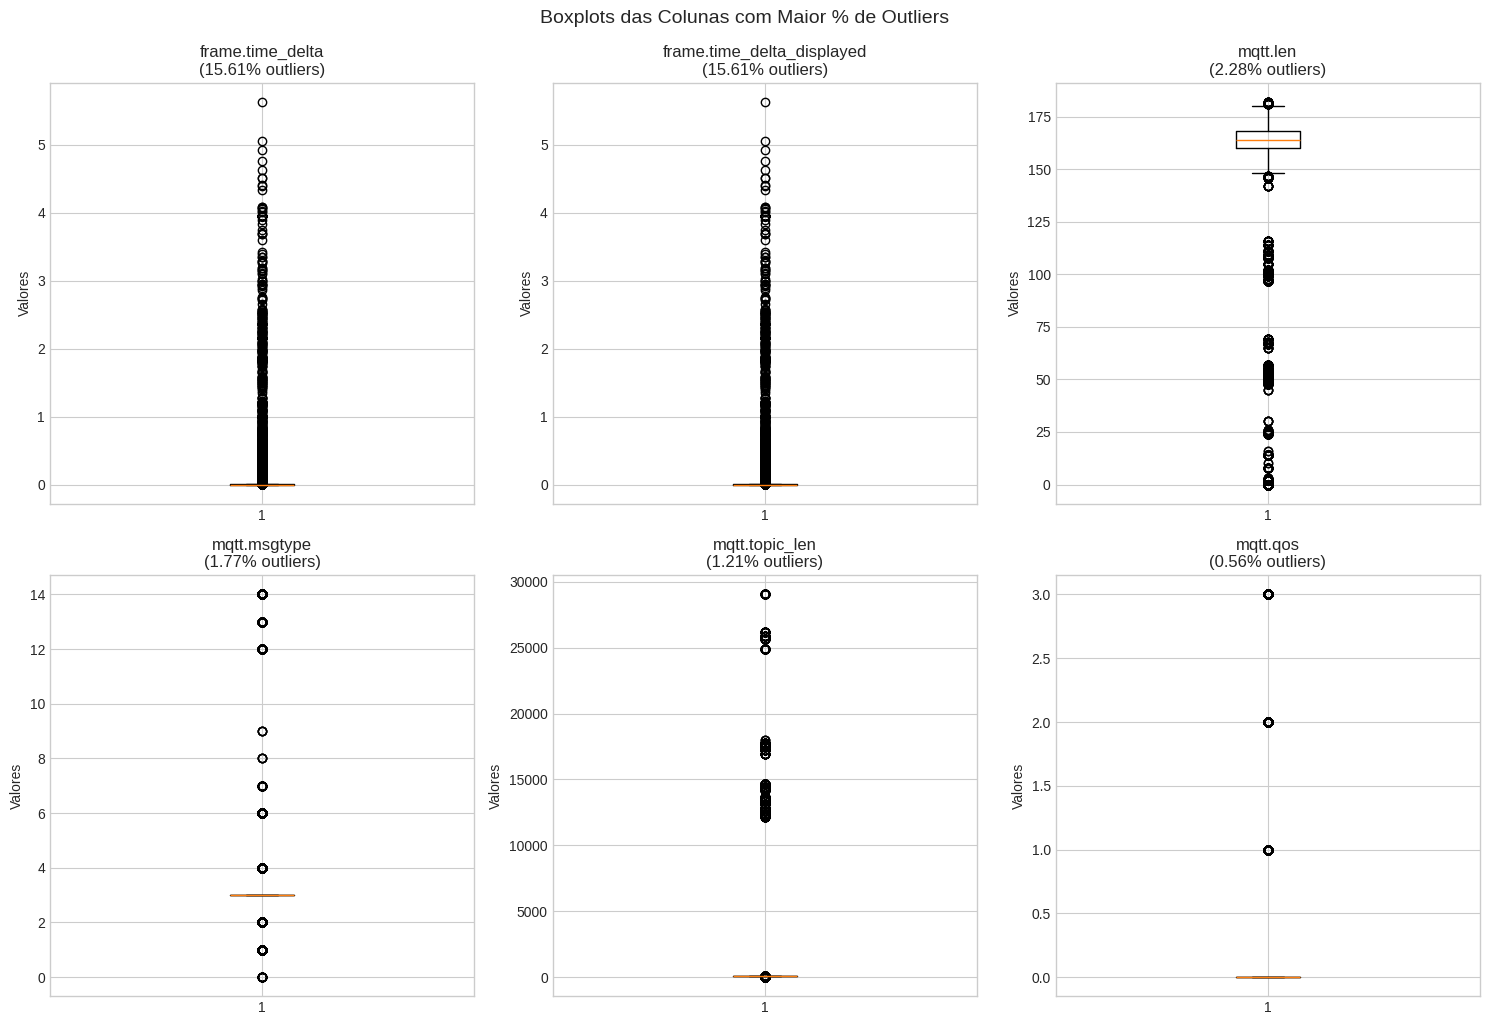

In [18]:
# Visualizar boxplots das colunas com maior % de outliers
top_outlier_cols = outliers_df.head(6)['coluna'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(top_outlier_cols):
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(f'{col}\n({outliers_df[outliers_df["coluna"]==col]["pct_outliers"].values[0]:.2f}% outliers)')
    axes[idx].set_ylabel('Valores')

plt.tight_layout()
plt.suptitle('Boxplots das Colunas com Maior % de Outliers', y=1.02, fontsize=14)
plt.show()

## Tratamento de Outliers

Opções disponíveis:
1. **Remoção**: Remove as linhas com outliers (pode reduzir muito o dataset)
2. **Winsorização**: Substitui outliers pelos limites (percentis)
3. **Capping**: Similar à winsorização, usa os limites do IQR

In [19]:
# Função para tratar outliers com capping (limitar aos limites do IQR)
def cap_outliers_iqr(df, columns):
    df_capped = df.copy()
    
    for col in columns:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        
        # Aplicar capping
        df_capped[col] = df_capped[col].clip(lower=limite_inferior, upper=limite_superior)
    
    return df_capped

# Aplicar tratamento nas colunas numéricas
df_tratado = cap_outliers_iqr(df, numeric_cols)

print(f"Shape original: {df.shape}")
print(f"Shape após tratamento: {df_tratado.shape}")
print("\nVerificação - Outliers após tratamento:")

# Verificar se ainda há outliers
for col in top_outlier_cols[:3]:
    result_antes = detect_outliers_iqr(df, col)
    result_depois = detect_outliers_iqr(df_tratado, col)
    print(f"{col}: {result_antes['n_outliers']} -> {result_depois['n_outliers']} outliers")

Shape original: (94625, 67)
Shape após tratamento: (94625, 67)

Verificação - Outliers após tratamento:
frame.time_delta: 14774 -> 0 outliers
frame.time_delta_displayed: 14774 -> 0 outliers
mqtt.len: 2159 -> 0 outliers


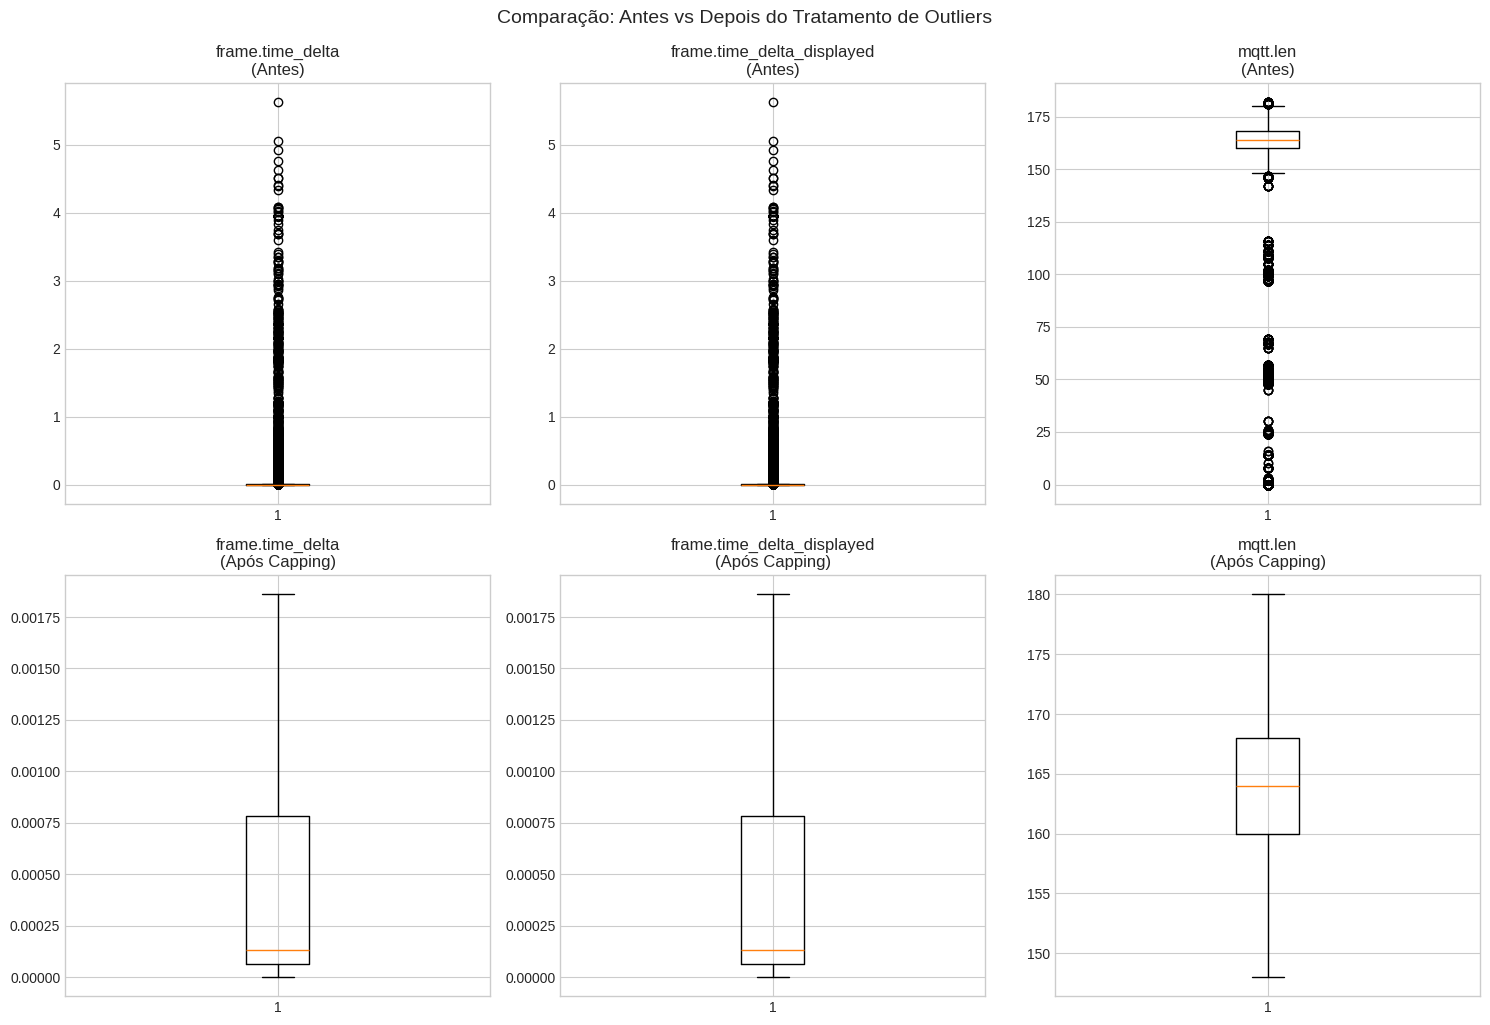

In [20]:
# Comparação visual antes e depois do tratamento
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, col in enumerate(top_outlier_cols[:3]):
    # Antes
    axes[0, idx].boxplot(df[col].dropna())
    axes[0, idx].set_title(f'{col}\n(Antes)')
    
    # Depois
    axes[1, idx].boxplot(df_tratado[col].dropna())
    axes[1, idx].set_title(f'{col}\n(Após Capping)')

plt.tight_layout()
plt.suptitle('Comparação: Antes vs Depois do Tratamento de Outliers', y=1.02, fontsize=14)
plt.show()

In [23]:
df_tratado.isna().mean().sort_values(ascending=False)

frame.coloring_rule.string    1.0
frame.comment                 1.0
frame.time_invalid            1.0
mqtt.username                 1.0
mqtt.willmsg_len              1.0
                             ... 
frame.number                  0.0
eth.dst                       0.0
frame.cap_len                 0.0
frame.encap_type              0.0
type                          0.0
Length: 67, dtype: float64

In [ ]:
# Salvar dataset tratado (descomente para executar)
# output_path = Path("../data/processed/DoS_with_gap_features_no_outliers.csv")
# df_tratado.to_csv(output_path, index=False)
# print(f"Dataset salvo em: {output_path}")

## Preparação das Features

Remoção de colunas irrelevantes e encoding do label para treinamento do modelo.

In [27]:
from sklearn.preprocessing import LabelEncoder

# Selecionar apenas features numéricas do df_tratado
num_df = df_tratado.select_dtypes(include=['int64', 'float64'])

# Colunas a remover (irrelevantes para detecção de ataques)
colunas_para_remover = [
    'frame.time_delta_displayed', 'frame.time_epoch', 'frame.time_invalid', 
    'frame.time_relative', 'tcp.srcport', 'tcp.dstport', 
    'frame.coloring_rule.name', 'frame.coloring_rule.string', 
    'frame.comment', 'frame.comment.expert', 'frame.encap_type', 
    'frame.file_off', 'frame.ignored', 'frame.incomplete', 
    'frame.interface_id', 'frame.interface_name', 'frame.link_nr', 
    'frame.marked', 'frame.md5_hash', 'frame.number', 'frame.offset_shift',
    'mqtt.msgid', 'mqtt.username', 'mqtt.passwd', 
    'mqtt.willmsg', 'mqtt.willtopic'
]

# Remover colunas existentes no dataframe
colunas_existentes = [c for c in colunas_para_remover if c in num_df.columns]
X = num_df.drop(columns=colunas_existentes, errors='ignore')

# Tratar valores ausentes e infinitos
X = X.fillna(0)
X = X.replace([np.inf, -np.inf], 0)

# Encode do label (target)
le = LabelEncoder()
y = le.fit_transform(df_tratado['type'])

print(f"Features numéricas após limpeza: {X.shape[1]}")
print(f"Classes: {le.classes_}")
print(f"Shape X: {X.shape}, y: {y.shape}")

Features numéricas após limpeza: 29
Classes: ['DoS' 'normal']
Shape X: (94625, 29), y: (94625,)


In [28]:
X.describe()

,frame.time_delta,frame.cap_len,frame.len,mqtt.clientid_len,mqtt.conack.flags.reserved,mqtt.conack.flags.sp,mqtt.conack.val,mqtt.conflag.cleansess,mqtt.conflag.passwd,mqtt.conflag.qos,mqtt.conflag.reserved,mqtt.conflag.retain,mqtt.conflag.uname,mqtt.conflag.willflag,mqtt.dupflag,mqtt.kalive,mqtt.len,mqtt.msgtype,mqtt.passwd_len,mqtt.qos,mqtt.retain,mqtt.sub.qos,mqtt.suback.qos,mqtt.topic_len,mqtt.username_len,mqtt.willmsg_len,mqtt.willtopic_len,publish_gap,connect_gap
count,94625.000000,94625.000000,94625.000000,94625.000000,94625.000000,94625.000000,94625.000000,94625.000000,94625.0,94625.0,94625.0,94625.0,94625.0,94625.0,94625.0,94625.000000,94625.000000,94625.000000,94625.0,94625.0,94625.0,94625.0,94625.0,94625.000000,94625.0,94625.0,94625.0,94625.000000,94625.000000
mean,0.000528,972.513828,972.513828,0.127054,0.004713,0.003065,0.403445,0.003413,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.204808,68.311757,1.253421,0.0,0.0,0.0,0.0,0.0,25.549686,0.0,0.0,0.0,-0.008324,-0.000029
std,0.000671,663.725442,663.725442,2.171286,0.068492,0.055275,6.170456,0.058325,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.499527,80.736606,1.479602,0.0,0.0,0.0,0.0,0.0,30.875082,0.0,0.0,0.0,190.702039,0.040536
min,0.000000,38.000000,38.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,-724.757576,-1.002677
25%,0.000062,77.000000,77.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000
50%,0.000130,1514.000000,1514.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000
75%,0.000781,1514.000000,1514.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,163.000000,3.000000,0.0,0.0,0.0,0.0,0.0,63.000000,0.0,0.0,0.0,0.000000,0.000000
max,0.001860,1514.000000,1514.000000,38.000000,1.000000,1.000000,116.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60.000000,180.000000,3.000000,0.0,0.0,0.0,0.0,0.0,64.500000,0.0,0.0,0.0,728.722162,0.974594


In [26]:
list(X.keys())

['frame.time_delta',
 'frame.cap_len',
 'frame.len',
 'mqtt.clientid_len',
 'mqtt.conack.flags.reserved',
 'mqtt.conack.flags.sp',
 'mqtt.conack.val',
 'mqtt.conflag.cleansess',
 'mqtt.conflag.passwd',
 'mqtt.conflag.qos',
 'mqtt.conflag.reserved',
 'mqtt.conflag.retain',
 'mqtt.conflag.uname',
 'mqtt.conflag.willflag',
 'mqtt.dupflag',
 'mqtt.kalive',
 'mqtt.len',
 'mqtt.msgtype',
 'mqtt.passwd_len',
 'mqtt.qos',
 'mqtt.retain',
 'mqtt.sub.qos',
 'mqtt.suback.qos',
 'mqtt.topic_len',
 'mqtt.username_len',
 'mqtt.willmsg_len',
 'mqtt.willtopic_len',
 'publish_gap',
 'connect_gap']

In [29]:
if MRMR_AVAILABLE:
    K = 15 

x_mrmr = X.copy()
y_series = pd.Series(y, name ='target')

print(f"Executando mRMR para selecionar {K} features")

#Retornar a lista de features em ordem de importância 
mrmr_selected_features = mrmr_classif(X=x_mrmr, y=y_series, K=K)

print(f" Top {K} Features por mRMR com o novo dataset:")
for i, feature in enumerate(mrmr_selected_features, 1):
    print(f"  {i:2d}. {feature}")


Executando mRMR para selecionar 15 features


100%|██████████| 14/14 [00:04<00:00,  3.43it/s]

 Top 15 Features por mRMR com o novo dataset:
   1. mqtt.len
   2. mqtt.msgtype
   3. mqtt.topic_len
   4. frame.time_delta
   5. frame.cap_len
   6. frame.len
   7. mqtt.conack.flags.reserved
   8. mqtt.clientid_len
   9. mqtt.conack.val
  10. mqtt.conflag.cleansess
  11. mqtt.conack.flags.sp
  12. mqtt.kalive
  13. connect_gap
  14. publish_gap


In [13]:
if mrmr_selected_features:
    #Criar dataframe com ranking
    mrmr_ranking = pd.DataFrame({
        'rank': range(1, len(mrmr_selected_features) + 1),
        'feature': mrmr_selected_features
    })

#Plotar ranking
    fig, ax = plt.subplots(figsize=(10,8))
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(mrmr_selected_features)))
    
    bars = ax.barh(range(len(mrmr_selected_features)), 
                   range(len(mrmr_selected_features), 0, -1),
                   color=colors)
    
    ax.set_yticks(range(len(mrmr_selected_features)))
    ax.set_yticklabels(mrmr_selected_features)
    ax.set_xlabel('Score mRMR (Ranking)')
    ax.set_title(f'Top {len(mrmr_selected_features)} Features - mRMR Selection', fontsize=12)
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()

✅ Bibliotecas carregadas com sucesso!


In [11]:
# Validar: Comparar modelo com todas features vs features mRMR
if mrmr_selected_features:
    # Dividir dados
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    
    X_train_mrmr = X_train[mrmr_selected_features]
    X_test_mrmr = X_test[mrmr_selected_features]
    
    print(f"📊 Treinando modelo com {len(mrmr_selected_features)} features mRMR...")
    rf_mrmr = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf_mrmr.fit(X_train_mrmr, y_train)
    acc_mrmr = accuracy_score(y_test, rf_mrmr.predict(X_test_mrmr))
    
    # Resultado
    print(f"\n{'='*50}")
    print(f"📈 RESULTADOS DA VALIDAÇÃO")
    print(f"{'='*50}")
    print(f"🔹 Features mRMR ({len(mrmr_selected_features)}): Acurácia = {acc_mrmr:.4f}")
    print(f"{'='*50}")
    print(f"📉 Redução de features: {X.shape[1]} → {len(mrmr_selected_features)} ({(1-len(mrmr_selected_features)/X.shape[1])*100:.1f}% menos)")

📊 Treinando modelo com 15 features mRMR...

📈 RESULTADOS DA VALIDAÇÃO
🔹 Features mRMR (15): Acurácia = 0.9736
📉 Redução de features: 29 → 15 (48.3% menos)


In [12]:
# Validar: Comparar modelo com todas features vs features mRMR
if mrmr_selected_features:
    # Dividir dados
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # Modelo 1: Todas as features
    print("📊 Treinando modelo com TODAS as features...")
    rf_all = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf_all.fit(X_train, y_train)
    acc_all = accuracy_score(y_test, rf_all.predict(X_test))
    
    # Modelo 2: Features selecionadas pelo mRMR
    X_train_mrmr = X_train[mrmr_selected_features]
    X_test_mrmr = X_test[mrmr_selected_features]
    
    print(f"📊 Treinando modelo com {len(mrmr_selected_features)} features mRMR...")
    rf_mrmr = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf_mrmr.fit(X_train_mrmr, y_train)
    acc_mrmr = accuracy_score(y_test, rf_mrmr.predict(X_test_mrmr))
    
    # Resultado
    print(f"\n{'='*50}")
    print(f"📈 RESULTADOS DA VALIDAÇÃO")
    print(f"{'='*50}")
    print(f"🔹 Todas as Features ({X.shape[1]}): Acurácia = {acc_all:.4f}")
    print(f"🔹 Features mRMR ({len(mrmr_selected_features)}): Acurácia = {acc_mrmr:.4f}")
    print(f"{'='*50}")
    print(f"📉 Diferença: {(acc_all - acc_mrmr)*100:.2f}%")
    print(f"📉 Redução de features: {X.shape[1]} → {len(mrmr_selected_features)} ({(1-len(mrmr_selected_features)/X.shape[1])*100:.1f}% menos)")

📊 Treinando modelo com TODAS as features...
📊 Treinando modelo com 15 features mRMR...

📈 RESULTADOS DA VALIDAÇÃO
🔹 Todas as Features (29): Acurácia = 0.9737
🔹 Features mRMR (15): Acurácia = 0.9736
📉 Diferença: 0.01%
📉 Redução de features: 29 → 15 (48.3% menos)


In [13]:
y_pred = rf_mrmr.predict(X_test_mrmr)
recall = recall_score(y_test, y_pred, average='weighted')
print(f"🔹 Recall mRMR ({len(mrmr_selected_features)} features): {recall:.4f}")


🔹 Recall mRMR (15 features): 0.9736


In [14]:
y_pred = rf_mrmr.predict(X_test_mrmr)

precision_weighted = precision_score(y_test, y_pred, average='weighted')
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_weighted = recall_score(y_test, y_pred, average='weighted')
recall_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')
print(f"Precision weighted: {precision_weighted:.4f}")
print(f"Precision macro: {precision_macro:.4f}")
print(f"Recall weighted: {recall_weighted:.4f}")
print(f"Recall macro: {recall_macro:.4f}")
print(f"F1 macro: {f1_macro:.4f}")

print(classification_report(y_test, y_pred, target_names=le.classes_))

Precision weighted: 0.9738
Precision macro: 0.9742
Recall weighted: 0.9736
Recall macro: 0.9731
F1 macro: 0.9735
              precision    recall  f1-score   support

         DoS       0.98      0.96      0.97     13654
      normal       0.96      0.99      0.97     14734

    accuracy                           0.97     28388
   macro avg       0.97      0.97      0.97     28388
weighted avg       0.97      0.97      0.97     28388



In [15]:

# Log Loss para validar o RandomForest (mRMR)
y_proba_mrmr = rf_mrmr.predict_proba(X_test_mrmr)

# Probabilidade da classe verdadeira em cada amostra
class_to_idx = {c: i for i, c in enumerate(rf_mrmr.classes_)}
y_idx = np.array([class_to_idx[c] for c in y_test])
p_true = y_proba_mrmr[np.arange(len(y_test)), y_idx]

# Cálculo manual do log loss
eps = 1e-15
p_true = np.clip(p_true, eps, 1 - eps)
ll_manual = -np.mean(np.log(p_true))

print(f"✅ Log Loss (manual): {ll_manual:.6f}")

# Cálculo com sklearn (evita conflito se 'log_loss' virou variável)
ll_sklearn = sk_log_loss(y_test, y_proba_mrmr)

print(f"✅ Log Loss : {ll_sklearn:.6f}")


✅ Log Loss (manual): 0.078370
✅ Log Loss : 0.078529


🔍 INVESTIGAÇÃO: Treino vs Teste
📊 TREINO:
  Accuracy: 0.9792
  Precision (macro): 0.9799
  Recall (macro): 0.9787
  F1 (macro): 0.9792

📊 TESTE:
  Accuracy: 0.9736
  Precision (macro): 0.9742
  Recall (macro): 0.9731
  F1 (macro): 0.9735

🔍 INVESTIGAÇÃO: Matriz de Confusão

Matriz de Confusão (Teste):
[[13119   535]
 [  215 14519]]

Classes: ['DoS' 'normal']


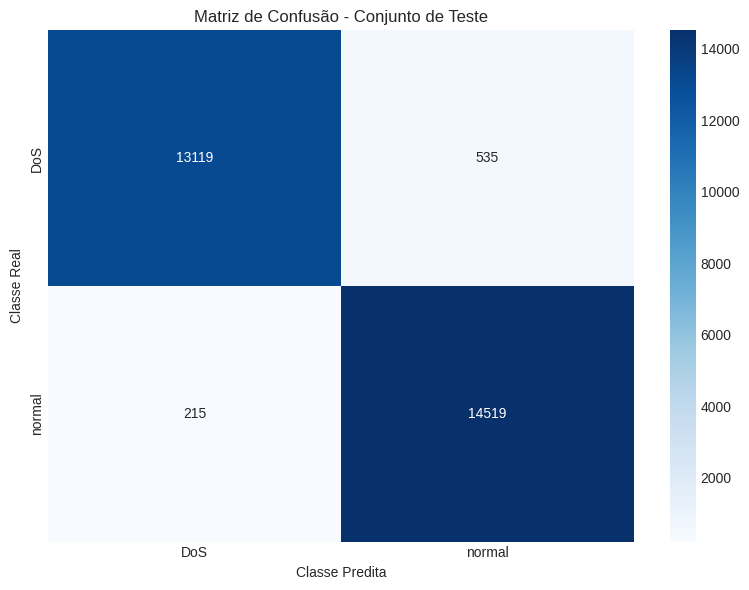


🔍 INVESTIGAÇÃO: Detalhes por Classe

Taxas de Erro por Classe:
  DoS: Erro = 3.92% (535/13654 erros)
  normal: Erro = 1.46% (215/14734 erros)

🔍 INVESTIGAÇÃO: Cross-Validation (5-fold)

Cross-Validation Scores (5-fold):
  accuracy            : 0.9739 ± 0.0010
    Fold scores: ['0.9727', '0.9731', '0.9740', '0.9743', '0.9754']
  precision_macro     : 0.9746 ± 0.0009
    Fold scores: ['0.9733', '0.9738', '0.9747', '0.9750', '0.9760']
  recall_macro        : 0.9734 ± 0.0010
    Fold scores: ['0.9722', '0.9725', '0.9734', '0.9738', '0.9749']
  f1_macro            : 0.9738 ± 0.0010
    Fold scores: ['0.9726', '0.9730', '0.9739', '0.9743', '0.9753']

🔍 INVESTIGAÇÃO: Features 'GAP' - Altamente Discriminativas?

Features de 'gap' selecionadas: []

Importância das Features Selecionadas:
               feature  importance
              mqtt.len    0.281063
        mqtt.topic_len    0.246238
          mqtt.msgtype    0.232005
             frame.len    0.089152
         frame.cap_len    0.081582


In [16]:
# ========== VERIFICAÇÃO 1: COMPARAR TREINO vs TESTE ==========
print("🔍 INVESTIGAÇÃO: Treino vs Teste")
print("=" * 60)

# Predições no TREINO
y_pred_train = rf_mrmr.predict(X_train_mrmr)
print("📊 TREINO:")
print(f"  Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"  Precision (macro): {precision_score(y_train, y_pred_train, average='macro'):.4f}")
print(f"  Recall (macro): {recall_score(y_train, y_pred_train, average='macro'):.4f}")
print(f"  F1 (macro): {f1_score(y_train, y_pred_train, average='macro'):.4f}")

print("\n📊 TESTE:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision (macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"  Recall (macro): {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"  F1 (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")

# ========== VERIFICAÇÃO 2: MATRIZ DE CONFUSÃO ==========
print("\n" + "=" * 60)
print("🔍 INVESTIGAÇÃO: Matriz de Confusão")
print("=" * 60)

cm = confusion_matrix(y_test, y_pred)
print("\nMatriz de Confusão (Teste):")
print(cm)
print("\nClasses:", le.classes_)

# Visualizar
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title('Matriz de Confusão - Conjunto de Teste')
ax.set_ylabel('Classe Real')
ax.set_xlabel('Classe Predita')
plt.tight_layout()
plt.show()

# ========== VERIFICAÇÃO 3: POR CLASSE ==========
print("\n" + "=" * 60)
print("🔍 INVESTIGAÇÃO: Detalhes por Classe")
print("=" * 60)

print("\nTaxas de Erro por Classe:")
for i, class_name in enumerate(le.classes_):
    correct = cm[i, i]
    total = cm[i].sum()
    error_rate = 1 - (correct / total)
    print(f"  {class_name}: Erro = {error_rate*100:.2f}% ({cm[i].sum() - cm[i, i]}/{cm[i].sum()} erros)")

# ========== VERIFICAÇÃO 4: CROSS-VALIDATION ==========
from sklearn.model_selection import cross_validate

print("\n" + "=" * 60)
print("🔍 INVESTIGAÇÃO: Cross-Validation (5-fold)")
print("=" * 60)

rf_cv = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
cv_results = cross_validate(rf_cv, X_train_mrmr, y_train, cv=5, 
                            scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'])

print("\nCross-Validation Scores (5-fold):")
for metric in ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']:
    scores = cv_results[f'test_{metric}']
    print(f"  {metric:20s}: {scores.mean():.4f} ± {scores.std():.4f}")
    print(f"    Fold scores: {[f'{s:.4f}' for s in scores]}")

# ========== VERIFICAÇÃO 5: FEATURES COM MAIS GAP ==========
print("\n" + "=" * 60)
print("🔍 INVESTIGAÇÃO: Features 'GAP' - Altamente Discriminativas?")
print("=" * 60)

# Features de gap aparecem nos selecionados?
gap_features = [f for f in mrmr_selected_features if 'gap' in f.lower()]
print(f"\nFeatures de 'gap' selecionadas: {gap_features}")

# Verificar importância
feature_importance_mrmr = pd.DataFrame({
    'feature': mrmr_selected_features,
    'importance': rf_mrmr.feature_importances_
}).sort_values('importance', ascending=False)

print("\nImportância das Features Selecionadas:")
print(feature_importance_mrmr.head(10).to_string(index=False))

## 5. Seleção de Features via Fisher's Score

O **Fisher's Score** mede a capacidade discriminativa de cada feature, calculando a razão entre a variância inter-classes e a variância intra-classes. Features com alto Fisher's Score são melhores para separar as classes.

$$F(f) = \frac{\sum_{c=1}^{C} n_c (\mu_c - \mu)^2}{\sum_{c=1}^{C} n_c \sigma_c^2}$$

Onde:
- $\mu_c$ = média da feature na classe $c$
- $\sigma_c$ = desvio padrão da feature na classe $c$
- $\mu$ = média global da feature
- $n_c$ = número de amostras na classe $c$


In [17]:
def fisher_score(X, y):
    """
    Calcula o Fisher's Score para cada feature.
    
    Fisher's Score = variância inter-classes / variância intra-classes
    Features com maior score são mais discriminativas.
    """
    n_samples, n_features = X.shape
    classes = np.unique(y)
    n_classes = len(classes)
    
    # Média global de cada feature
    overall_mean = X.mean(axis=0)
    
    scores = np.zeros(n_features)
    
    for i in range(n_features):
        feature_values = X.iloc[:, i].values if hasattr(X, 'iloc') else X[:, i]
        
        # Variância inter-classes 
        between_class_var = 0
        # Variância intra-classes 
        within_class_var = 0
        
        for c in classes:
            class_mask = (y == c)
            n_c = np.sum(class_mask)
            
            if n_c > 0:
                class_mean = feature_values[class_mask].mean()
                class_var = feature_values[class_mask].var()
                
                between_class_var += n_c * (class_mean - overall_mean.iloc[i]) ** 2
                within_class_var += n_c * class_var
        
        # Evitar divisão por zero
        if within_class_var > 1e-10:
            scores[i] = between_class_var / within_class_var
        else:
            scores[i] = 0
    
    return scores

# Calcular Fisher's Score
print("🔍 Calculando Fisher's Score para cada feature...")
fisher_scores = fisher_score(X, y)

# Criar DataFrame com resultados
fisher_df = pd.DataFrame({
    'feature': X.columns,
    'fisher_score': fisher_scores
}).sort_values('fisher_score', ascending=False)

# Selecionar top K features no caso 15
K_fisher = 15
fisher_selected = fisher_df.head(K_fisher)['feature'].tolist()

print(f"\n🏆 Top {K_fisher} Features por Fisher's Score:")
for i, (_, row) in enumerate(fisher_df.head(K_fisher).iterrows(), 1):
    print(f"  {i:2d}. {row['feature']}: {row['fisher_score']:.4f}")

🔍 Calculando Fisher's Score para cada feature...

🏆 Top 15 Features por Fisher's Score:
   1. mqtt.len: 2.6804
   2. mqtt.msgtype: 1.3216
   3. frame.cap_len: 0.0974
   4. frame.len: 0.0974
   5. mqtt.topic_len: 0.0116
   6. mqtt.qos: 0.0053
   7. mqtt.conack.flags.reserved: 0.0051
   8. mqtt.conack.val: 0.0046
   9. mqtt.retain: 0.0046
  10. mqtt.kalive: 0.0035
  11. mqtt.clientid_len: 0.0034
  12. mqtt.conack.flags.sp: 0.0033
  13. mqtt.conflag.cleansess: 0.0033
  14. mqtt.dupflag: 0.0022
  15. frame.time_delta: 0.0015


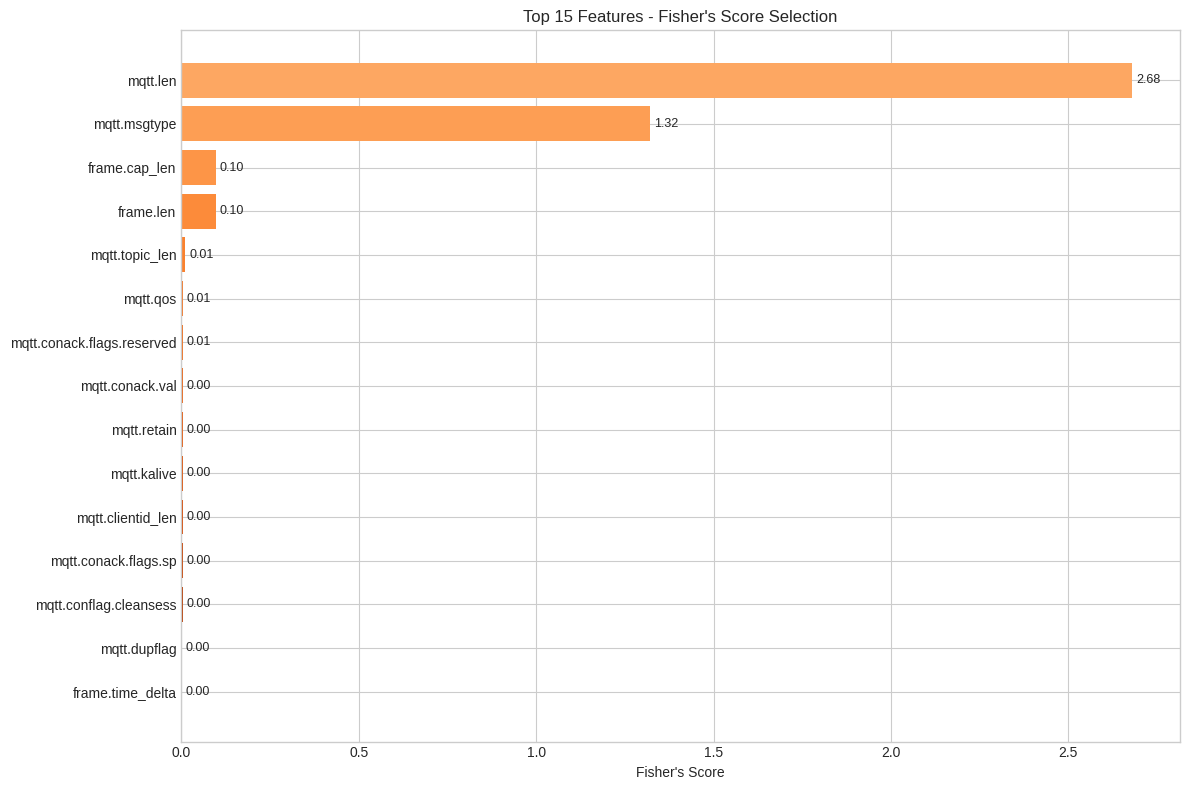

In [18]:
# Visualizar Fisher's Score
fig, ax = plt.subplots(figsize=(12, 8))

top_fisher = fisher_df.head(K_fisher)
colors = plt.cm.Oranges(np.linspace(0.4, 0.9, K_fisher))

bars = ax.barh(range(K_fisher), top_fisher['fisher_score'].values, color=colors)
ax.set_yticks(range(K_fisher))
ax.set_yticklabels(top_fisher['feature'].values)
ax.set_xlabel("Fisher's Score")
ax.set_title(f"Top {K_fisher} Features - Fisher's Score Selection", fontsize=12)
ax.invert_yaxis()

# Adicionar valores nas barras
for i, (bar, score) in enumerate(zip(bars, top_fisher['fisher_score'].values)):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{score:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Seleção de Features via Correlação de Pearson

A **Correlação de Pearson** mede a relação linear entre cada feature e o target. Features com alta correlação absoluta (|r| próximo de 1) são mais relevantes para predição.

$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

**Nota**: Usamos o valor absoluto da correlação, pois tanto correlações positivas fortes quanto negativas fortes são úteis para classificação.

In [19]:
from scipy.stats import pearsonr

def pearson_correlation_with_target(X, y):
    """
    Calcula a correlação de Pearson entre cada feature e o target.
    Retorna o valor absoluto da correlação e o p-value.
    """
    n_features = X.shape[1]
    correlations = np.zeros(n_features)
    p_values = np.zeros(n_features)
    
    for i in range(n_features):
        feature_values = X.iloc[:, i].values if hasattr(X, 'iloc') else X[:, i]
        
        # Calcular correlação de Pearson
        corr, p_val = pearsonr(feature_values, y)
        correlations[i] = corr
        p_values[i] = p_val
    
    return correlations, p_values

# Calcular correlação de Pearson
print("🔍 Calculando Correlação de Pearson entre features e target...")
pearson_corrs, pearson_pvals = pearson_correlation_with_target(X, y)

#Criar dataframe com os resultados
pearson_df = pd.DataFrame({
    'feature': X.columns,
    'pearson_corr': pearson_corrs,
    'abs_corr': np.abs(pearson_corrs),
    'p_value': pearson_pvals
}).sort_values('abs_corr', ascending=False)

#Selecionar as top K features
K_pearson = 15
pearson_selected = pearson_df.head(K_pearson)['feature'].tolist()
print(f"\n🏆 Top {K_pearson} Features por Correlação de Pearson (|r|):")
for i, (_, row) in enumerate(pearson_df.head(K_pearson).iterrows(), 1):
    sig = "***" if row['p_value'] < 0.001 else "**" if row['p_value'] < 0.01 else "*" if row['p_value'] < 0.05 else ""
    print(f"  {i:2d}. {row['feature']}: r={row['pearson_corr']:.4f} (|r|={row['abs_corr']:.4f}) {sig}")

print("\n📝 Legenda: *** p<0.001, ** p<0.01, * p<0.05")

🔍 Calculando Correlação de Pearson entre features e target...

🏆 Top 15 Features por Correlação de Pearson (|r|):
   1. mqtt.len: r=-0.8534 (|r|=0.8534) ***
   2. mqtt.msgtype: r=-0.7545 (|r|=0.7545) ***
   3. frame.cap_len: r=-0.2979 (|r|=0.2979) ***
   4. frame.len: r=-0.2979 (|r|=0.2979) ***
   5. mqtt.topic_len: r=-0.1070 (|r|=0.1070) ***
   6. mqtt.qos: r=-0.0728 (|r|=0.0728) ***
   7. mqtt.conack.flags.reserved: r=-0.0715 (|r|=0.0715) ***
   8. mqtt.conack.val: r=-0.0679 (|r|=0.0679) ***
   9. mqtt.retain: r=-0.0674 (|r|=0.0674) ***
  10. mqtt.kalive: r=-0.0591 (|r|=0.0591) ***
  11. mqtt.clientid_len: r=-0.0583 (|r|=0.0583) ***
  12. mqtt.conack.flags.sp: r=-0.0576 (|r|=0.0576) ***
  13. mqtt.conflag.cleansess: r=-0.0572 (|r|=0.0572) ***
  14. mqtt.dupflag: r=-0.0463 (|r|=0.0463) ***
  15. frame.time_delta: r=0.0382 (|r|=0.0382) ***

📝 Legenda: *** p<0.001, ** p<0.01, * p<0.05


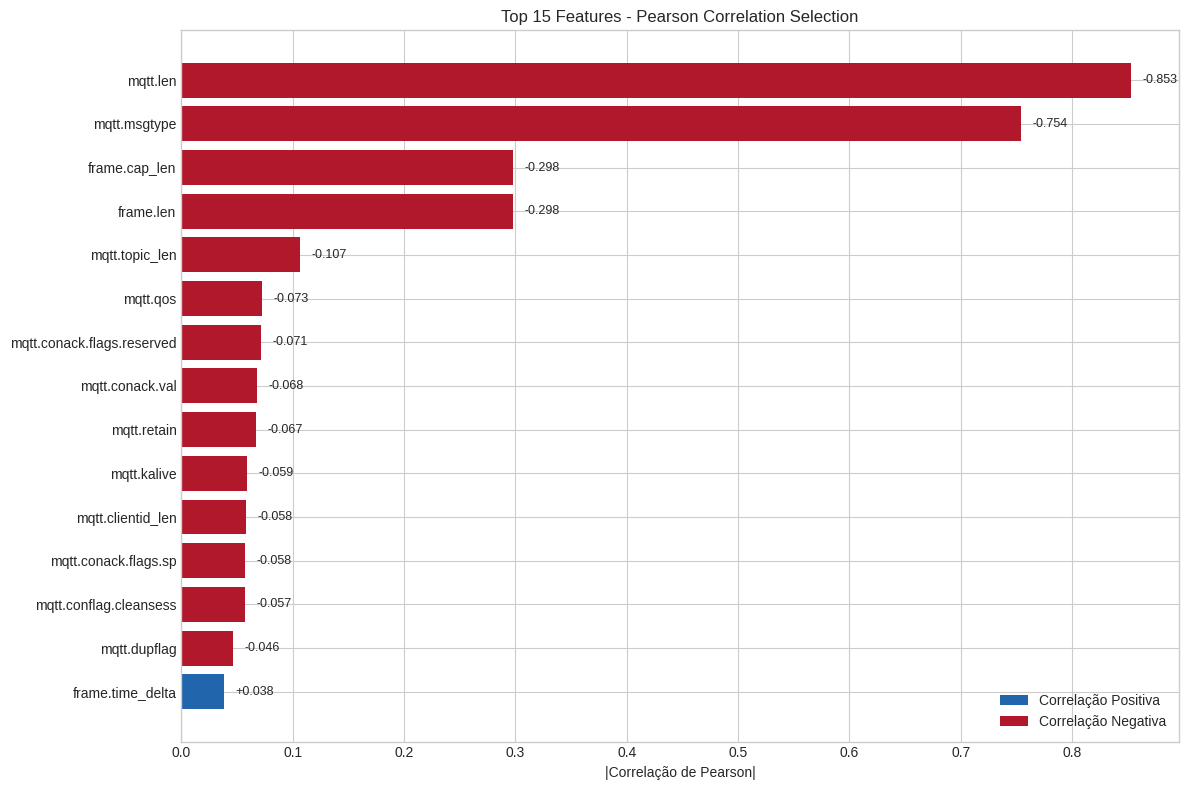

In [20]:
# Visualizar Correlação de Pearson
fig, ax = plt.subplots(figsize=(12, 8))

top_pearson = pearson_df.head(K_pearson)

# Cores baseadas no sinal da correlação (positiva=azul, negativa=vermelho)
colors = ['#2166ac' if c > 0 else '#b2182b' for c in top_pearson['pearson_corr'].values]

bars = ax.barh(range(K_pearson), top_pearson['abs_corr'].values, color=colors)
ax.set_yticks(range(K_pearson))
ax.set_yticklabels(top_pearson['feature'].values)
ax.set_xlabel('|Correlação de Pearson|')
ax.set_title(f'Top {K_pearson} Features - Pearson Correlation Selection', fontsize=12)
ax.invert_yaxis()

# Adicionar valores nas barras
for i, (bar, corr, abs_corr) in enumerate(zip(bars, top_pearson['pearson_corr'].values, top_pearson['abs_corr'].values)):
    sign = '+' if corr > 0 else '-'
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{sign}{abs_corr:.3f}', va='center', fontsize=9)

# Legenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2166ac', label='Correlação Positiva'),
                   Patch(facecolor='#b2182b', label='Correlação Negativa')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

# Comparação dos métodos até agora

In [21]:
# Comparar features selecionadas pelos métodos disponíveis
print("📊 COMPARAÇÃO DOS MÉTODOS DE SELEÇÃO DE FEATURES")
print("=" * 60)

# Criar conjuntos de features
set_mrmr = set(mrmr_selected_features) if mrmr_selected_features else set()
set_fisher = set(fisher_selected)
set_pearson = set(pearson_selected)

# Features em comum
common_all = set_mrmr & set_fisher & set_pearson
common_mrmr_fisher = set_mrmr & set_fisher
common_mrmr_pearson = set_mrmr & set_pearson
common_fisher_pearson = set_fisher & set_pearson

print(f"\n🔹 mRMR selecionou: {len(set_mrmr)} features")
print(f"🔹 Fisher's Score selecionou: {len(set_fisher)} features")
print(f"🔹 Pearson selecionou: {len(set_pearson)} features")

print(f"\n📌 Features em comum (mRMR ∩ Fisher ∩ Pearson): {len(common_all)}")
if common_all:
    for f in common_all:
        print(f"   - {f}")

print(f"\n📌 Interseções par-a-par:")
print(f"   mRMR ∩ Fisher: {len(common_mrmr_fisher)}")
print(f"   mRMR ∩ Pearson: {len(common_mrmr_pearson)}")
print(f"   Fisher ∩ Pearson: {len(common_fisher_pearson)}")

📊 COMPARAÇÃO DOS MÉTODOS DE SELEÇÃO DE FEATURES

🔹 mRMR selecionou: 15 features
🔹 Fisher's Score selecionou: 15 features
🔹 Pearson selecionou: 15 features

📌 Features em comum (mRMR ∩ Fisher ∩ Pearson): 15
   - frame.cap_len
   - mqtt.conack.val
   - mqtt.len
   - frame.len
   - frame.time_delta
   - mqtt.conack.flags.reserved
   - mqtt.kalive
   - mqtt.retain
   - mqtt.qos
   - mqtt.dupflag
   - mqtt.conflag.cleansess
   - mqtt.conack.flags.sp
   - mqtt.clientid_len
   - mqtt.topic_len
   - mqtt.msgtype

📌 Interseções par-a-par:
   mRMR ∩ Fisher: 15
   mRMR ∩ Pearson: 15
   Fisher ∩ Pearson: 15


In [22]:
# Criar tabela comparativa de rankings (incluindo ExtraTrees se disponível)
comparison_df = pd.DataFrame({
    'feature': X.columns
})

# Adicionar rankings de cada método
if mrmr_selected_features:
    mrmr_rank = {f: i+1 for i, f in enumerate(mrmr_selected_features)}
    comparison_df['mrmr_rank'] = comparison_df['feature'].map(lambda x: mrmr_rank.get(x, None))

fisher_rank = {row['feature']: i+1 for i, (_, row) in enumerate(fisher_df.iterrows())}
comparison_df['fisher_rank'] = comparison_df['feature'].map(lambda x: fisher_rank.get(x, None))

pearson_rank = {row['feature']: i+1 for i, (_, row) in enumerate(pearson_df.iterrows())}
comparison_df['pearson_rank'] = comparison_df['feature'].map(lambda x: pearson_rank.get(x, None))

# Adicionar ExtraTrees se disponível
try:
    extratree_rank = {row['feature']: i+1 for i, (_, row) in enumerate(extratree_df.iterrows())}
    comparison_df['extratree_rank'] = comparison_df['feature'].map(lambda x: extratree_rank.get(x, None))
    rank_cols = ['mrmr_rank', 'fisher_rank', 'pearson_rank', 'extratree_rank']
except:
    rank_cols = ['mrmr_rank', 'fisher_rank', 'pearson_rank']

# Filtrar apenas features que aparecem no top K de pelo menos um método
try:
    top_features = set_mrmr | set_fisher | set_pearson | set_extratree
except:
    top_features = set_mrmr | set_fisher | set_pearson
    
comparison_top = comparison_df[comparison_df['feature'].isin(top_features)].copy()

# Ordenar por média dos rankings (menor = melhor)
comparison_top['mean_rank'] = comparison_top[rank_cols].mean(axis=1, skipna=True)
comparison_top = comparison_top.sort_values('mean_rank')

print("📊 Ranking Comparativo das Features Selecionadas:")
print("=" * 80)
print(comparison_top.head(20).to_string(index=False))

📊 Ranking Comparativo das Features Selecionadas:
                   feature  mrmr_rank  fisher_rank  pearson_rank  mean_rank
                  mqtt.len        1.0            1             1   1.000000
              mqtt.msgtype        3.0            2             2   2.333333
             frame.cap_len        5.0            3             3   3.666667
                 frame.len        6.0            4             4   4.666667
            mqtt.topic_len        7.0            5             5   5.666667
                  mqtt.qos        9.0            6             6   7.000000
               mqtt.kalive        4.0           10            10   8.000000
mqtt.conack.flags.reserved       12.0            7             7   8.666667
               mqtt.retain       11.0            9             9   9.666667
           mqtt.conack.val       14.0            8             8  10.000000
              mqtt.dupflag        2.0           14            14  10.000000
         mqtt.clientid_len       10.0  

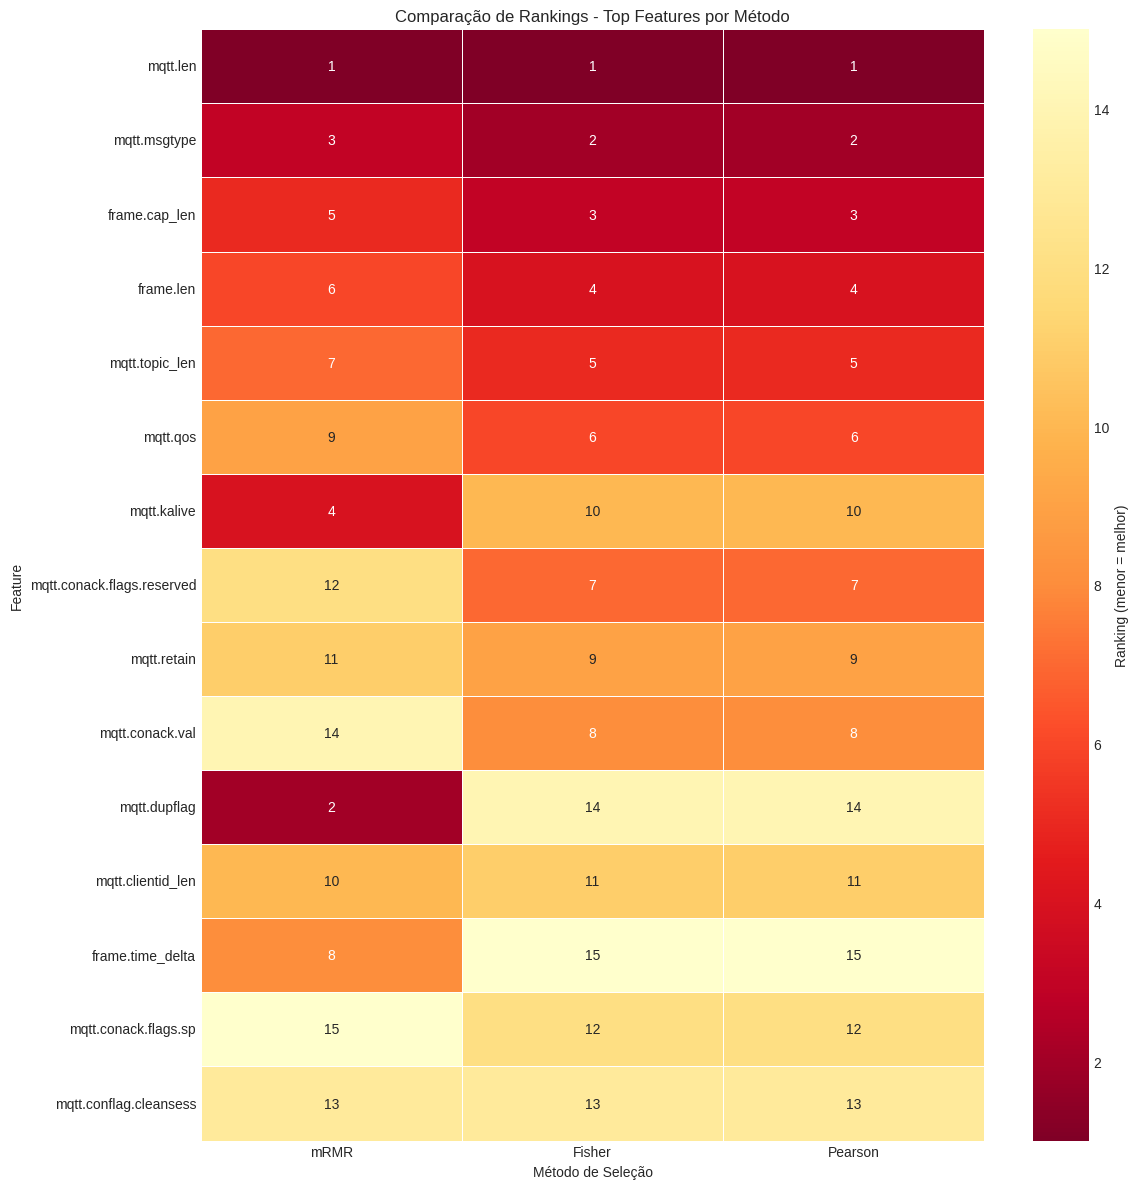

In [23]:
# Visualização: Heatmap de rankings (incluindo ExtraTrees)
fig, ax = plt.subplots(figsize=(12, 12))

# Preparar dados para heatmap
try:
    heatmap_data = comparison_top.head(20).set_index('feature')[['mrmr_rank', 'fisher_rank', 'pearson_rank', 'extratree_rank']]
    heatmap_data.columns = ['mRMR', 'Fisher', 'Pearson', 'ExtraTrees']
except:
    heatmap_data = comparison_top.head(20).set_index('feature')[['mrmr_rank', 'fisher_rank', 'pearson_rank']]
    heatmap_data.columns = ['mRMR', 'Fisher', 'Pearson']

# Substituir None por NaN para visualização
heatmap_data = heatmap_data.fillna(np.nan)

# Criar heatmap
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt='.0f',
            cmap='YlOrRd_r',
            cbar_kws={'label': 'Ranking (menor = melhor)'},
            linewidths=0.5,
            ax=ax,
            mask=heatmap_data.isna())

ax.set_title('Comparação de Rankings - Top Features por Método', fontsize=12)
ax.set_xlabel('Método de Seleção')
ax.set_ylabel('Feature')

plt.tight_layout()
plt.show()

# Seleção via low variance

In [24]:
# Para variância menor que 0.05
threshold = 0.05

selector = VarianceThreshold(threshold=threshold)
X_reduced = selector.fit_transform(X)

features_mantidas = X.columns[selector.get_support()].tolist()
features_removidas = X.columns[~selector.get_support()].tolist()

print(f"🔹 Features originais: {X.shape[1]}")
print(f"🔹 Features mantidas: {len(features_mantidas)}")
print(f"🔹 Features removidas: {len(features_removidas)}")


print(f"\n Features Mantidas:")
for i, f in enumerate(features_mantidas, 1):
    print(f"  {i:2d}. {f}")

print(f"\n❌ Features Removidas (variância < {threshold}):")
for i, f in enumerate(features_removidas, 1):
    print(f"  {i:2d}. {f}")

🔹 Features originais: 29
🔹 Features mantidas: 10
🔹 Features removidas: 19

 Features Mantidas:
   1. frame.cap_len
   2. frame.len
   3. mqtt.clientid_len
   4. mqtt.conack.val
   5. mqtt.kalive
   6. mqtt.len
   7. mqtt.msgtype
   8. mqtt.topic_len
   9. publish_gap
  10. connect_gap

❌ Features Removidas (variância < 0.05):
   1. frame.time_delta
   2. mqtt.conack.flags.reserved
   3. mqtt.conack.flags.sp
   4. mqtt.conflag.cleansess
   5. mqtt.conflag.passwd
   6. mqtt.conflag.qos
   7. mqtt.conflag.reserved
   8. mqtt.conflag.retain
   9. mqtt.conflag.uname
  10. mqtt.conflag.willflag
  11. mqtt.dupflag
  12. mqtt.passwd_len
  13. mqtt.qos
  14. mqtt.retain
  15. mqtt.sub.qos
  16. mqtt.suback.qos
  17. mqtt.username_len
  18. mqtt.willmsg_len
  19. mqtt.willtopic_len


# Seleção via ExtraTrees 

In [25]:
extra_tree = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs =-1)
extra_tree.fit(X,y)

importances = extra_tree.feature_importances_

extratree_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances

}).sort_values('importance', ascending=False)

K_tree = 15
extratree_selected = extratree_df.head(K_tree)['feature'].tolist()

print(f"\n Top {K_tree} Features por ExtraTreesClassifier:")
for i, (_, row) in enumerate(extratree_df.head(K_tree).iterrows(), 1):
    print(f"  {i:2d}. {row['feature']}: {row['importance']:.4f}")


 Top 15 Features por ExtraTreesClassifier:
   1. mqtt.len: 0.4054
   2. mqtt.msgtype: 0.2032
   3. mqtt.topic_len: 0.1012
   4. frame.cap_len: 0.0955
   5. frame.len: 0.0885
   6. frame.time_delta: 0.0643
   7. publish_gap: 0.0315
   8. mqtt.kalive: 0.0021
   9. mqtt.clientid_len: 0.0017
  10. mqtt.conflag.cleansess: 0.0016
  11. mqtt.qos: 0.0013
  12. mqtt.conack.flags.reserved: 0.0012
  13. mqtt.retain: 0.0009
  14. mqtt.conack.val: 0.0009
  15. mqtt.conack.flags.sp: 0.0003


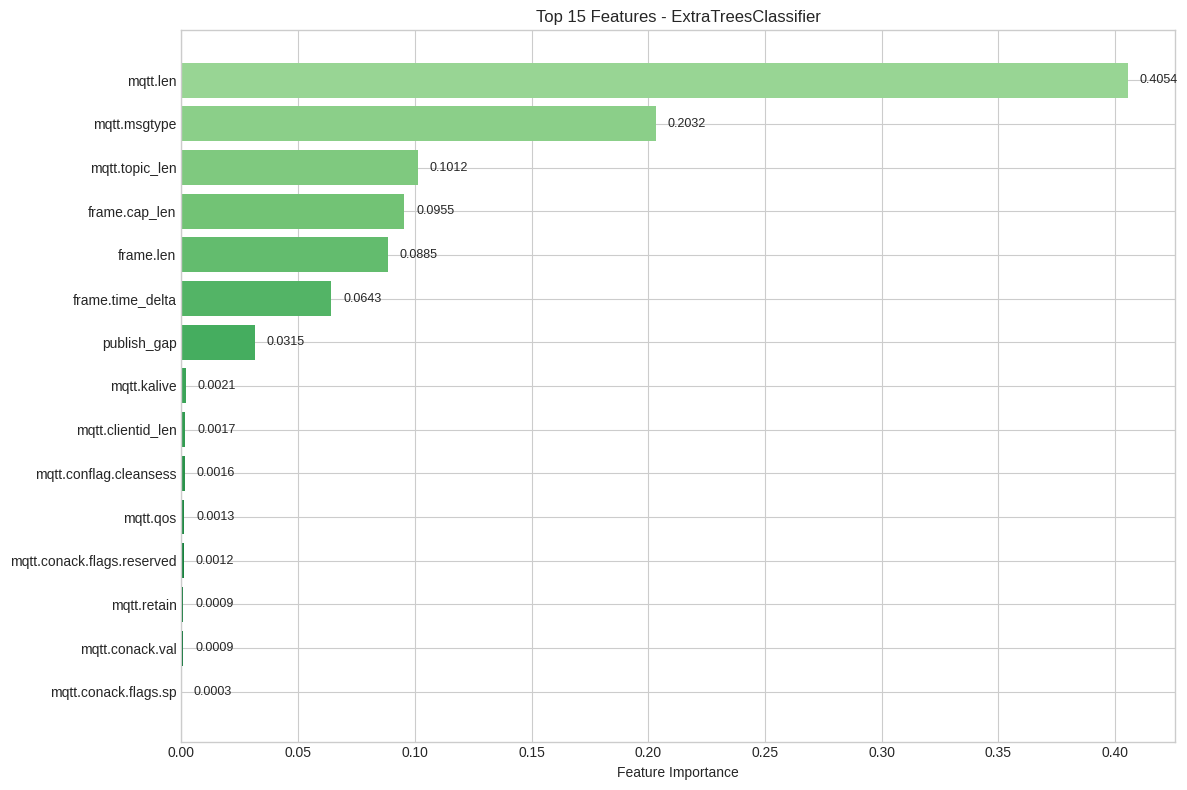


📊 Soma das importâncias (Top 15): 0.9995 (99.9%)


In [26]:
# Visualizar Feature Importance do ExtraTreesClassifier
fig, ax = plt.subplots(figsize=(12, 8))

top_tree = extratree_df.head(K_tree)
colors = plt.cm.Greens(np.linspace(0.4, 0.9, K_tree))

bars = ax.barh(range(K_tree), top_tree['importance'].values, color=colors)
ax.set_yticks(range(K_tree))
ax.set_yticklabels(top_tree['feature'].values)
ax.set_xlabel('Feature Importance')
ax.set_title(f'Top {K_tree} Features - ExtraTreesClassifier', fontsize=12)
ax.invert_yaxis()

# Adicionar valores nas barras
for bar, imp in zip(bars, top_tree['importance'].values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{imp:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Mostrar soma das importâncias do top K
total_importance = top_tree['importance'].sum()
print(f"\n📊 Soma das importâncias (Top {K_tree}): {total_importance:.4f} ({total_importance*100:.1f}%)")

# Comparação do Extra Trees com os outros


In [27]:
# Comparar ExtraTrees com outros métodos
print("📊 COMPARAÇÃO: ExtraTrees vs Outros Métodos")
print("=" * 60)

set_extratree = set(extratree_selected)

# Features em comum com outros métodos
common_tree_mrmr = set_extratree & set_mrmr if mrmr_selected_features else set()
common_tree_fisher = set_extratree & set_fisher
common_tree_pearson = set_extratree & set_pearson
common_all_4 = set_extratree & set_mrmr & set_fisher & set_pearson if mrmr_selected_features else set()

print(f"\n🌳 ExtraTrees selecionou: {len(set_extratree)} features")
print(f"\n📌 Features em comum:")
print(f"   ExtraTrees ∩ mRMR: {len(common_tree_mrmr)}")
print(f"   ExtraTrees ∩ Fisher: {len(common_tree_fisher)}")
print(f"   ExtraTrees ∩ Pearson: {len(common_tree_pearson)}")
print(f"   Todos os 4 métodos: {len(common_all_4)}")

if common_all_4:
    print(f"\n✅ Features selecionadas por TODOS os métodos:")
    for f in common_all_4:
        print(f"   - {f}")

📊 COMPARAÇÃO: ExtraTrees vs Outros Métodos

🌳 ExtraTrees selecionou: 15 features

📌 Features em comum:
   ExtraTrees ∩ mRMR: 14
   ExtraTrees ∩ Fisher: 14
   ExtraTrees ∩ Pearson: 14
   Todos os 4 métodos: 14

✅ Features selecionadas por TODOS os métodos:
   - mqtt.conack.val
   - frame.cap_len
   - frame.len
   - frame.time_delta
   - mqtt.conack.flags.reserved
   - mqtt.kalive
   - mqtt.retain
   - mqtt.qos
   - mqtt.conflag.cleansess
   - mqtt.conack.flags.sp
   - mqtt.len
   - mqtt.clientid_len
   - mqtt.topic_len
   - mqtt.msgtype


In [28]:
# Validar ExtraTrees: treinar modelo apenas com features selecionadas
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Modelo com features do ExtraTrees
X_train_tree = X_train[extratree_selected]
X_test_tree = X_test[extratree_selected]

print(f"📊 Treinando modelo com {len(extratree_selected)} features ExtraTrees...")
rf_tree = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_tree.fit(X_train_tree, y_train)
acc_tree = accuracy_score(y_test, rf_tree.predict(X_test_tree))

print(f"\n{'='*50}")
print(f"📈 VALIDAÇÃO - ExtraTrees Feature Selection")
print(f"{'='*50}")
print(f"🔹 Features ExtraTrees ({len(extratree_selected)}): Acurácia = {acc_tree:.4f}")
print(f"{'='*50}")

📊 Treinando modelo com 15 features ExtraTrees...

📈 VALIDAÇÃO - ExtraTrees Feature Selection
🔹 Features ExtraTrees (15): Acurácia = 0.9737


# Seleção via LinearSVC


In [29]:
#Normalizar dados 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Treinando LinearSVC para importancia de features")

svc = LinearSVC(C=0.1, penalty='l1', dual=False, max_iter=5000, random_state=42)
svc.fit(X_scaled, y)

#Obter coeficientes 
if len(svc.coef_.shape) > 1:
    #Multiclasse: media dos coeficientes absolutos
    coef_importance = np.mean(np.abs(svc.coef_), axis=0)
else :
    coef_importance = np.abs(svc.coef_[0])

# Montar o data frame com os resultados
svc_df = pd.DataFrame({
    'feature' : X.columns,
    'importance': coef_importance
}).sort_values('importance', ascending=False)

#Selecionar top K features
K_svc = 15

print(f"\n Top {K_svc} Features selecionadas  por LinearSVC:")
for i, (_, row) in enumerate(svc_df.head(K_svc).iterrows(), 1):
    print(f"  {i:2d}. {row['feature']}: {row['importance']:.4f}")

Treinando LinearSVC para importancia de features

 Top 15 Features selecionadas  por LinearSVC:
   1. mqtt.len: 1.6259
   2. frame.len: 0.7242
   3. mqtt.topic_len: 0.2519
   4. mqtt.kalive: 0.1448
   5. mqtt.msgtype: 0.0741
   6. mqtt.conflag.cleansess: 0.0626
   7. mqtt.conack.flags.reserved: 0.0498
   8. frame.cap_len: 0.0478
   9. frame.time_delta: 0.0469
  10. mqtt.clientid_len: 0.0313
  11. mqtt.qos: 0.0282
  12. connect_gap: 0.0117
  13. publish_gap: 0.0012
  14. mqtt.conflag.uname: 0.0000
  15. mqtt.conflag.retain: 0.0000



#### Para C = 0.1

Treinando LinearSVC para importancia de features
iteracoes: 5000

 Top 15 Features selecionadas  por LinearSVC:
iteracoes: 50000
   1. publish_gap: 10.1183
   2. mqtt.len: 6.6288
   3. mqtt.retain: 2.6279
   4. frame.len: 0.8684
   5. mqtt.clientid_len: 0.1915
   6. mqtt.kalive: 0.1819
   7. mqtt.conflag.cleansess: 0.1126
   8. frame.time_delta: 0.0829
   9. frame.cap_len: 0.0812
  10. mqtt.qos: 0.0531
  11. mqtt.msgtype: 0.0292
  12. connect_gap: 0.0179
  13. mqtt.conack.flags.reserved: 0.0106
  14. mqtt.conflag.uname: 0.0000
  15. mqtt.conflag.retain: 0.0000


Treinando LinearSVC para importancia de features

 Top 15 Features selecionadas  por LinearSVC:
   1. publish_gap: 10.1183
   2. mqtt.len: 6.6288
   3. mqtt.retain: 2.6279
   4. frame.len: 0.8684
   5. mqtt.clientid_len: 0.1915
   6. mqtt.kalive: 0.1819
   7. mqtt.conflag.cleansess: 0.1126
   8. frame.time_delta: 0.0829
   9. frame.cap_len: 0.0812
  10. mqtt.qos: 0.0531
  11. mqtt.msgtype: 0.0292
  12. connect_gap: 0.0179
  13. mqtt.conack.flags.reserved: 0.0106
  14. mqtt.conflag.uname: 0.0000
  15. mqtt.conflag.retain: 0.0000


#### Para c = 0.01

Treinando LinearSVC para importancia de features
 ITERACOES = 50000
 Top 15 Features selecionadas  por LinearSVC:
   1. publish_gap: 7.8773
   2. mqtt.len: 4.4757
   3. mqtt.retain: 1.2058
   4. mqtt.conack.flags.reserved: 0.9581
   5. frame.len: 0.5415
   6. frame.cap_len: 0.1385
   7. mqtt.conflag.cleansess: 0.0971
   8. frame.time_delta: 0.0680
   9. mqtt.msgtype: 0.0388
  10. mqtt.topic_len: 0.0275
  11. connect_gap: 0.0148
  12. mqtt.clientid_len: 0.0000
  13. mqtt.conack.flags.sp: 0.0000
  14. mqtt.conflag.uname: 0.0000
  15. mqtt.conflag.retain: 0.0000


Treinando LinearSVC para importancia de features
  iTERACOERS: 5000
 Top 15 Features selecionadas  por LinearSVC:
   1. publish_gap: 7.8773
   2. mqtt.len: 4.4757
   3. mqtt.retain: 1.2058
   4. mqtt.conack.flags.reserved: 0.9581
   5. frame.len: 0.5415
   6. frame.cap_len: 0.1385
   7. mqtt.conflag.cleansess: 0.0971
   8. frame.time_delta: 0.0680
   9. mqtt.msgtype: 0.0388
  10. mqtt.topic_len: 0.0275
  11. connect_gap: 0.0148
  12. mqtt.clientid_len: 0.0000
  13. mqtt.conack.flags.sp: 0.0000
  14. mqtt.conflag.uname: 0.0000
  15. mqtt.conflag.retain: 0.0000

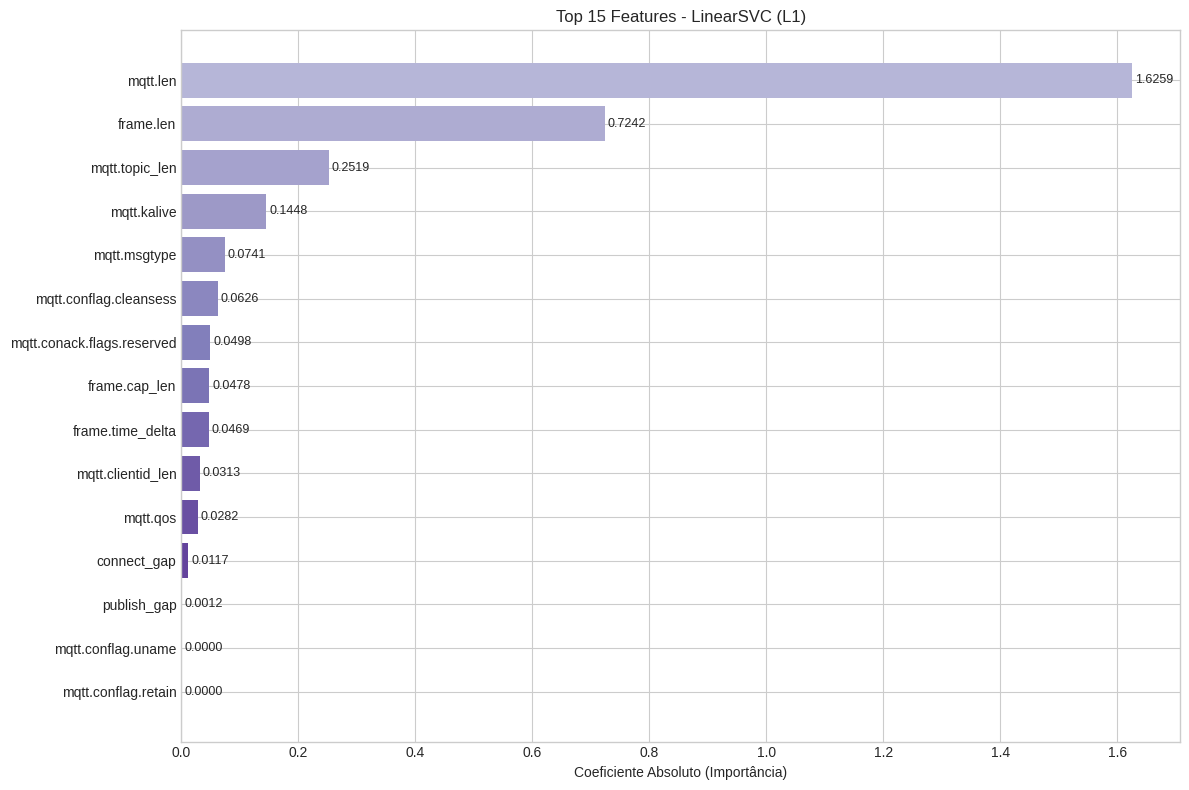


📊 Features com coeficiente não-zero: 13/29


In [30]:
# Visualizar Feature Importance do LinearSVC
fig, ax = plt.subplots(figsize=(12, 8))

top_svc = svc_df.head(K_svc)
colors = plt.cm.Purples(np.linspace(0.4, 0.9, K_svc))

bars = ax.barh(range(K_svc), top_svc['importance'].values, color=colors)
ax.set_yticks(range(K_svc))
ax.set_yticklabels(top_svc['feature'].values)
ax.set_xlabel('Coeficiente Absoluto (Importância)')
ax.set_title(f'Top {K_svc} Features - LinearSVC (L1)', fontsize=12)
ax.invert_yaxis()

# Adicionar valores nas barras
for bar, imp in zip(bars, top_svc['importance'].values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{imp:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Contar features com coeficiente não-zero
non_zero = (svc_df['importance'] > 0).sum()
print(f"\n📊 Features com coeficiente não-zero: {non_zero}/{len(svc_df)}")

In [31]:
# Validar LinearSVC: treinar modelo apenas com features selecionadas
svc_selected = svc_df.head(K_svc)['feature'].tolist()
X_train_svc = X_train[svc_selected]
X_test_svc = X_test[svc_selected]

print(f"📊 Treinando modelo com {len(svc_selected)} features LinearSVC...")
rf_svc = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_svc.fit(X_train_svc, y_train)
acc_svc = accuracy_score(y_test, rf_svc.predict(X_test_svc))

print(f"\n{'='*50}")
print(f"📈 VALIDAÇÃO - LinearSVC Feature Selection")
print(f"{'='*50}")
print(f"🔹 Features LinearSVC ({len(svc_selected)}): Acurácia = {acc_svc:.4f}")
print(f"{'='*50}")

📊 Treinando modelo com 15 features LinearSVC...

📈 VALIDAÇÃO - LinearSVC Feature Selection
🔹 Features LinearSVC (15): Acurácia = 0.9737


## Seleção de Features via Lasso (L1 Regularization)

O **Lasso** (Least Absolute Shrinkage and Selection Operator) usa regularização L1 para forçar alguns coeficientes a zero, realizando seleção de features automaticamente.

$$\min_{\beta} \frac{1}{2n} ||y - X\beta||_2^2 + \alpha ||\beta||_1$$

Características:
- Produz modelos esparsos (muitos coeficientes = 0)
- O parâmetro $\alpha$ controla a intensidade da regularização

In [32]:
# Usar LassoCV para encontrar o melhor alpha automaticamente
# Como Lasso é para regressão, usamos y numérico (classes codificadas)

lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000, n_jobs=-1)
lasso_cv.fit(X_scaled, y)

print(f" Alpha otimo encontrado: {lasso_cv.alpha_:.6f}")

#Obter os coeficientes
lasso_coef = np.abs(lasso_cv.coef_)

#Criar o dataframe 
lasso_df = pd.DataFrame({
    'feature': X.columns,
    'importance': lasso_coef
}).sort_values('importance', ascending=False)

#Selecionar top K features
K_lasso = 15
lasso_selected = lasso_df.head(K_lasso)['feature'].tolist()


print(f"\n Top {K_lasso} Features por Lasso:")
for i, (_, row) in enumerate(lasso_df.head(K_lasso).iterrows(), 1):
    print(f"  {i:2d}. {row['feature']}: {row['importance']:.4f}")

# Contar features com coeficiente não-zero
non_zero_lasso = (lasso_df['importance'] > 0).sum()
print(f"\n📊 Features com coeficiente não-zero: {non_zero_lasso}/{len(lasso_df)}")

 Alpha otimo encontrado: 0.000426

 Top 15 Features por Lasso:
   1. mqtt.len: 0.4360
   2. frame.cap_len: 0.0910
   3. mqtt.msgtype: 0.0425
   4. mqtt.kalive: 0.0281
   5. mqtt.topic_len: 0.0217
   6. mqtt.conack.flags.reserved: 0.0085
   7. mqtt.qos: 0.0082
   8. frame.time_delta: 0.0075
   9. mqtt.dupflag: 0.0071
  10. mqtt.conack.flags.sp: 0.0043
  11. mqtt.retain: 0.0026
  12. mqtt.clientid_len: 0.0000
  13. frame.len: 0.0000
  14. mqtt.conflag.uname: 0.0000
  15. mqtt.conflag.retain: 0.0000

📊 Features com coeficiente não-zero: 11/29


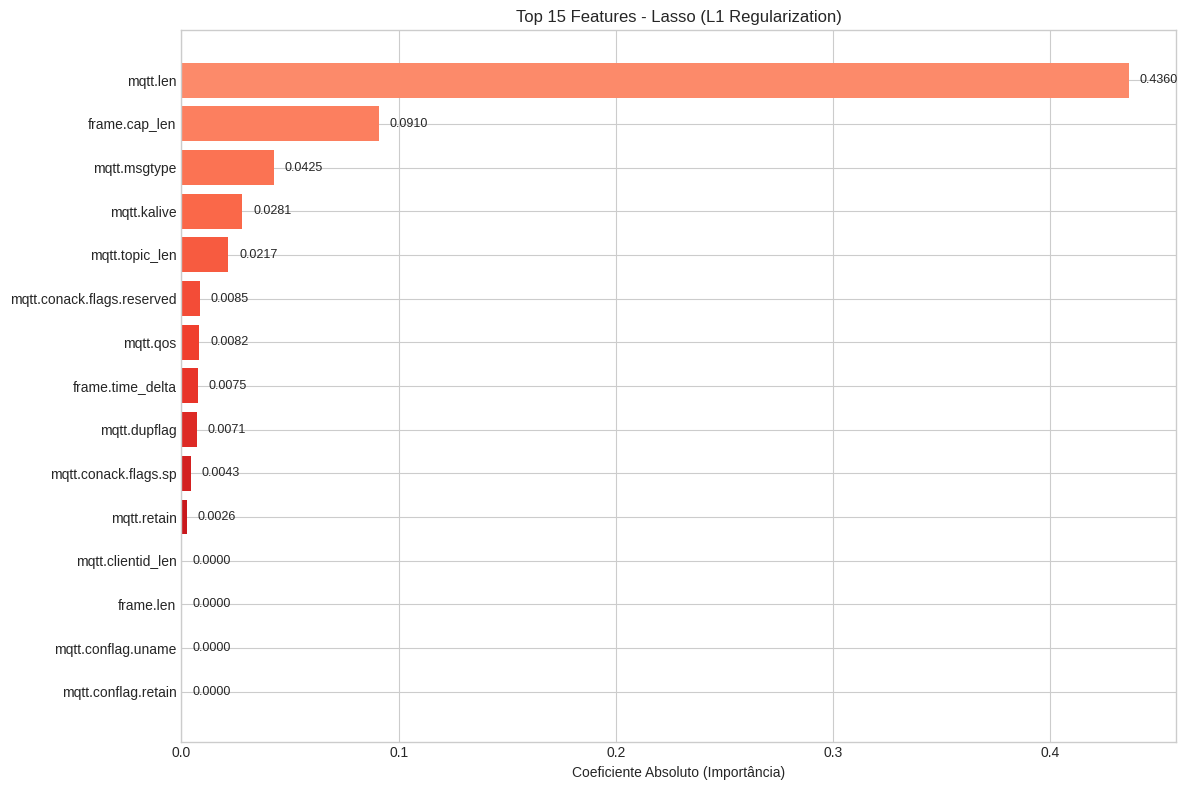

In [33]:
# Visualizar Feature Importance do Lasso
fig, ax = plt.subplots(figsize=(12, 8))

top_lasso = lasso_df.head(K_lasso)
colors = plt.cm.Reds(np.linspace(0.4, 0.9, K_lasso))

bars = ax.barh(range(K_lasso), top_lasso['importance'].values, color=colors)
ax.set_yticks(range(K_lasso))
ax.set_yticklabels(top_lasso['feature'].values)
ax.set_xlabel('Coeficiente Absoluto (Importância)')
ax.set_title(f'Top {K_lasso} Features - Lasso (L1 Regularization)', fontsize=12)
ax.invert_yaxis()

# Adicionar valores nas barras
for bar, imp in zip(bars, top_lasso['importance'].values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{imp:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Validando as caracteristicas selecionadas

In [34]:
X_train_lasso = X_train[lasso_selected]
X_test_lasso = X_test[lasso_selected]

print(f" Treinando o modelo com {len(lasso_selected)} features selecionadas por Lasso")
rf_lasso = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_lasso.fit(X_train_lasso, y_train)
acc_lasso = accuracy_score(y_test, rf_lasso.predict(X_test_lasso))

print(f"\n{'='*50}")
print(f"VALIDAÇÃO - Lasso Feature Selection")
print(f"{'='*50}")
print(f"🔹 Features Lasso ({len(lasso_selected)}): Acurácia = {acc_lasso:.4f}")
print(f"{'='*50}")

 Treinando o modelo com 15 features selecionadas por Lasso

VALIDAÇÃO - Lasso Feature Selection
🔹 Features Lasso (15): Acurácia = 0.9736


In [35]:
# Comparar SVC e Lasso com outros métodos
print(" COMPARAÇÃO: SVC e Lasso vs Outros Métodos")
print("=" * 70)

set_svc = set(svc_selected)
set_lasso = set(lasso_selected)

all_methods = [set_mrmr, set_fisher, set_pearson, set_extratree, set_svc, set_lasso]
common_all_6 = set_mrmr & set_fisher & set_pearson & set_extratree & set_svc & set_lasso


print(f"\n🔹 LinearSVC selecionou: {len(set_svc)} features")
print(f"🔹 Lasso selecionou: {len(set_lasso)} features")

print(f"\n📌 Features em comum (todos os 6 métodos): {len(common_all_6)}")
if common_all_6:
    for f in common_all_6:
        print(f"   - {f}")

# Interseções par-a-par com SVC e Lasso
print(f"\n📌 Interseções com LinearSVC:")
print(f"   SVC ∩ mRMR: {len(set_svc & set_mrmr)}")
print(f"   SVC ∩ Fisher: {len(set_svc & set_fisher)}")
print(f"   SVC ∩ Pearson: {len(set_svc & set_pearson)}")
print(f"   SVC ∩ ExtraTrees: {len(set_svc & set_extratree)}")
print(f"   SVC ∩ Lasso: {len(set_svc & set_lasso)}")

print(f"\n📌 Interseções com Lasso:")
print(f"   Lasso ∩ mRMR: {len(set_lasso & set_mrmr)}")
print(f"   Lasso ∩ Fisher: {len(set_lasso & set_fisher)}")
print(f"   Lasso ∩ Pearson: {len(set_lasso & set_pearson)}")
print(f"   Lasso ∩ ExtraTrees: {len(set_lasso & set_extratree)}")


 COMPARAÇÃO: SVC e Lasso vs Outros Métodos

🔹 LinearSVC selecionou: 15 features
🔹 Lasso selecionou: 15 features

📌 Features em comum (todos os 6 métodos): 10
   - frame.cap_len
   - frame.len
   - frame.time_delta
   - mqtt.conack.flags.reserved
   - mqtt.kalive
   - mqtt.qos
   - mqtt.topic_len
   - mqtt.len
   - mqtt.clientid_len
   - mqtt.msgtype

📌 Interseções com LinearSVC:
   SVC ∩ mRMR: 11
   SVC ∩ Fisher: 11
   SVC ∩ Pearson: 11
   SVC ∩ ExtraTrees: 12
   SVC ∩ Lasso: 12

📌 Interseções com Lasso:
   Lasso ∩ mRMR: 13
   Lasso ∩ Fisher: 13
   Lasso ∩ Pearson: 13
   Lasso ∩ ExtraTrees: 12


In [36]:
# Validar: Comparar modelo com todas features vs features mRMR
if mrmr_selected_features:
    # Dividir dados
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # Modelo 1: Todas as features
    print("📊 Treinando modelo com TODAS as features...")
    rf_all = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf_all.fit(X_train, y_train)
    acc_all = accuracy_score(y_test, rf_all.predict(X_test))
    
    # Modelo 2: Features selecionadas pelo mRMR
    X_train_mrmr = X_train[mrmr_selected_features]
    X_test_mrmr = X_test[mrmr_selected_features]
    
    print(f"📊 Treinando modelo com {len(mrmr_selected_features)} features mRMR...")
    rf_mrmr = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf_mrmr.fit(X_train_mrmr, y_train)
    acc_mrmr = accuracy_score(y_test, rf_mrmr.predict(X_test_mrmr))
    
    # Resultado
    print(f"\n{'='*50}")
    print(f"📈 RESULTADOS DA VALIDAÇÃO")
    print(f"{'='*50}")
    print(f"🔹 Todas as Features ({X.shape[1]}): Acurácia = {acc_all:.4f}")
    print(f"🔹 Features mRMR ({len(mrmr_selected_features)}): Acurácia = {acc_mrmr:.4f}")
    print(f"{'='*50}")
    print(f"📉 Diferença: {(acc_all - acc_mrmr)*100:.2f}%")
    print(f"📉 Redução de features: {X.shape[1]} → {len(mrmr_selected_features)} ({(1-len(mrmr_selected_features)/X.shape[1])*100:.1f}% menos)")

📊 Treinando modelo com TODAS as features...
📊 Treinando modelo com 15 features mRMR...

📈 RESULTADOS DA VALIDAÇÃO
🔹 Todas as Features (29): Acurácia = 0.9737
🔹 Features mRMR (15): Acurácia = 0.9736
📉 Diferença: 0.01%
📉 Redução de features: 29 → 15 (48.3% menos)


In [37]:
# Resumo final: Comparação de Acurácias de todos os métodos
print("📊 RESUMO FINAL - COMPARAÇÃO DE ACURÁCIAS")
print("=" * 60)

# Criar tabela de resultados
results = {
    'Método': ['Todas Features', 'mRMR', 'Fisher', 'Pearson', 'ExtraTrees', 'LinearSVC', 'Lasso'],
    'Num Features': [X.shape[1], len(mrmr_selected_features), K_fisher, K_pearson, K_tree, K_svc, K_lasso],
    'Acurácia': [acc_all, acc_mrmr, None, None, acc_tree, acc_svc, acc_lasso]
}

# Calcular acurácias para Fisher e Pearson se ainda não foram calculadas
X_train_fisher = X_train[fisher_selected]
X_test_fisher = X_test[fisher_selected]
rf_fisher = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_fisher.fit(X_train_fisher, y_train)
acc_fisher = accuracy_score(y_test, rf_fisher.predict(X_test_fisher))

X_train_pearson = X_train[pearson_selected]
X_test_pearson = X_test[pearson_selected]
rf_pearson = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_pearson.fit(X_train_pearson, y_train)
acc_pearson = accuracy_score(y_test, rf_pearson.predict(X_test_pearson))

results['Acurácia'] = [acc_all, acc_mrmr, acc_fisher, acc_pearson, acc_tree, acc_svc, acc_lasso]

results_df = pd.DataFrame(results)
results_df['Redução (%)'] = ((X.shape[1] - results_df['Num Features']) / X.shape[1] * 100).round(1)
results_df['Acurácia'] = results_df['Acurácia'].round(4)
results_df = results_df.sort_values('Acurácia', ascending=False)

print(results_df.to_string(index=False))

print(f"\n🏆 Melhor método: {results_df.iloc[0]['Método']} com acurácia {results_df.iloc[0]['Acurácia']:.4f}")

📊 RESUMO FINAL - COMPARAÇÃO DE ACURÁCIAS
        Método  Num Features  Acurácia  Redução (%)
Todas Features            29    0.9737          0.0
     LinearSVC            15    0.9737         48.3
    ExtraTrees            15    0.9737         48.3
        Fisher            15    0.9736         48.3
          mRMR            15    0.9736         48.3
       Pearson            15    0.9736         48.3
         Lasso            15    0.9736         48.3

🏆 Melhor método: Todas Features com acurácia 0.9737


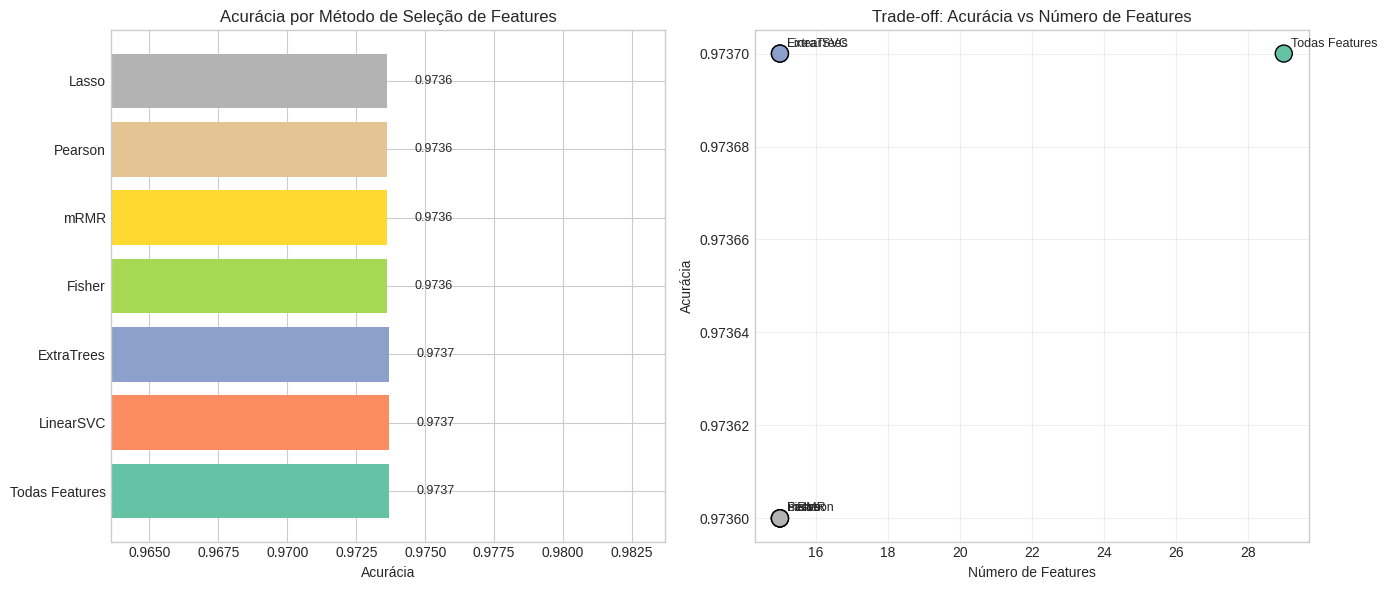

In [38]:
# Visualização: Comparação de Acurácias
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Acurácia por método
ax1 = axes[0]
methods = results_df['Método'].values
accuracies = results_df['Acurácia'].values
colors = plt.cm.Set2(np.linspace(0, 1, len(methods)))

bars = ax1.barh(range(len(methods)), accuracies, color=colors)
ax1.set_yticks(range(len(methods)))
ax1.set_yticklabels(methods)
ax1.set_xlabel('Acurácia')
ax1.set_title('Acurácia por Método de Seleção de Features', fontsize=12)
ax1.set_xlim(min(accuracies) - 0.01, max(accuracies) + 0.01)

for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{acc:.4f}', va='center', fontsize=9)

# Gráfico 2: Trade-off Acurácia vs Número de Features
ax2 = axes[1]
num_features = results_df['Num Features'].values

scatter = ax2.scatter(num_features, accuracies, c=colors, s=150, edgecolors='black', linewidths=1)
for i, method in enumerate(methods):
    ax2.annotate(method, (num_features[i], accuracies[i]), 
                 textcoords="offset points", xytext=(5, 5), fontsize=9)

ax2.set_xlabel('Número de Features')
ax2.set_ylabel('Acurácia')
ax2.set_title('Trade-off: Acurácia vs Número de Features', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [44]:
def plot_correlation_matrix(X, features, title, ax, cmap='coolwarm'):
    """Plota matriz de correlação para um subconjunto de features."""
    X_subset = X[features]
    corr = X_subset.corr()
    
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, cmap=cmap, center=0, 
                annot=True, fmt='.2f', square=True,
                linewidths=0.5, ax=ax,
                cbar_kws={"shrink": 0.8},
                annot_kws={"size": 7})
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)
    
    # Calcular média da correlação absoluta (excluindo diagonal)
    corr_values = corr.values
    n = len(corr)
    upper_triangle = corr_values[np.triu_indices(n, k=1)]
    mean_corr = np.mean(np.abs(upper_triangle))
    
    return mean_corr

### Matriz de correlação - MRMR

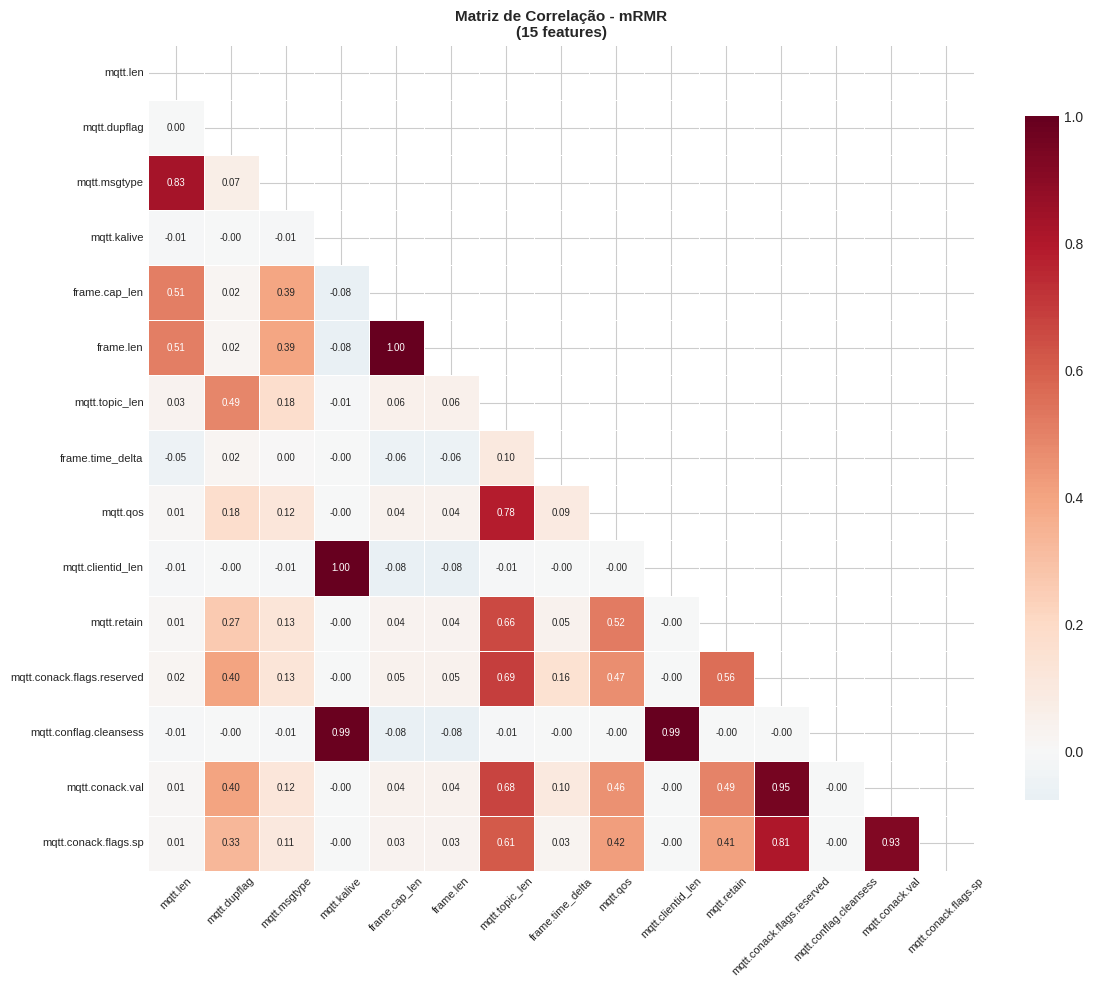

📊 Média da correlação absoluta (mRMR): 0.1998


In [45]:
# Matriz de Correlação - mRMR
mrmr_selected = globals().get("mrmr_selected_features", [])

if mrmr_selected:
    fig, ax = plt.subplots(figsize=(12, 10))
    mean_corr_mrmr = plot_correlation_matrix(
        X, 
        mrmr_selected,
        f"Matriz de Correlação - mRMR\n({len(mrmr_selected)} features)",
        ax,
        cmap="RdBu_r"
    )
    plt.tight_layout()
    plt.show()
    print(f"📊 Média da correlação absoluta (mRMR): {mean_corr_mrmr:.4f}")
else:
    print("⚠️ mrmr_selected_features não está disponível. Execute a célula de seleção mRMR primeiro.")

### Matriz de Correlação - Fisher's Score


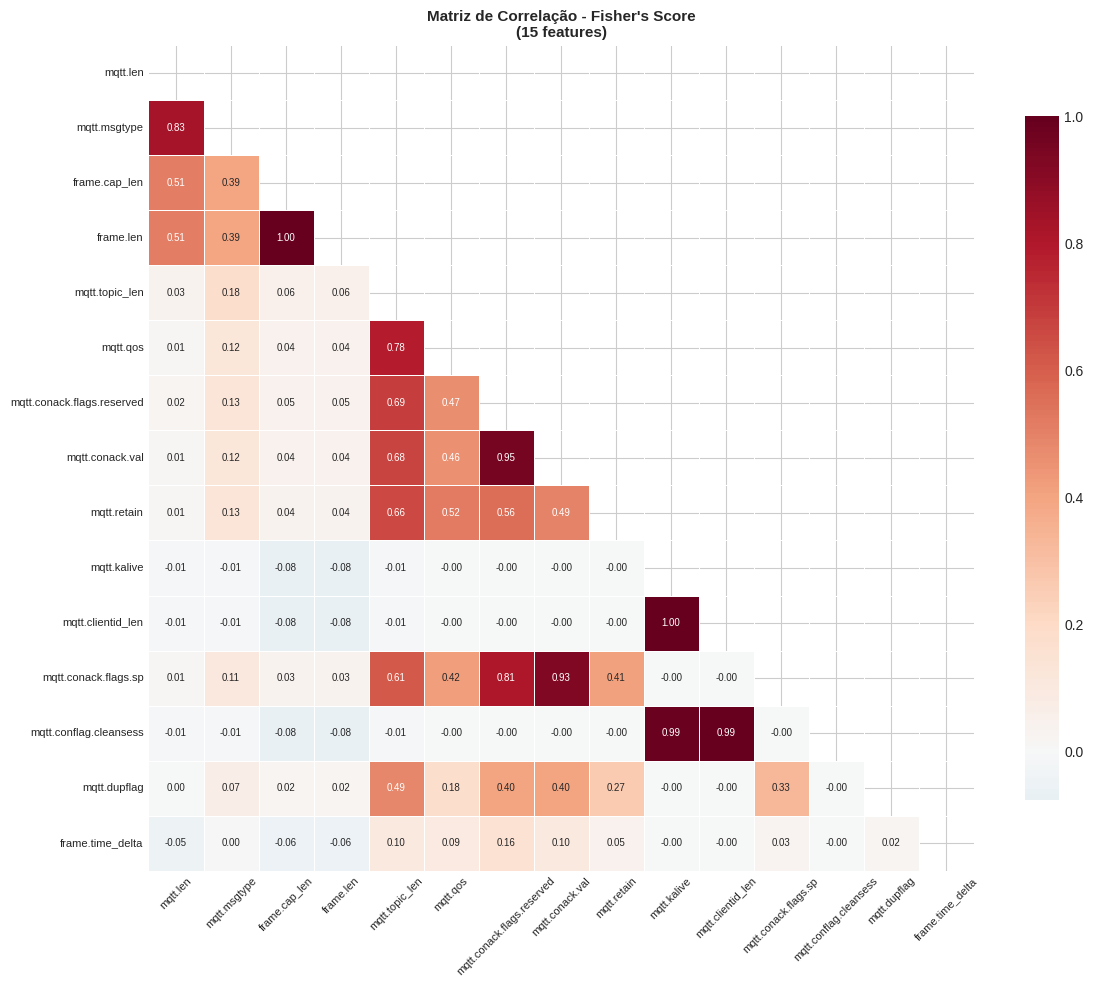

📊 Média da correlação absoluta (Fisher): 0.1998


In [46]:
fig, ax = plt.subplots(figsize=(12, 10))
mean_corr_fisher = plot_correlation_matrix(X, fisher_selected, 
                                            f"Matriz de Correlação - Fisher's Score\n({len(fisher_selected)} features)", 
                                            ax, cmap='RdBu_r')
plt.tight_layout()
plt.show()
print(f"📊 Média da correlação absoluta (Fisher): {mean_corr_fisher:.4f}")

### Matriz de correlação = Pearson

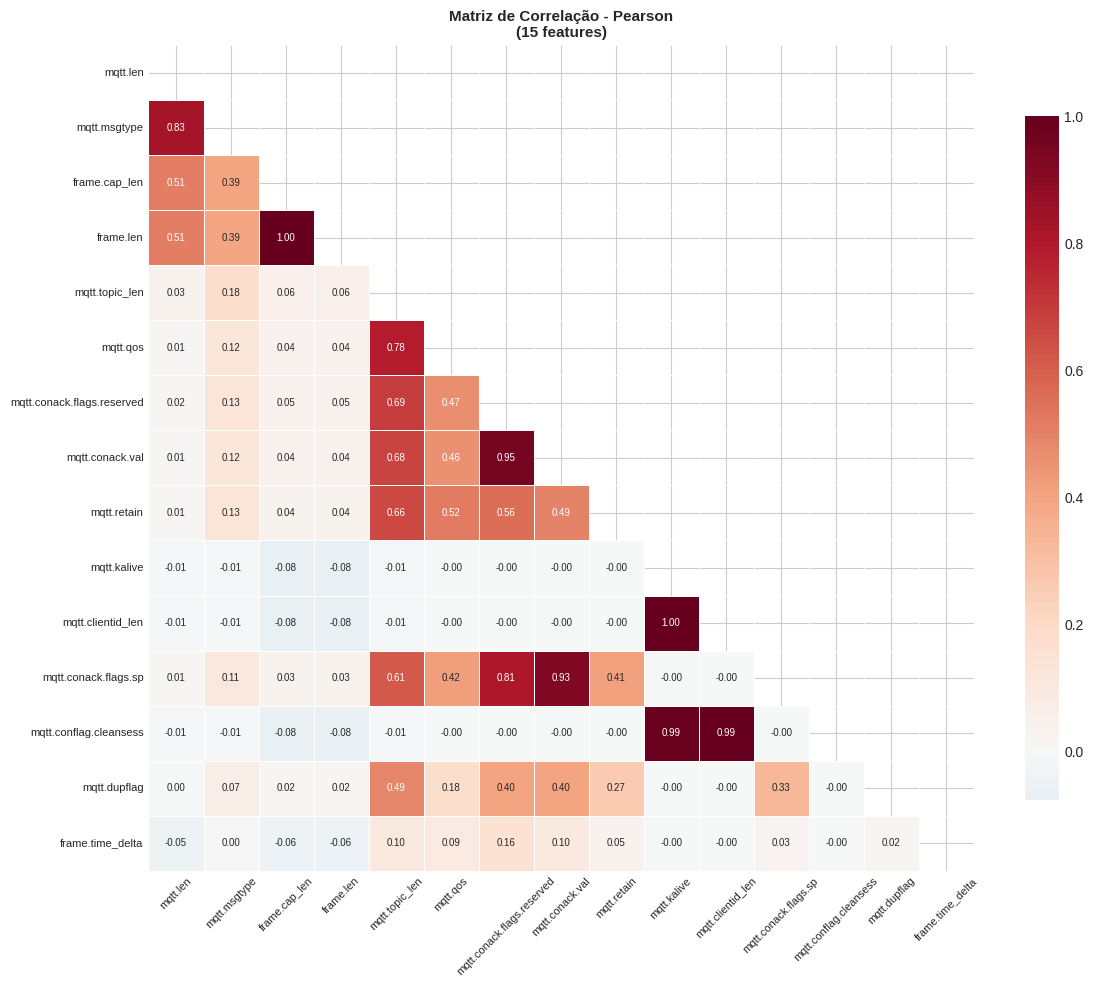

📊 Média da correlação absoluta (Pearson): 0.1998


In [47]:
fig, ax = plt.subplots(figsize=(12, 10))
mean_corr_pearson = plot_correlation_matrix(X, pearson_selected, 
                                             f'Matriz de Correlação - Pearson\n({len(pearson_selected)} features)', 
                                             ax, cmap='RdBu_r')
plt.tight_layout()
plt.show()
print(f"📊 Média da correlação absoluta (Pearson): {mean_corr_pearson:.4f}")

### Matriz de correlação - ExtraTrees 

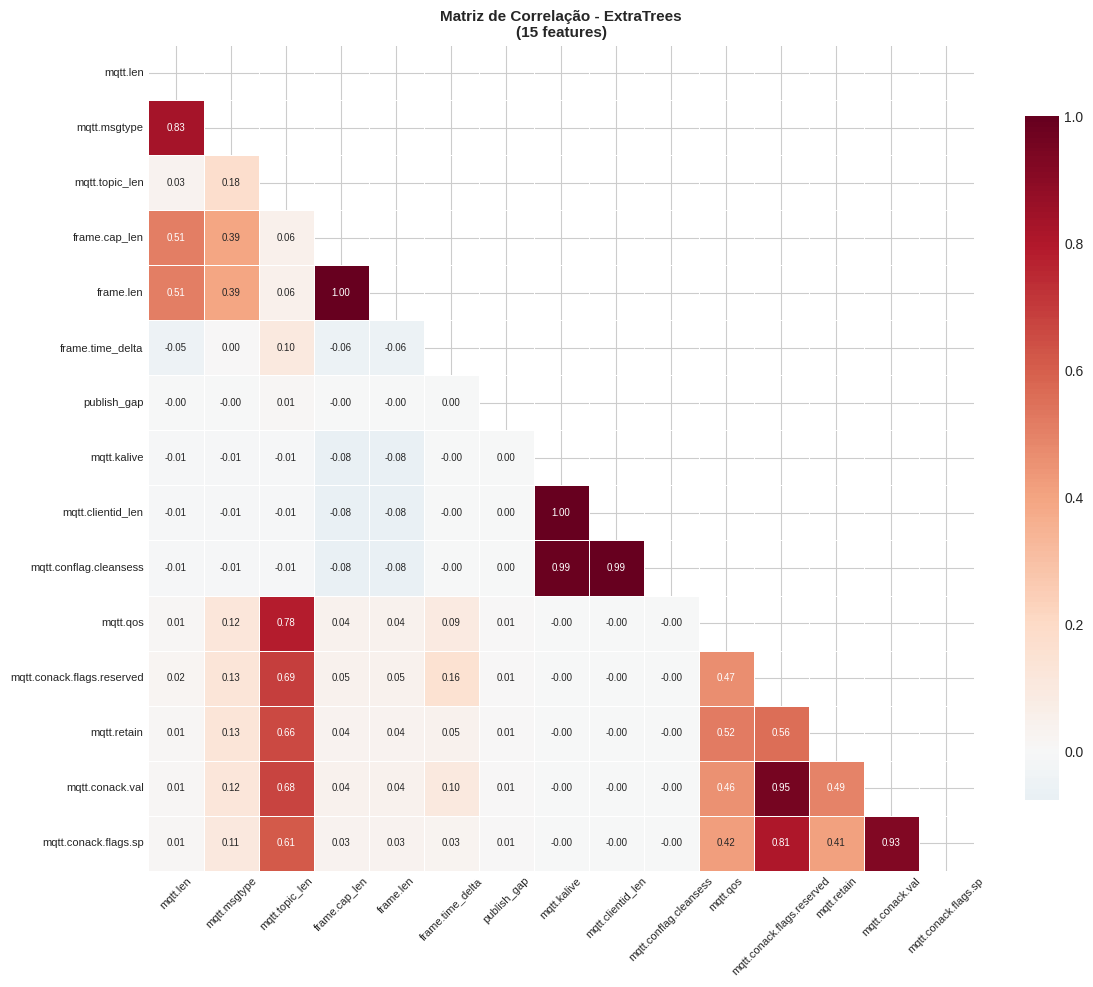

📊 Média da correlação absoluta (ExtraTrees): 0.1792


In [48]:
fig, ax = plt.subplots(figsize=(12, 10))
mean_corr_tree = plot_correlation_matrix(X, extratree_selected, 
                                          f'Matriz de Correlação - ExtraTrees\n({len(extratree_selected)} features)', 
                                          ax, cmap='RdBu_r')
plt.tight_layout()
plt.show()
print(f"📊 Média da correlação absoluta (ExtraTrees): {mean_corr_tree:.4f}")

### Matriz de correalação - LinearSVC

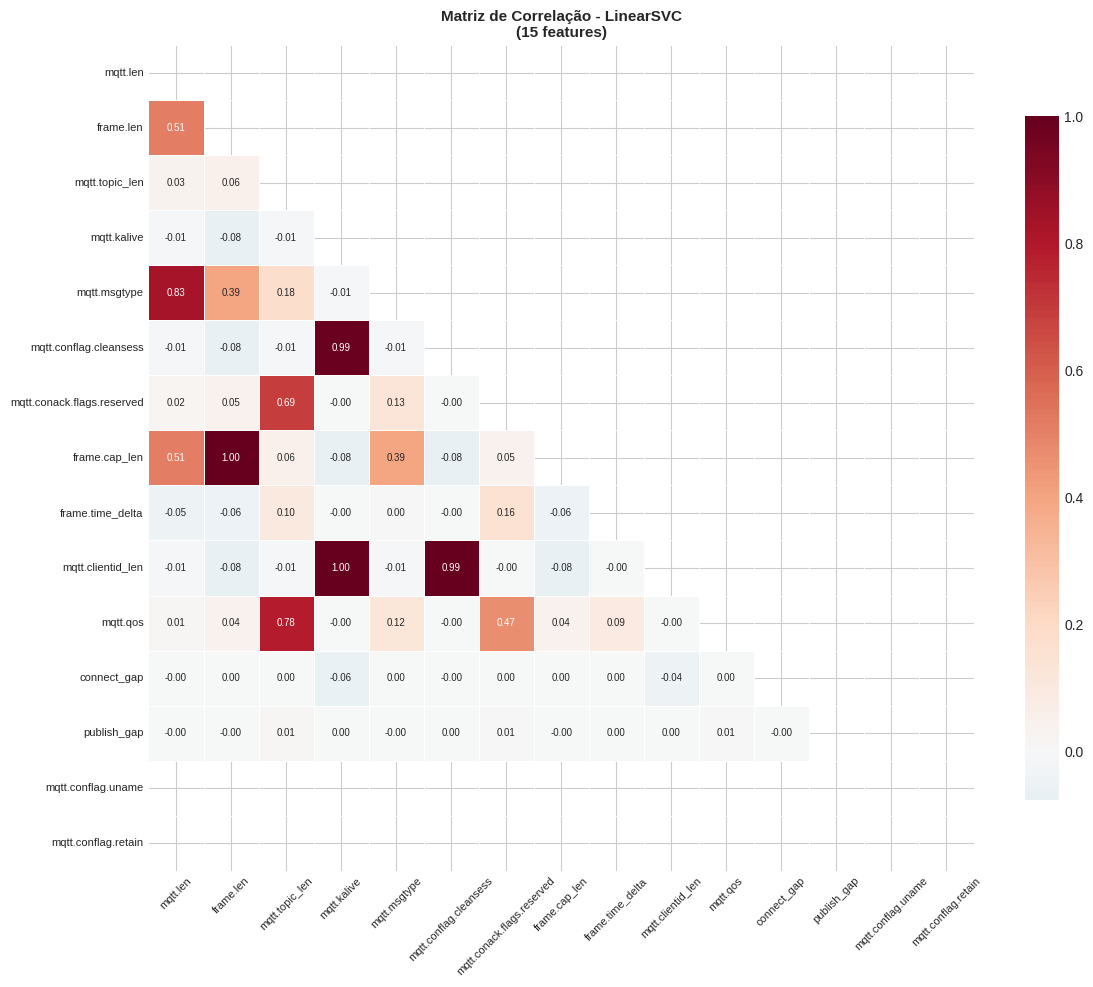

📊 Média da correlação absoluta (LinearSVC): nan


In [49]:
fig, ax = plt.subplots(figsize=(12, 10))
mean_corr_svc = plot_correlation_matrix(X, svc_selected, 
                                         f'Matriz de Correlação - LinearSVC\n({len(svc_selected)} features)', 
                                         ax, cmap='RdBu_r')
plt.tight_layout()
plt.show()
print(f"📊 Média da correlação absoluta (LinearSVC): {mean_corr_svc:.4f}")

### Matriz de correlação - Lasso

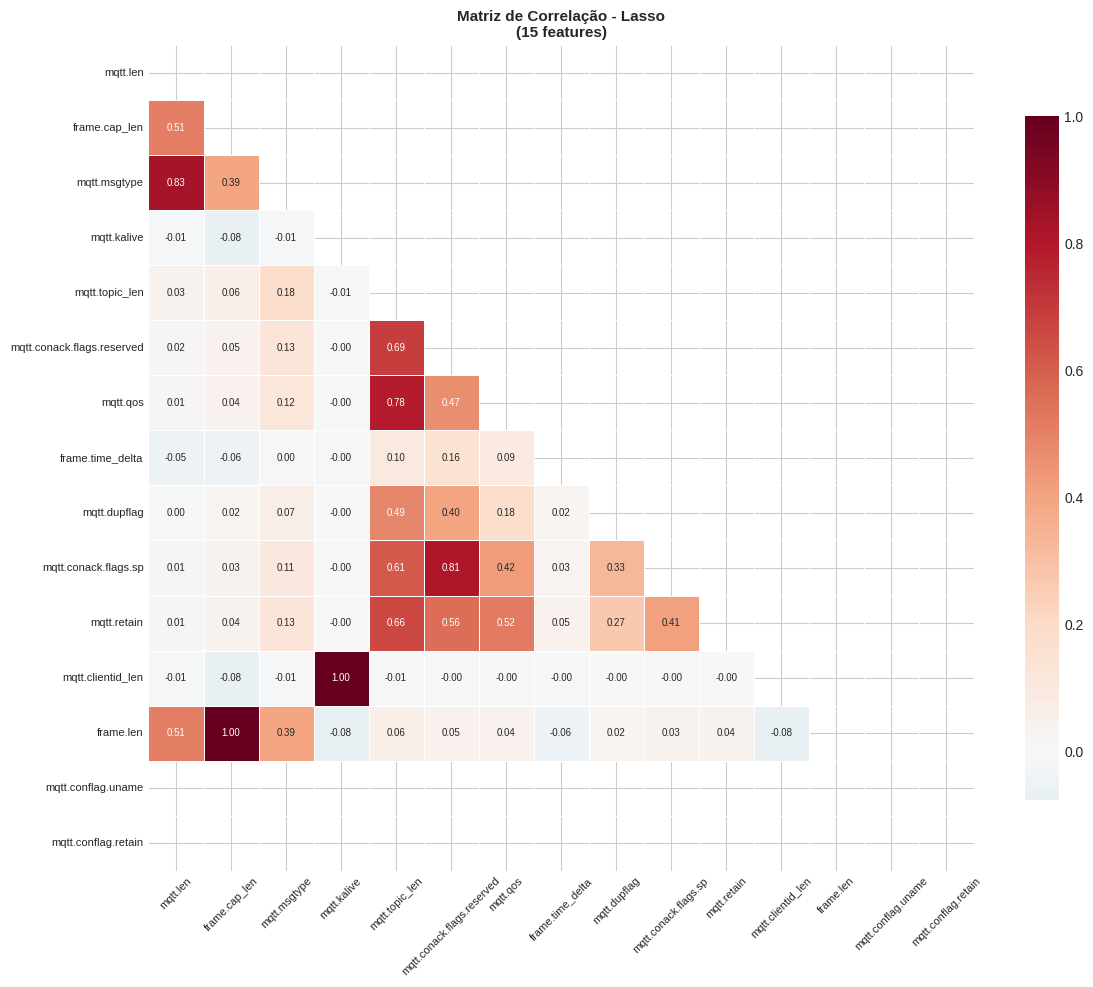

📊 Média da correlação absoluta (Lasso): nan


In [50]:
fig, ax = plt.subplots(figsize=(12, 10))
mean_corr_lasso = plot_correlation_matrix(X, lasso_selected, 
                                           f'Matriz de Correlação - Lasso\n({len(lasso_selected)} features)', 
                                           ax, cmap='RdBu_r')
plt.tight_layout()
plt.show()
print(f"📊 Média da correlação absoluta (Lasso): {mean_corr_lasso:.4f}")

### Comparação de redundância entre os métodos 

COMPARAÇÃO: Redundância entre Features Selecionadas
Média da correlação absoluta (menor = menos redundância):

    Método  Média |Correlação|
ExtraTrees            0.179233
    Fisher            0.199783
   Pearson            0.199783
      mRMR            0.199783
 LinearSVC                 NaN
     Lasso                 NaN


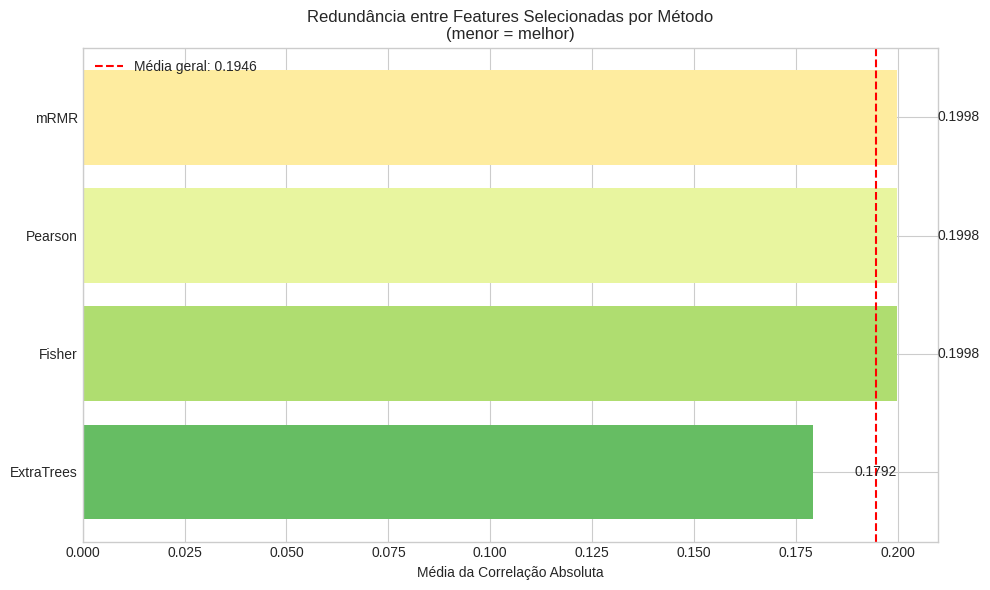


 Método com menor redundância: ExtraTrees (0.1792)


In [51]:
print("COMPARAÇÃO: Redundância entre Features Selecionadas")
print("=" * 60)
print("Média da correlação absoluta (menor = menos redundância):\n")

redundancy_df = pd.DataFrame({
    'Método': ['mRMR', 'Fisher', 'Pearson', 'ExtraTrees', 'LinearSVC', 'Lasso'],
    'Média |Correlação|': [mean_corr_mrmr, mean_corr_fisher, mean_corr_pearson, 
                           mean_corr_tree, mean_corr_svc, mean_corr_lasso]
}).sort_values('Média |Correlação|')

print(redundancy_df.to_string(index=False))

# Visualizar
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(redundancy_df)))

bars = ax.barh(redundancy_df['Método'], redundancy_df['Média |Correlação|'], color=colors)
ax.set_xlabel('Média da Correlação Absoluta')
ax.set_title('Redundância entre Features Selecionadas por Método\n(menor = melhor)', fontsize=12)
ax.axvline(x=redundancy_df['Média |Correlação|'].mean(), color='red', linestyle='--', 
           label=f'Média geral: {redundancy_df["Média |Correlação|"].mean():.4f}')
ax.legend()

for bar, val in zip(bars, redundancy_df['Média |Correlação|']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n Método com menor redundância: {redundancy_df.iloc[0]['Método']} ({redundancy_df.iloc[0]['Média |Correlação|']:.4f})")

### Visualização compacta

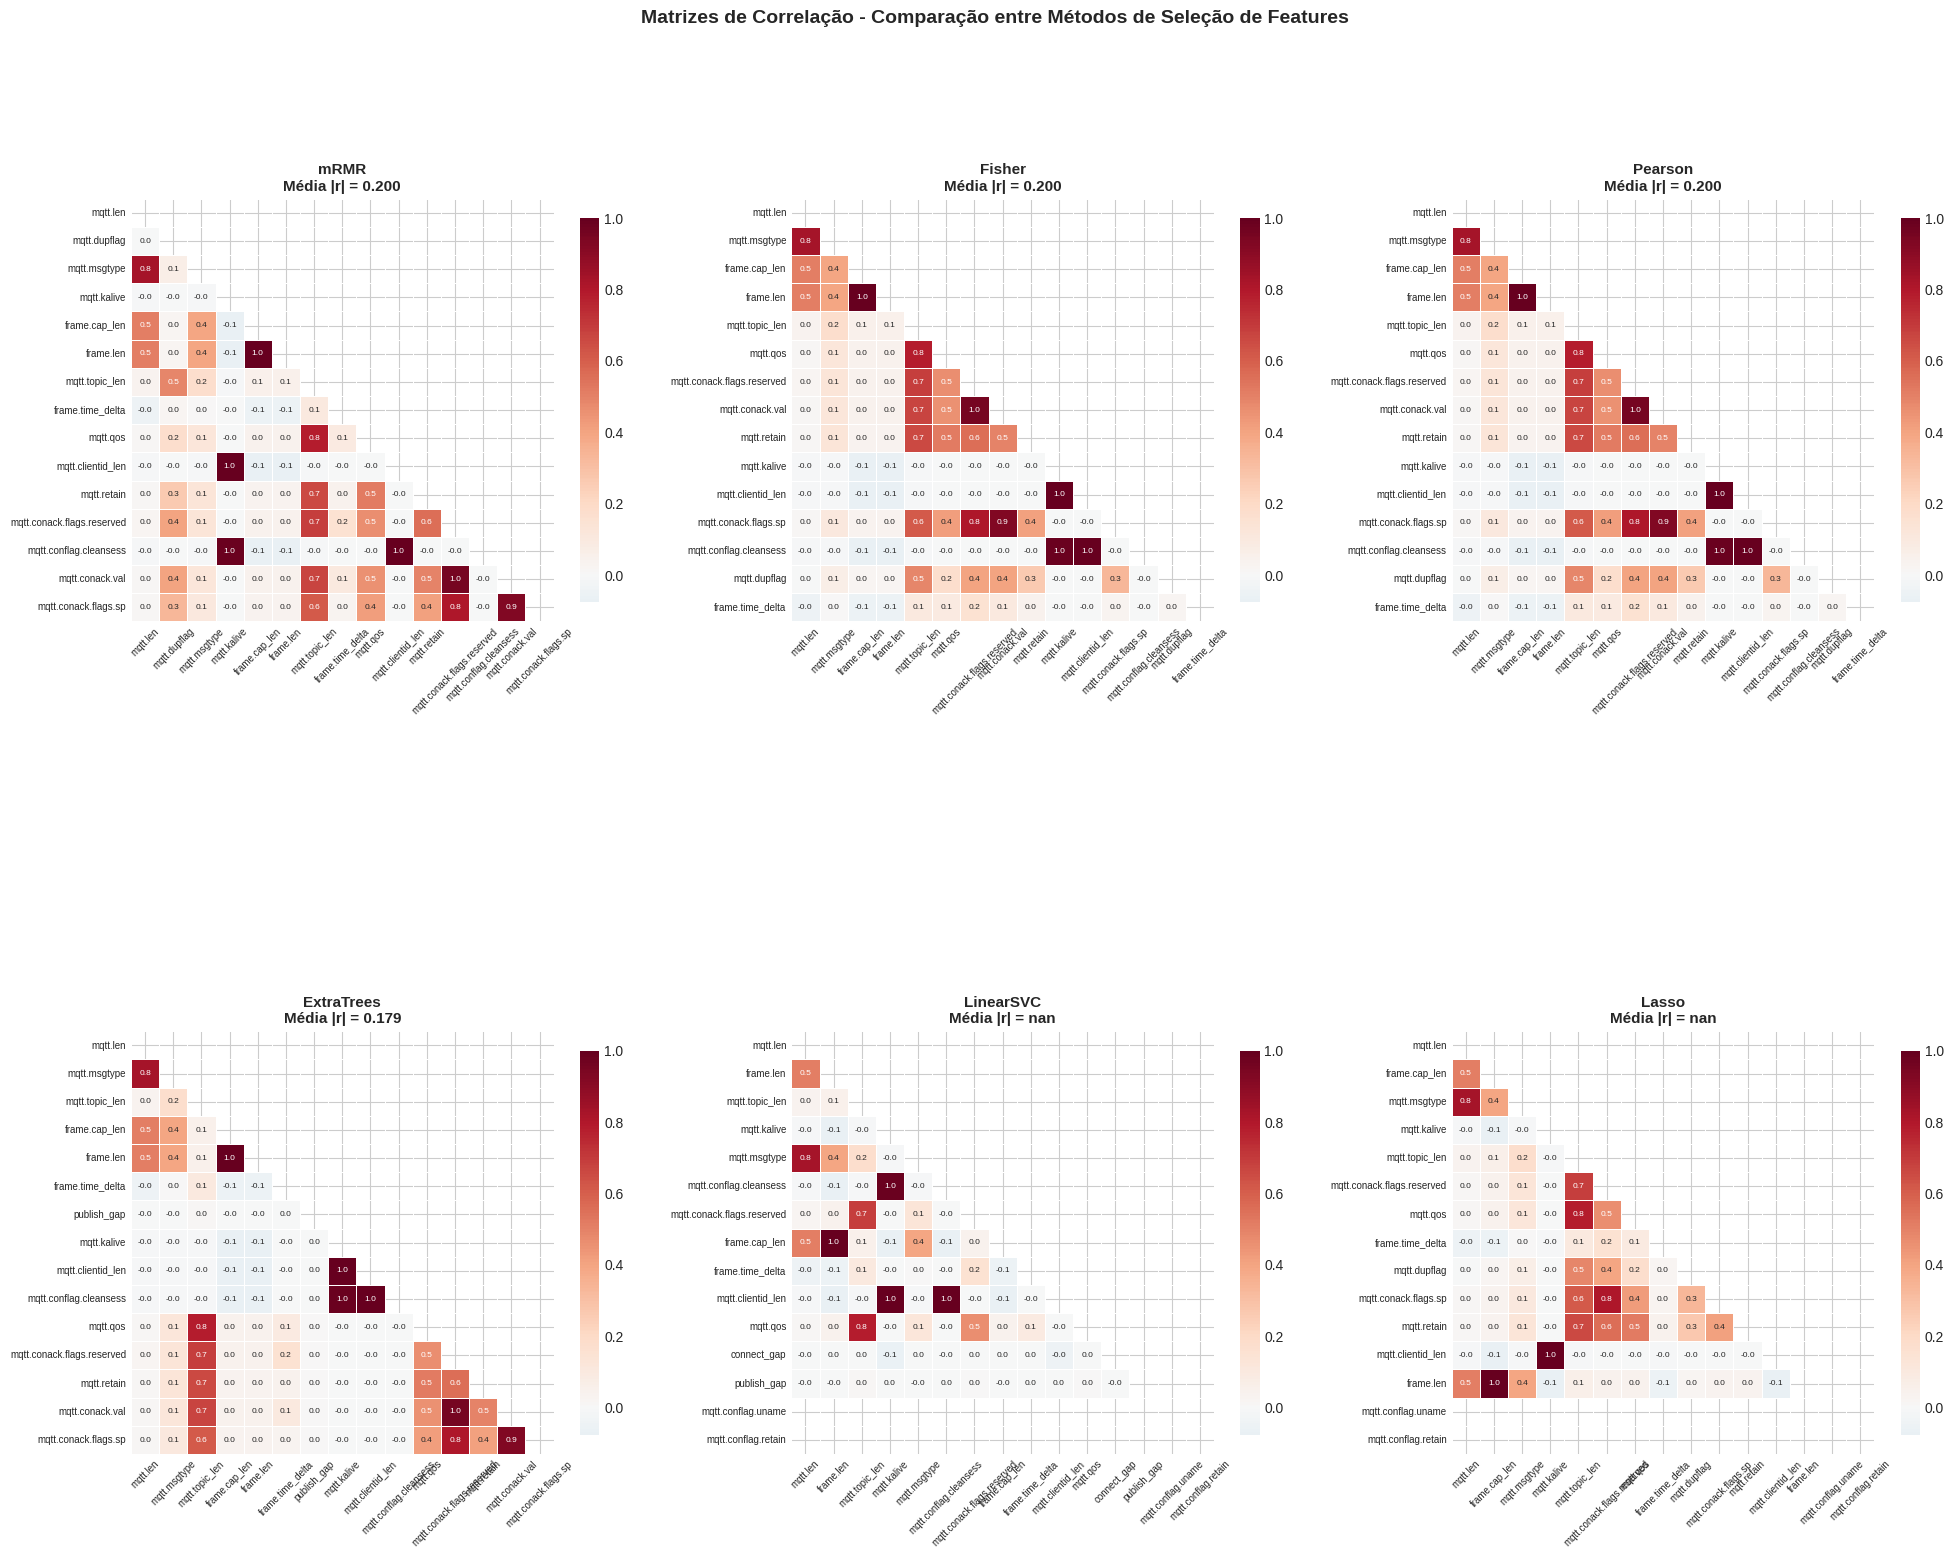

In [52]:
fig, axes = plt.subplots(2, 3, figsize=(20, 16))

methods_data = [
    (mrmr_selected, 'mRMR', axes[0, 0], mean_corr_mrmr),
    (fisher_selected, 'Fisher', axes[0, 1], mean_corr_fisher),
    (pearson_selected, 'Pearson', axes[0, 2], mean_corr_pearson),
    (extratree_selected, 'ExtraTrees', axes[1, 0], mean_corr_tree),
    (svc_selected, 'LinearSVC', axes[1, 1], mean_corr_svc),
    (lasso_selected, 'Lasso', axes[1, 2], mean_corr_lasso)
]

for features, name, ax, mean_corr in methods_data:
    X_subset = X[features]
    corr = X_subset.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, 
                annot=True, fmt='.1f', square=True, linewidths=0.5, ax=ax,
                cbar_kws={"shrink": 0.6},
                annot_kws={"size": 6})
    ax.set_title(f'{name}\nMédia |r| = {mean_corr:.3f}', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)

plt.suptitle('Matrizes de Correlação - Comparação entre Métodos de Seleção de Features', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.93, hspace=0.3, wspace=0.25)
plt.show()

### Tabela de resultados 

In [53]:
print("=" * 80)
print("RESULTADOS CONSOLIDADOS - SELEÇÃO DE FEATURES")
print("=" * 80)

# Tabela de acurácias e redundância
final_results = pd.DataFrame({
    'Método': ['mRMR', 'Fisher', 'Pearson', 'ExtraTrees', 'LinearSVC', 'Lasso'],
    'Num Features': [len(mrmr_selected), K_fisher, K_pearson, K_tree, K_svc, K_lasso],
    'Acurácia': [acc_mrmr, acc_fisher, acc_pearson, acc_tree, acc_svc, acc_lasso],
    'Média |Correlação|': [mean_corr_mrmr, mean_corr_fisher, mean_corr_pearson, 
                           mean_corr_tree, mean_corr_svc, mean_corr_lasso]
})

# Adicionar baseline (todas features)
baseline = pd.DataFrame({
    'Método': ['BASELINE (Todas)'],
    'Num Features': [X.shape[1]],
    'Acurácia': [acc_all],
    'Média |Correlação|': [np.nan]
})

final_results = pd.concat([baseline, final_results], ignore_index=True)
final_results['Redução Features (%)'] = ((X.shape[1] - final_results['Num Features']) / X.shape[1] * 100).round(1)
final_results['Δ Acurácia vs Baseline'] = (final_results['Acurácia'] - acc_all).round(4)

print("\n📈 Comparação de Performance:\n")
print(final_results.to_string(index=False))

# Melhor método por critério
print("\n" + "=" * 80)
print("🏆 RANKING POR CRITÉRIO:")
print("=" * 80)

best_acc = final_results[final_results['Método'] != 'BASELINE (Todas)'].sort_values('Acurácia', ascending=False).iloc[0]
print(f"\n✅ Maior Acurácia: {best_acc['Método']} ({best_acc['Acurácia']:.4f})")

best_redundancy = final_results[final_results['Método'] != 'BASELINE (Todas)'].sort_values('Média |Correlação|').iloc[0]
print(f"✅ Menor Redundância: {best_redundancy['Método']} ({best_redundancy['Média |Correlação|']:.4f})")

# Trade-off: melhor relação acurácia/redundância
final_results_filtered = final_results[final_results['Método'] != 'BASELINE (Todas)'].copy()
final_results_filtered['Score'] = final_results_filtered['Acurácia'] / (final_results_filtered['Média |Correlação|'] + 0.01)
best_tradeoff = final_results_filtered.sort_values('Score', ascending=False).iloc[0]
print(f"✅ Melhor Trade-off (Acurácia/Redundância): {best_tradeoff['Método']}")

RESULTADOS CONSOLIDADOS - SELEÇÃO DE FEATURES

📈 Comparação de Performance:

          Método  Num Features  Acurácia  Média |Correlação|  Redução Features (%)  Δ Acurácia vs Baseline
BASELINE (Todas)            29  0.973651                 NaN                   0.0                  0.0000
            mRMR            15  0.973580            0.199783                  48.3                 -0.0001
          Fisher            15  0.973616            0.199783                  48.3                 -0.0000
         Pearson            15  0.973616            0.199783                  48.3                 -0.0000
      ExtraTrees            15  0.973721            0.179233                  48.3                  0.0001
       LinearSVC            15  0.973721                 NaN                  48.3                  0.0001
           Lasso            15  0.973580                 NaN                  48.3                 -0.0001

🏆 RANKING POR CRITÉRIO:

✅ Maior Acurácia: LinearSVC (0.9737)
✅ Me

### Definição e análise de features mais importantes por consenso entre métodos

In [46]:
# (Movido) A análise de consenso das features foi realocada para o final do notebook.
print("Análise de consenso das features movida para o final do notebook. Vá para a seção final para os resultados.")

Análise de consenso das features movida para o final do notebook. Vá para a seção final para os resultados.


## Análise de consenso movida
A contagem de features mais selecionadas e o mapa de quais métodos selecionaram cada feature agora estão nas últimas células do notebook.

In [66]:
# ig, axes = plt.subplots(1, 2, figsize=(16, 8))

# # Gráfico 1: Top 15 features por número de métodos que as selecionaram
# ax1 = axes[0]
# top15_consensus = feature_importance_df.head(15)
# colors = plt.cm.RdYlGn(top15_consensus['Num Métodos'].values / 6)

# bars = ax1.barh(range(len(top15_consensus)), top15_consensus['Num Métodos'].values, color=colors)
# ax1.set_yticks(range(len(top15_consensus)))
# ax1.set_yticklabels(top15_consensus['Feature'].values)
# ax1.set_xlabel('Número de Métodos que Selecionaram')
# ax1.set_title('Top 15 Features por Consenso\n(mais métodos = mais confiável)', fontsize=12)
# ax1.invert_yaxis()
# ax1.set_xlim(0, 6.5)

# for bar, count in zip(bars, top15_consensus['Num Métodos'].values):
#     ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
#              f'{count}/6', va='center', fontsize=10, fontweight='bold')

# # Gráfico 2: Heatmap de seleção por método
# ax2 = axes[1]
# # Criar matriz de presença
# presence_matrix = pd.DataFrame(index=top15_consensus['Feature'].values, 
#                                 columns=['mRMR', 'Fisher', 'Pearson', 'ExtraTrees', 'LinearSVC', 'Lasso'])

# for feature in presence_matrix.index:
#     for method in presence_matrix.columns:
#         presence_matrix.loc[feature, method] = 1 if feature in all_selected[method] else 0

# presence_matrix = presence_matrix.astype(int)

# sns.heatmap(presence_matrix, cmap='RdYlGn', center=0.5, annot=True, fmt='d',
#             linewidths=0.5, ax=ax2, cbar_kws={'label': 'Selecionada (1) / Não (0)'})
# ax2.set_title('Matriz de Seleção: Feature × Método', fontsize=12)
# ax2.set_xlabel('Método de Seleção')
# ax2.set_ylabel('Feature')

# plt.tight_layout()
# plt.show()

In [67]:
# # Exportar resultados consolidados
# output_dir = Path("../reports")
# output_dir.mkdir(exist_ok=True)

# # 1. Salvar tabela de resultados por método
# final_results.to_csv(output_dir / "feature_selection_with_gaps_results.csv", index=False)
# print(f"✅ Resultados salvos em: {output_dir / 'feature_selection_with_gaps_results.csv'}")

# # 2. Salvar ranking de features por consenso
# feature_importance_df.to_csv(output_dir / "feature_consensus_ranking.csv", index=False)
# print(f"✅ Ranking de consenso salvo em: {output_dir / 'feature_consensus_ranking.csv'}")

# # 3. Salvar features recomendadas (4+ métodos)
# recommended_features = feature_importance_df[feature_importance_df['Num Métodos'] >= 4]
# recommended_features.to_csv(output_dir / "recommended_features.csv", index=False)
# print(f"✅ Features recomendadas salvas em: {output_dir / 'recommended_features.csv'}")

# print(f"\n📊 Total de features recomendadas (4+ métodos): {len(recommended_features)}")
# print("\n🎯 Features Recomendadas para Modelo Final:")
# for _, row in recommended_features.iterrows():
#     print(f"   • {row['Feature']} ({row['Num Métodos']}/6 métodos)")

In [49]:
# # Exportar dataset com as features selecionadas por consenso (4+ métodos)
# output_path = Path("../data/processed/DoS_features_with_gaps.csv")

# # Criar dataset com as features selecionadas + label
# X_final = X[features_4plus].copy()
# X_final['type'] = df['type'].values

# # Salvar o dataset
# X_final.to_csv(output_path, index=False)

# print(f"✅ Dataset exportado com sucesso para: {output_path}")
# print(f"📊 Shape do dataset exportado: {X_final.shape}")
# print(f"🔹 Features exportadas ({len(features_4plus)}):")
# for i, f in enumerate(features_4plus, 1):
#     print(f"  {i:2d}. {f}")
# print(f"\n🏷️ Distribuição do Label ('type'):")
# print(X_final['type'].value_counts())

## Avaliação unificada de seletores e modelos
Fluxo alinhado ao notebook model_training: aproveita os seletores já calculados aqui e avalia 6 modelos (RandomForest, Regressão Logística, KNN, Decision Tree, Naive Bayes, SVM RBF) com métricas accuracy, precision_macro, recall_macro, f1_macro, MCC e log_loss.

In [55]:
# Função auxiliar para avaliar um conjunto de features com 6 classificadores
def evaluate_feature_set(name, features, X, y, test_size=0.3, random_state=42):
    if features is None or len(features) == 0:
        print(f"⚠️ {name}: lista de features vazia, pulando.")
        return pd.DataFrame()
    filtered = [f for f in features if f in X.columns]
    if len(filtered) == 0:
        print(f"⚠️ {name}: nenhuma feature filtrada encontrada em X, pulando.")
        return pd.DataFrame()
    
    X_sel = X[filtered].copy()
    X_train, X_test, y_train, y_test = train_test_split(
        X_sel, y, test_size=test_size, stratify=y, random_state=random_state
    )
    classes = np.unique(y_train)
    
    models = {
        "RandomForest": RandomForestClassifier(
            n_estimators=150, max_depth=None, random_state=random_state, n_jobs=-1
        ),
        "LogisticRegression": make_pipeline(
            StandardScaler(), LogisticRegression(max_iter=1000, n_jobs=-1, solver="lbfgs")
        ),
        "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7)),
        "DecisionTree": DecisionTreeClassifier(random_state=random_state),
        "NaiveBayes": GaussianNB(),
        "SVM_RBF": make_pipeline(StandardScaler(), SVC(kernel='rbf', C=3, gamma='scale', probability=True, random_state=random_state))
    }
    
    rows = []
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        try:
            y_proba = model.predict_proba(X_test)
        except Exception:
            y_proba = None
        # ROC AUC: binário usa coluna positiva; multiclasse usa OvR macro
        if y_proba is not None:
            try:
                if len(classes) == 2 and y_proba.shape[1] >= 2:
                    roc_auc_macro = roc_auc_score(y_test, y_proba[:, 1])
                else:
                    roc_auc_macro = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
            except Exception:
                roc_auc_macro = np.nan
        else:
            roc_auc_macro = np.nan
        rows.append({
            "feature_set": name,
            "n_features": len(filtered),
            "model": model_name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "mcc": matthews_corrcoef(y_test, y_pred),
            "log_loss": sk_log_loss(y_test, y_proba) if y_proba is not None else np.nan,
            "roc_auc_macro": roc_auc_macro
        })
    
    return pd.DataFrame(rows)

In [56]:
# Avaliar todos os seletores já calculados no notebook
from sklearn.linear_model import LogisticRegression  # garante disponibilidade mesmo se a célula de import não for reexecutada
feature_sets = {
    "mrmr": globals().get('mrmr_selected_features', []),
    "fisher": globals().get('fisher_selected', []),
    "pearson": globals().get('pearson_selected', []),
    "low_variance": globals().get('features_mantidas', []),
    "extratrees": globals().get('extratree_selected', []),
    "linear_svc_l1": globals().get('svc_selected', []),
    "lasso_cv": globals().get('lasso_selected', [])
}
all_results = []
for name, feats in feature_sets.items():
    res = evaluate_feature_set(name, feats, X, y)
    if not res.empty:
        all_results.append(res)
        print(f"✅ {name}: {len(feats)} features avaliadas")
    else:
        print(f"⏭️ {name}: sem resultados")
        
if all_results:
    results_df = pd.concat(all_results).sort_values(["feature_set", "model"]).reset_index(drop=True)
    display(results_df)
    best_per_set = results_df.loc[results_df.groupby('feature_set')["accuracy"].idxmax()]
    print("\n🏁 Melhor modelo por conjunto de features (ordem por acurácia):")
    print(best_per_set.sort_values("accuracy", ascending=False).to_string(index=False))
else:
    print("Nenhum resultado gerado. Revise as listas de features.")

✅ mrmr: 15 features avaliadas
✅ fisher: 15 features avaliadas
✅ pearson: 15 features avaliadas
✅ low_variance: 10 features avaliadas
✅ extratrees: 15 features avaliadas
✅ linear_svc_l1: 15 features avaliadas
✅ lasso_cv: 15 features avaliadas


,feature_set,n_features,model,accuracy,precision_macro,recall_macro,f1_macro,mcc,log_loss,roc_auc_macro
0,extratrees,15,DecisionTree,0.966570,0.966704,0.966354,0.966510,0.933058,0.683287,0.979701
1,extratrees,15,KNN,0.969529,0.969860,0.969189,0.969465,0.939048,0.369848,0.988069
2,extratrees,15,LogisticRegression,0.925919,0.935510,0.923263,0.925095,0.858686,0.169155,0.971384
3,extratrees,15,NaiveBayes,0.924510,0.933592,0.921919,0.923698,0.855431,2.696147,0.894049
4,extratrees,15,RandomForest,0.969248,0.969595,0.968896,0.969182,0.938491,0.300834,0.989869
5,extratrees,15,SVM_RBF,0.931626,0.941160,0.929011,0.930877,0.870086,0.212283,0.920187
6,fisher,15,DecisionTree,0.966535,0.966674,0.966315,0.966474,0.932988,0.683356,0.979690
7,fisher,15,KNN,0.969459,0.969776,0.969126,0.969395,0.938902,0.368964,0.988029
8,fisher,15,LogisticRegression,0.926025,0.935647,0.923365,0.925200,0.858925,0.169197,0.971385
9,fisher,15,NaiveBayes,0.924510,0.933592,0.921919,0.923698,0.855431,2.567520,0.892545



🏁 Melhor modelo por conjunto de features (ordem por acurácia):
  feature_set  n_features model  accuracy  precision_macro  recall_macro  f1_macro      mcc  log_loss  roc_auc_macro
   extratrees          15   KNN  0.969529         0.969860      0.969189  0.969465 0.939048  0.369848       0.988069
     lasso_cv          15   KNN  0.969529         0.969851      0.969194  0.969466 0.939045  0.368865       0.988043
       fisher          15   KNN  0.969459         0.969776      0.969126  0.969395 0.938902  0.368964       0.988029
      pearson          15   KNN  0.969459         0.969776      0.969126  0.969395 0.938902  0.368964       0.988029
         mrmr          15   KNN  0.969459         0.969776      0.969126  0.969395 0.938902  0.368964       0.988029
linear_svc_l1          15   KNN  0.969424         0.969726      0.969100  0.969361 0.938826  0.370192       0.987993
 low_variance          10   KNN  0.966887         0.967896      0.966211  0.966789 0.934106  0.384155       0.983928


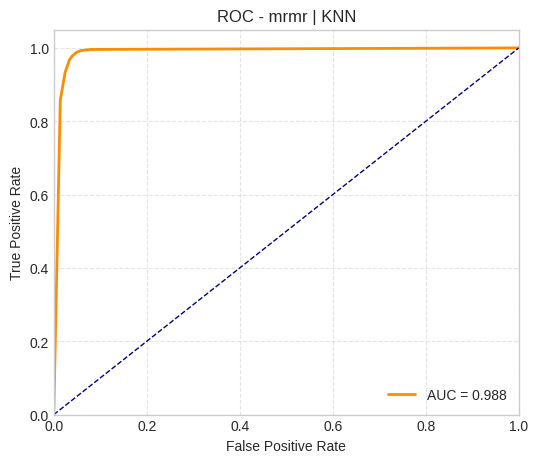

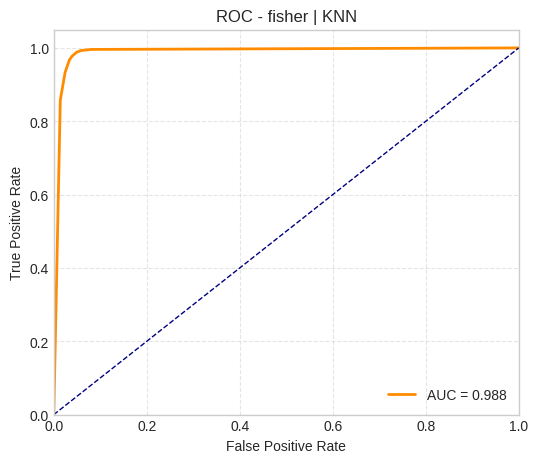

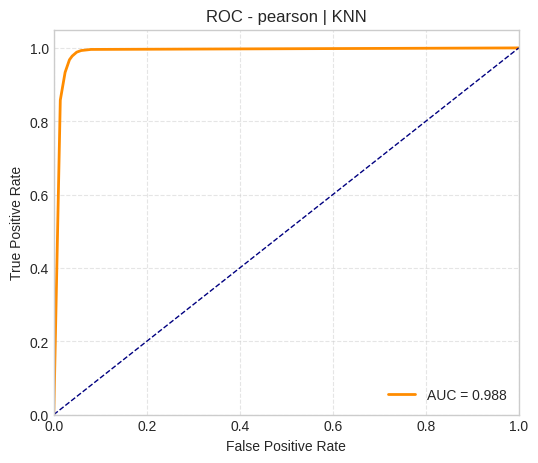

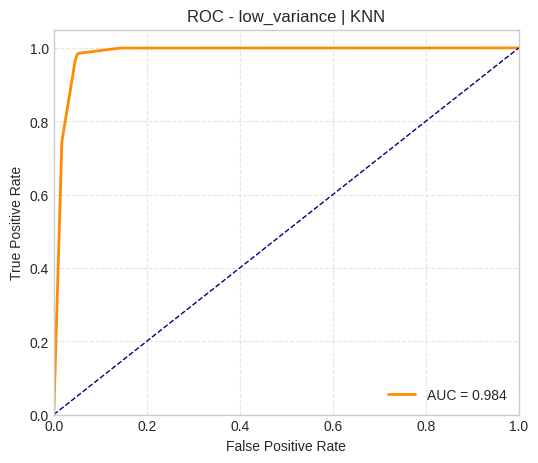

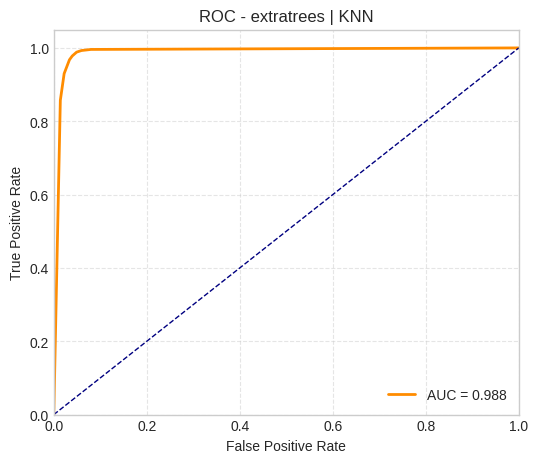

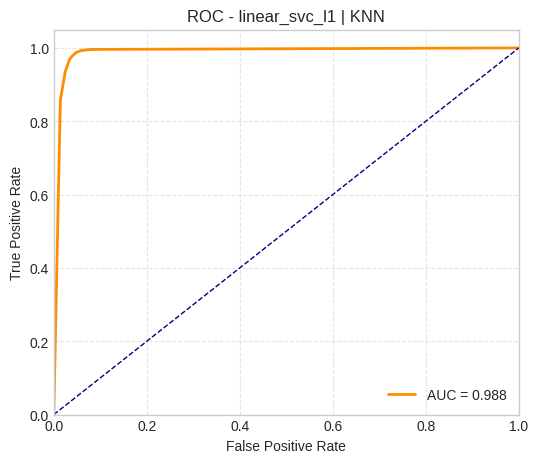

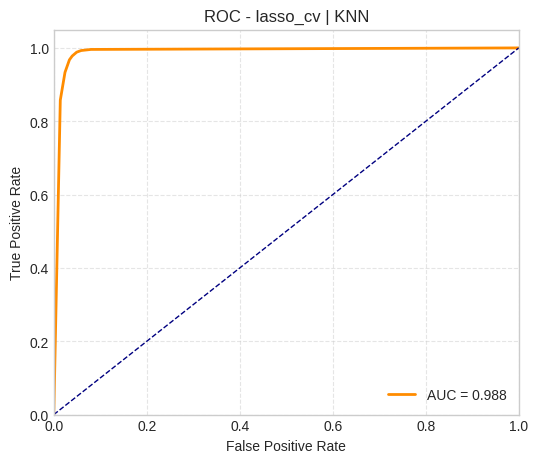

In [58]:
# Curvas ROC (macro) para o melhor modelo de cada conjunto de features
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
import itertools

if 'results_df' in globals():
    for name, feats in feature_sets.items():
        subset = results_df[results_df['feature_set'] == name]
        if subset.empty:
            continue
        # Seleciona o melhor modelo pela acurácia
        best_model_name = subset.sort_values('accuracy', ascending=False).iloc[0]['model']
        # Reutiliza o mesmo split para consistência
        filtered = [f for f in feats if f in X.columns]
        if len(filtered) == 0:
            print(f"⏭️ {name}: nenhuma feature válida para ROC.")
            continue
        X_sel = X[filtered].copy()
        X_train, X_test, y_train, y_test = train_test_split(
            X_sel, y, test_size=0.3, stratify=y, random_state=42
        )
        models = {
            "RandomForest": RandomForestClassifier(
                n_estimators=150, max_depth=None, random_state=42, n_jobs=-1
            ),
            "LogisticRegression": make_pipeline(
                StandardScaler(), LogisticRegression(max_iter=1000, n_jobs=-1, solver="lbfgs")
            ),
            "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7)),
            "DecisionTree": DecisionTreeClassifier(random_state=42),
            "NaiveBayes": GaussianNB(),
            "SVM_RBF": make_pipeline(StandardScaler(), SVC(kernel='rbf', C=3, gamma='scale', probability=True, random_state=42))
        }
        model = models.get(best_model_name)
        if model is None:
            print(f"⏭️ {name}: modelo {best_model_name} não suportado para ROC.")
            continue
        model.fit(X_train, y_train)
        try:
            y_score = model.predict_proba(X_test)
        except Exception:
            print(f"⏭️ {name}: modelo {best_model_name} não oferece predict_proba.")
            continue
        classes = np.unique(y)
        if len(classes) == 2:
            fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
            roc_auc = auc(fpr, tpr)
            plt.figure(figsize=(6, 5))
            plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
            plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title(f'ROC - {name} | {best_model_name}')
            plt.legend(loc="lower right")
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.show()
        else:
            y_test_bin = label_binarize(y_test, classes=classes)
            fpr = dict()
            tpr = dict()
            roc_auc = dict()
            for i, cls in enumerate(classes):
                fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
                roc_auc[i] = auc(fpr[i], tpr[i])
            fpr['micro'], tpr['micro'], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
            roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])
            plt.figure(figsize=(7, 6))
            plt.plot(fpr['micro'], tpr['micro'], label=f"micro-average ROC (AUC = {roc_auc['micro']:.3f})", color='navy', linestyle=':', linewidth=2)
            colors = itertools.cycle(plt.cm.tab10.colors)
            for i, cls in enumerate(classes):
                color = next(colors)
                plt.plot(fpr[i], tpr[i], color=color, lw=1.5, label=f'Classe {cls} (AUC = {roc_auc[i]:.3f})')
            plt.plot([0, 1], [0, 1], 'k--', lw=1)
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title(f'ROC multiclasses - {name} | {best_model_name}')
            plt.legend(loc='lower right')
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.show()
else:
    print("results_df não encontrado; execute a célula de avaliação primeiro.")

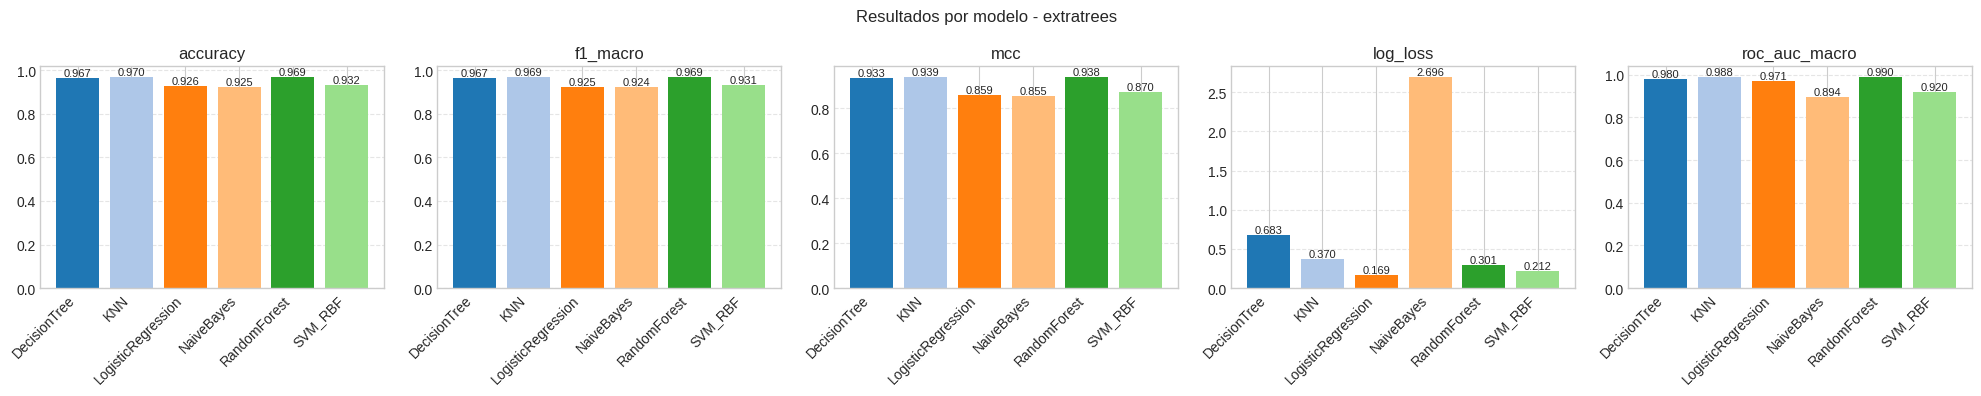

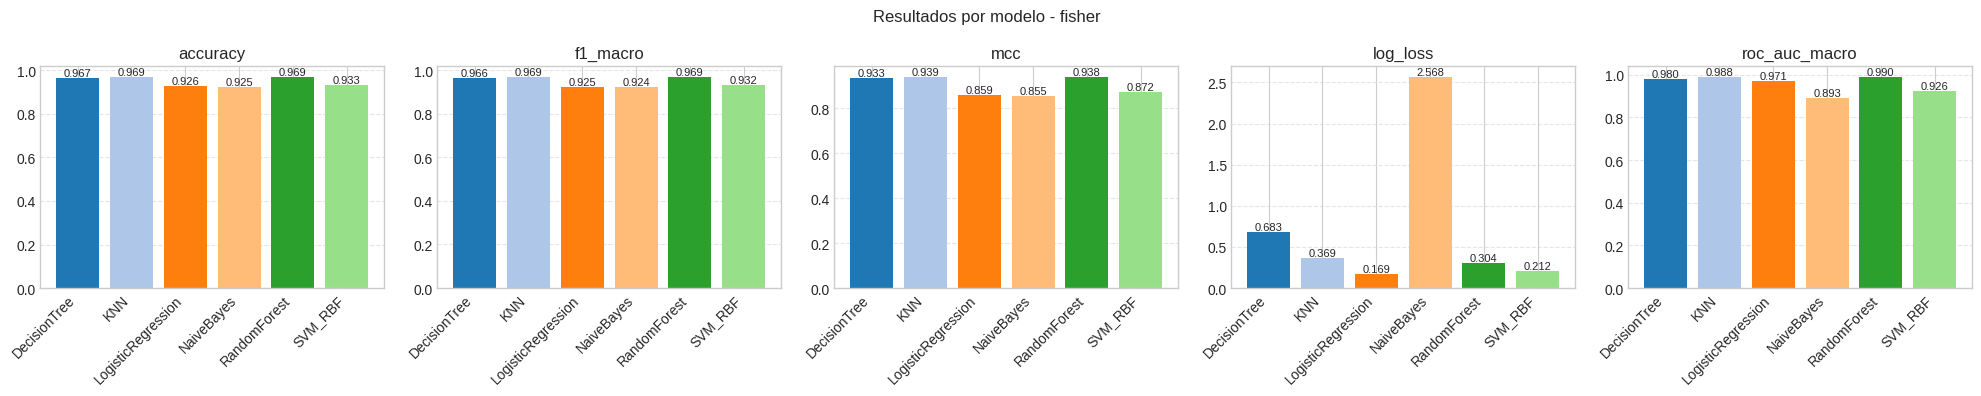

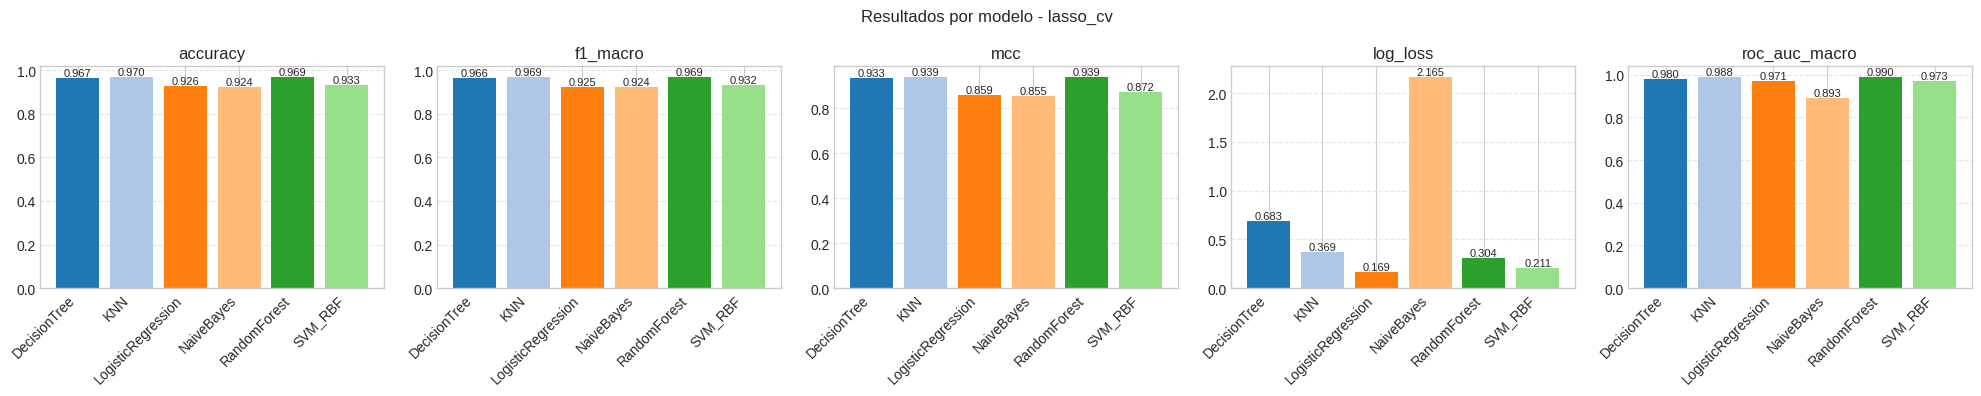

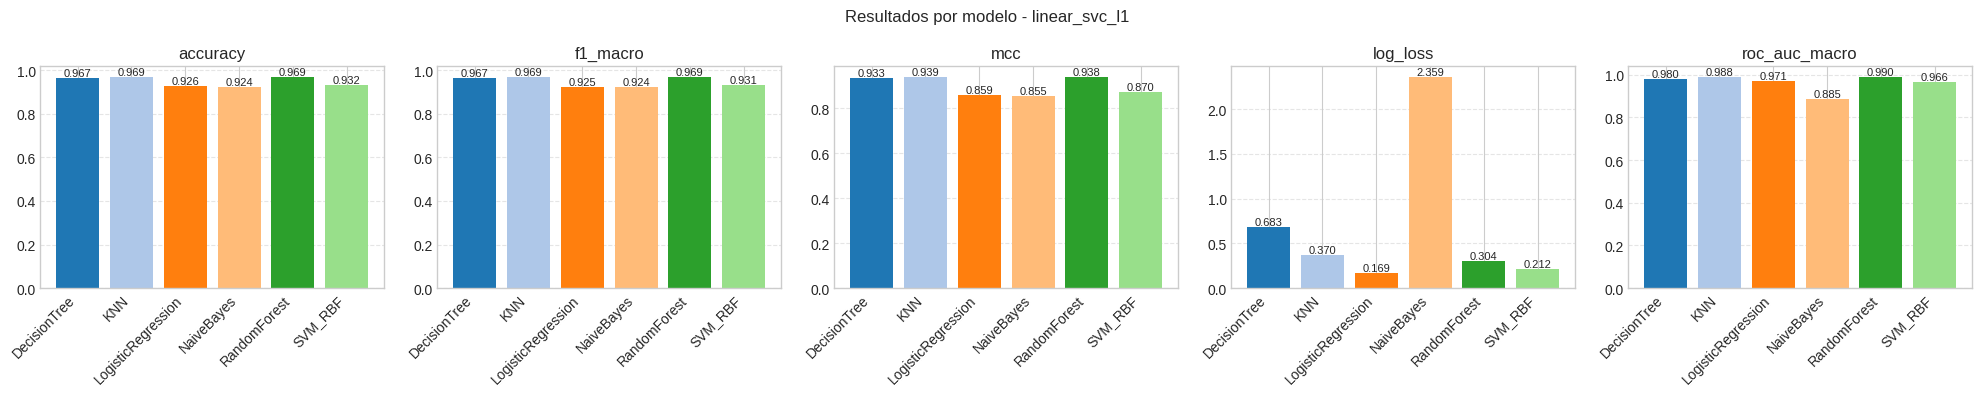

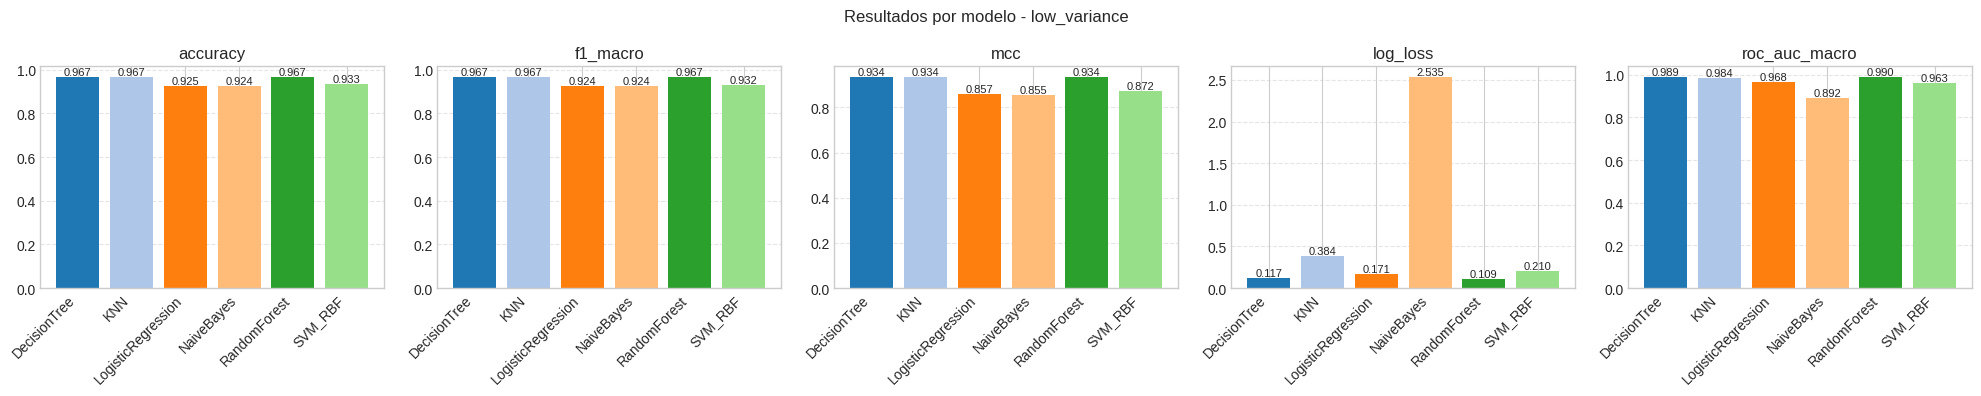

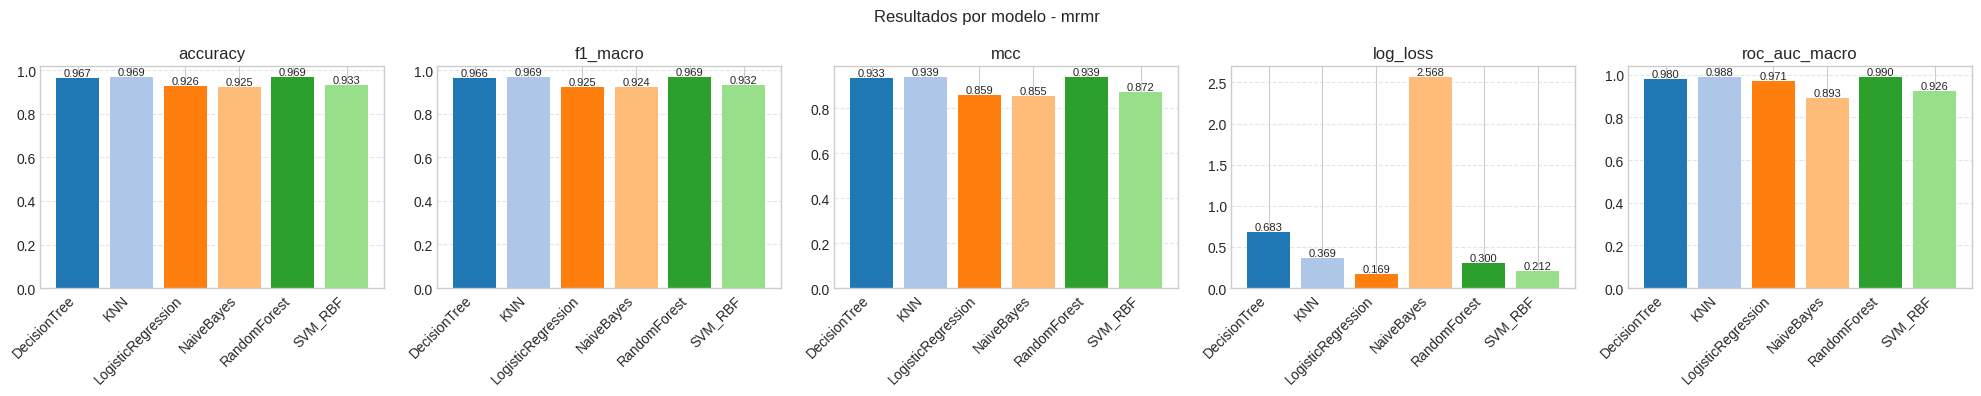

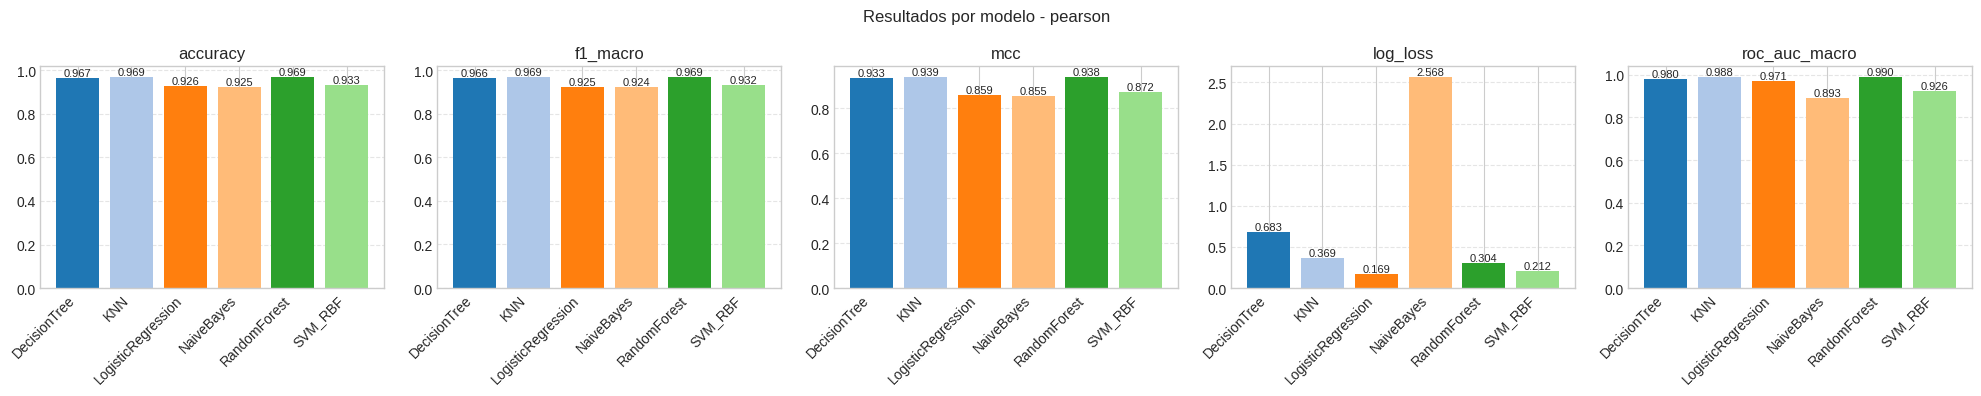

In [59]:
# Gráficos por método: métricas principais (accuracy, f1_macro, mcc, log_loss, roc_auc_macro)
if 'results_df' in globals():
    metrics_to_plot = ["accuracy", "f1_macro", "mcc", "log_loss", "roc_auc_macro"]
    for method in results_df['feature_set'].unique():
        subset = results_df[results_df['feature_set'] == method]
        fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(20, 4), sharex=False)
        fig.suptitle(f"Resultados por modelo - {method}")
        for ax, metric in zip(axes, metrics_to_plot):
            bars = ax.bar(subset['model'], subset[metric], color=plt.cm.tab20.colors[:len(subset)])
            ax.set_title(metric)
            ax.set_xticklabels(subset['model'], rotation=45, ha='right')
            ax.grid(True, axis='y', linestyle='--', alpha=0.5)
            for bar, value in zip(bars, subset[metric]):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{value:.3f}", ha='center', va='bottom', fontsize=8)
        plt.tight_layout()
        plt.show()
else:
    print("results_df não encontrado; execute a célula de avaliação primeiro.")

frame.cap_len                 7
frame.len                     7
mqtt.clientid_len             7
mqtt.topic_len                7
mqtt.msgtype                  7
mqtt.len                      7
mqtt.kalive                   7
mqtt.conack.flags.reserved    6
frame.time_delta              6
mqtt.qos                      6
mqtt.conack.flags.sp          5
mqtt.conflag.cleansess        5
mqtt.retain                   5
mqtt.conack.val               5
mqtt.dupflag                  4
publish_gap                   3
connect_gap                   2
mqtt.conflag.uname            2
mqtt.conflag.retain           2
Name: times_selected, dtype: int64


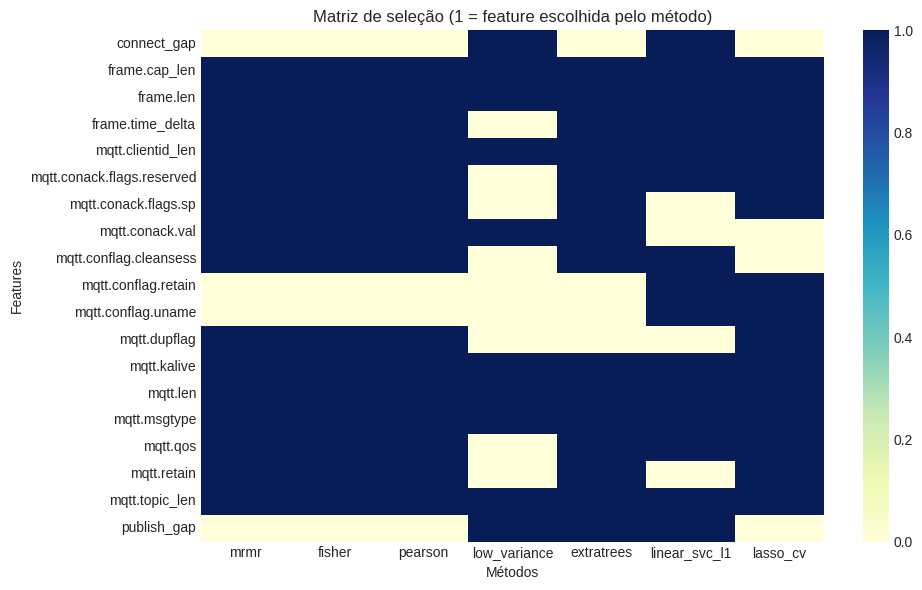

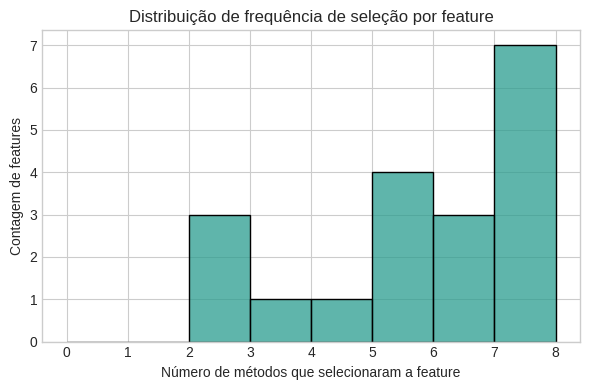

In [60]:
# Matriz de seleção de features (frequência por método)
selection_map = {
    "mrmr": set(feature_sets.get("mrmr", [])),
    "fisher": set(feature_sets.get("fisher", [])),
    "pearson": set(feature_sets.get("pearson", [])),
    "low_variance": set(feature_sets.get("low_variance", [])),
    "extratrees": set(feature_sets.get("extratrees", [])),
    "linear_svc_l1": set(feature_sets.get("linear_svc_l1", [])),
    "lasso_cv": set(feature_sets.get("lasso_cv", []))
}
all_feats = sorted({f for feats in selection_map.values() for f in feats})
selection_df = pd.DataFrame({m: [1 if f in feats else 0 for f in all_feats] for m, feats in selection_map.items()}, index=all_feats)
selection_df['times_selected'] = selection_df.sum(axis=1)
print(selection_df['times_selected'].sort_values(ascending=False).head(20))
plt.figure(figsize=(10, max(6, len(all_feats)*0.15)))
sns.heatmap(selection_df.drop(columns=['times_selected']), cmap='YlGnBu', cbar=True, annot=False)
plt.title('Matriz de seleção (1 = feature escolhida pelo método)')
plt.xlabel('Métodos')
plt.ylabel('Features')
plt.tight_layout()
plt.show()
plt.figure(figsize=(6, 4))
sns.histplot(selection_df['times_selected'], bins=range(0, selection_df['times_selected'].max()+2), kde=False, color='#2a9d8f')
plt.title('Distribuição de frequência de seleção por feature')
plt.xlabel('Número de métodos que selecionaram a feature')
plt.ylabel('Contagem de features')
plt.tight_layout()
plt.show()

## Resumo final: consenso de features
Contagem de aparições de cada feature nos métodos de seleção e matriz de presença (feature × método).

,Feature,Num Métodos,Métodos
1,frame.cap_len,7,"mRMR, Fisher, Pearson, LowVariance, ExtraTrees..."
2,frame.len,7,"mRMR, Fisher, Pearson, LowVariance, ExtraTrees..."
3,mqtt.clientid_len,7,"mRMR, Fisher, Pearson, LowVariance, ExtraTrees..."
11,mqtt.kalive,7,"mRMR, Fisher, Pearson, LowVariance, ExtraTrees..."
12,mqtt.len,7,"mRMR, Fisher, Pearson, LowVariance, ExtraTrees..."
13,mqtt.msgtype,7,"mRMR, Fisher, Pearson, LowVariance, ExtraTrees..."
16,mqtt.topic_len,7,"mRMR, Fisher, Pearson, LowVariance, ExtraTrees..."
0,frame.time_delta,6,"mRMR, Fisher, Pearson, ExtraTrees, LinearSVC_L..."
4,mqtt.conack.flags.reserved,6,"mRMR, Fisher, Pearson, ExtraTrees, LinearSVC_L..."
14,mqtt.qos,6,"mRMR, Fisher, Pearson, ExtraTrees, LinearSVC_L..."



Resumo:
Features únicas com pelo menos 1 seleção: 19
Features selecionadas por 4+ métodos: 15
Features selecionadas por todos os métodos (7): 7


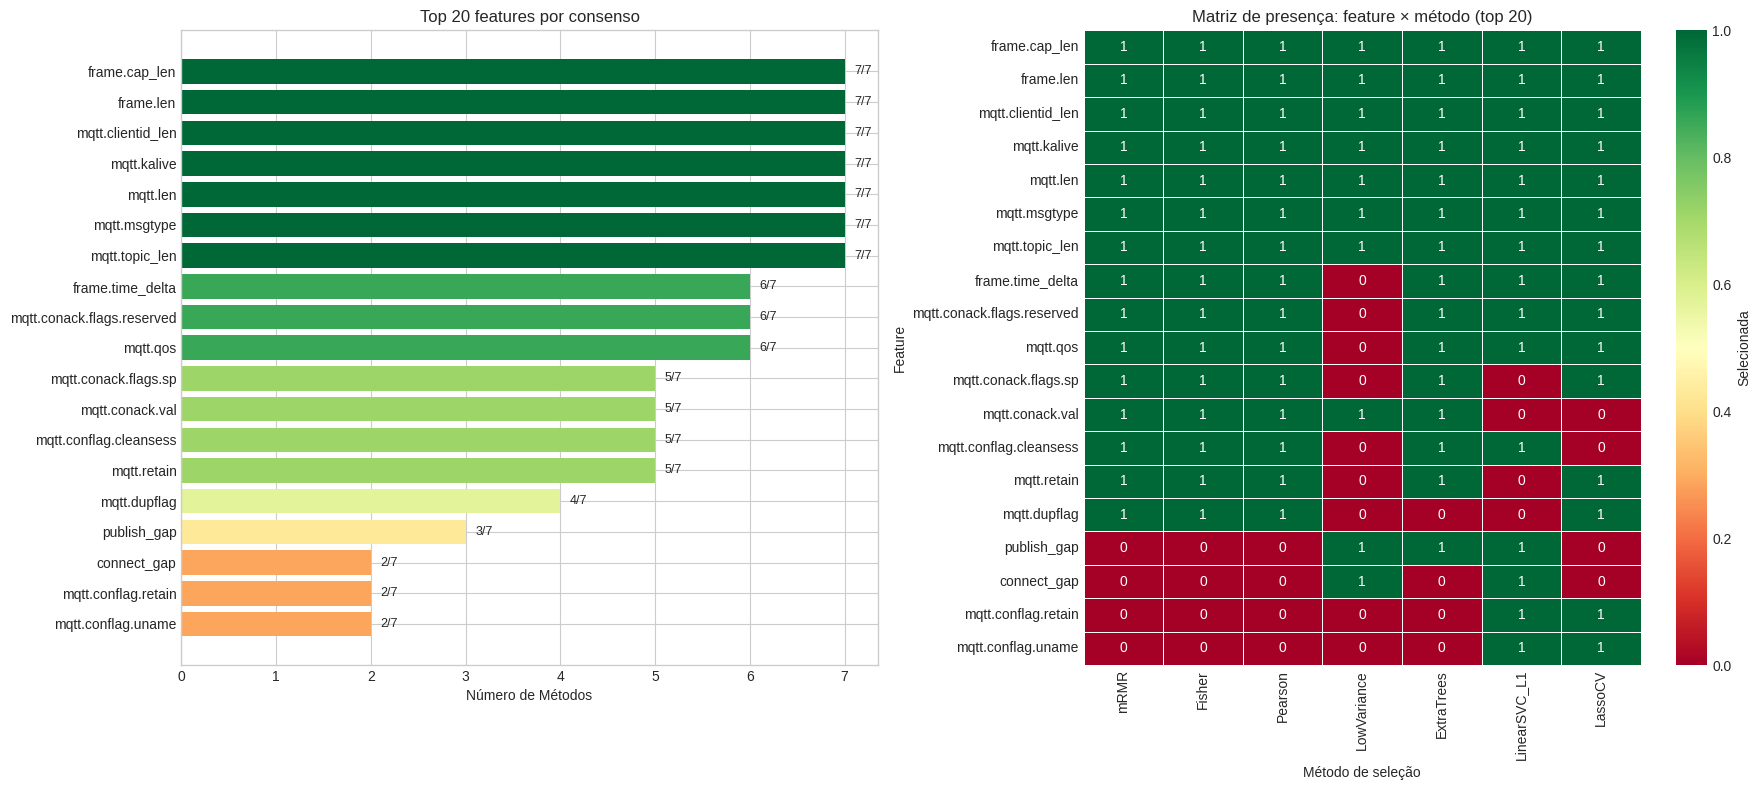

In [61]:
# Análise final de consenso de features (após todas as seleções e avaliações)
selectors = {
    "mRMR": globals().get('mrmr_selected_features', globals().get('mrmr_selected', [])),
    "Fisher": globals().get('fisher_selected', []),
    "Pearson": globals().get('pearson_selected', []),
    "LowVariance": globals().get('features_mantidas', []),
    "ExtraTrees": globals().get('extratree_selected', []),
    "LinearSVC_L1": globals().get('svc_selected', []),
    "LassoCV": globals().get('lasso_selected', [])
}
selectors = {k: v for k, v in selectors.items() if v}
if not selectors:
    print("Nenhum conjunto de features encontrado. Execute os passos de seleção antes desta célula.")
else:
    feature_counts = []
    for feature in X.columns:
        methods_hit = [m for m, feats in selectors.items() if feature in feats]
        if methods_hit:
            feature_counts.append({"Feature": feature, "Num Métodos": len(methods_hit), "Métodos": ", ".join(methods_hit)})
    consensus_df = pd.DataFrame(feature_counts).sort_values(["Num Métodos", "Feature"], ascending=[False, True])
    display(consensus_df.head(30))
    print("\nResumo:")
    print(f"Features únicas com pelo menos 1 seleção: {len(consensus_df)}")
    print(f"Features selecionadas por 4+ métodos: {(consensus_df['Num Métodos'] >= 4).sum()}")
    print(f"Features selecionadas por todos os métodos ({len(selectors)}): {(consensus_df['Num Métodos'] == len(selectors)).sum()}")
    top_features = consensus_df.head(20)["Feature"].tolist()
    presence_matrix = pd.DataFrame(index=top_features, columns=list(selectors.keys()))
    for feat in presence_matrix.index:
        for method, feats in selectors.items():
            presence_matrix.loc[feat, method] = 1 if feat in feats else 0
    presence_matrix = presence_matrix.astype(int)
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    ax1 = axes[0]
    bars = ax1.barh(range(len(consensus_df.head(20))), consensus_df.head(20)['Num Métodos'].values, color=plt.cm.RdYlGn(consensus_df.head(20)['Num Métodos'].values / len(selectors)))
    ax1.set_yticks(range(len(consensus_df.head(20))))
    ax1.set_yticklabels(consensus_df.head(20)['Feature'].values)
    ax1.invert_yaxis()
    ax1.set_xlabel('Número de Métodos')
    ax1.set_title('Top 20 features por consenso')
    for bar, count in zip(bars, consensus_df.head(20)['Num Métodos'].values):
        ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f"{count}/{len(selectors)}", va='center', fontsize=9)
    ax2 = axes[1]
    sns.heatmap(presence_matrix, cmap='RdYlGn', center=0.5, annot=True, fmt='d', linewidths=0.5, ax=ax2, cbar_kws={'label': 'Selecionada'})
    ax2.set_title('Matriz de presença: feature × método (top 20)')
    ax2.set_xlabel('Método de seleção')
    ax2.set_ylabel('Feature')
    plt.tight_layout()
    plt.show()

## Seleção final de features (consenso + performance)
Combina frequência de seleção entre métodos e a acurácia obtida pelo melhor modelo de cada seletor para ranquear as features recomendadas.

In [62]:
# Recomendar features combinando consenso e performance
selectors = {
    "mRMR": globals().get('mrmr_selected_features', globals().get('mrmr_selected', [])),
    "Fisher": globals().get('fisher_selected', []),
    "Pearson": globals().get('pearson_selected', []),
    "LowVariance": globals().get('features_mantidas', []),
    "ExtraTrees": globals().get('extratree_selected', []),
    "LinearSVC_L1": globals().get('svc_selected', []),
    "LassoCV": globals().get('lasso_selected', [])
}
selectors = {k: v for k, v in selectors.items() if v}
if 'results_df' not in globals():
    print("results_df não encontrado; execute o bloco de avaliação antes desta célula.")
elif not selectors:
    print("Nenhum conjunto de features encontrado; execute as seleções antes desta célula.")
else:
    # Peso por método = melhor acurácia obtida pelo método
    acc_weights = {}
    if 'results_df' in globals():
        best_per_set = results_df.loc[results_df.groupby('feature_set')["accuracy"].idxmax()]
        for _, row in best_per_set.iterrows():
            acc_weights[row['feature_set']] = row['accuracy']
    # Montar tabela
    rows = []
    num_methods = len(selectors)
    for feat in X.columns:
        methods_hit = [m for m, feats in selectors.items() if feat in feats]
        if not methods_hit:
            continue
        weight = sum(acc_weights.get(m.lower() if m.lower() in acc_weights else m, 0) for m in methods_hit)
        rows.append({
            "Feature": feat,
            "Num Métodos": len(methods_hit),
            "Métodos": ", ".join(methods_hit),
            "Score": len(methods_hit) + weight
        })
    ranked = pd.DataFrame(rows).sort_values(["Score", "Num Métodos", "Feature"], ascending=[False, False, True])
    display(ranked.head(30))
    recommended = ranked.head(20)["Feature"].tolist()
    print("\n🔎 Features recomendadas (top 20):")
    for i, f in enumerate(recommended, 1):
        print(f" {i:02d}. {f}")
    print("\nResumo:")
    print(f"Features únicas consideradas: {len(ranked)}")
    print(f"Selecionadas por 4+ métodos: {(ranked['Num Métodos'] >= 4).sum()}")
    print(f"Selecionadas por todos os métodos ({num_methods}): {(ranked['Num Métodos'] == num_methods).sum()}")

,Feature,Num Métodos,Métodos,Score
1,frame.cap_len,7,"mRMR, Fisher, Pearson, LowVariance, ExtraTrees...",10.877906
2,frame.len,7,"mRMR, Fisher, Pearson, LowVariance, ExtraTrees...",10.877906
3,mqtt.clientid_len,7,"mRMR, Fisher, Pearson, LowVariance, ExtraTrees...",10.877906
11,mqtt.kalive,7,"mRMR, Fisher, Pearson, LowVariance, ExtraTrees...",10.877906
12,mqtt.len,7,"mRMR, Fisher, Pearson, LowVariance, ExtraTrees...",10.877906
13,mqtt.msgtype,7,"mRMR, Fisher, Pearson, LowVariance, ExtraTrees...",10.877906
16,mqtt.topic_len,7,"mRMR, Fisher, Pearson, LowVariance, ExtraTrees...",10.877906
0,frame.time_delta,6,"mRMR, Fisher, Pearson, ExtraTrees, LinearSVC_L...",9.877906
4,mqtt.conack.flags.reserved,6,"mRMR, Fisher, Pearson, ExtraTrees, LinearSVC_L...",9.877906
14,mqtt.qos,6,"mRMR, Fisher, Pearson, ExtraTrees, LinearSVC_L...",9.877906



🔎 Features recomendadas (top 20):
 01. frame.cap_len
 02. frame.len
 03. mqtt.clientid_len
 04. mqtt.kalive
 05. mqtt.len
 06. mqtt.msgtype
 07. mqtt.topic_len
 08. frame.time_delta
 09. mqtt.conack.flags.reserved
 10. mqtt.qos
 11. mqtt.conack.flags.sp
 12. mqtt.conack.val
 13. mqtt.conflag.cleansess
 14. mqtt.retain
 15. mqtt.dupflag
 16. publish_gap
 17. connect_gap
 18. mqtt.conflag.retain
 19. mqtt.conflag.uname

Resumo:
Features únicas consideradas: 19
Selecionadas por 4+ métodos: 15
Selecionadas por todos os métodos (7): 7


## Validação cruzada por seletor (sem vazamento)
Reexecuta a seleção em cada fold (`StratifiedKFold`) antes de treinar o modelo, evitando vazamento. Avaliação com RandomForest padrão do notebook.

100%|██████████| 15/15 [00:04<00:00,  3.65it/s]



Resultados de validação cruzada por seletor (5-fold, RF):


,selector,accuracy_mean,accuracy_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std
5,LassoCV,0.974267,0.001209,0.974951,0.001174,0.973757,0.001232,0.974201,0.001213
2,Pearson,0.974256,0.001211,0.974936,0.001160,0.973748,0.001241,0.974191,0.001216
1,Fisher,0.974256,0.001211,0.974936,0.001160,0.973748,0.001241,0.974191,0.001216
3,ExtraTrees,0.974182,0.001255,0.974861,0.001205,0.973675,0.001285,0.974117,0.001260
4,LinearSVC_L1,0.974161,0.001135,0.974845,0.001084,0.973651,0.001165,0.974095,0.001140
0,mRMR,0.974140,0.001165,0.974815,0.001111,0.973634,0.001196,0.974074,0.001170
6,LowVariance,0.974045,0.001149,0.974709,0.001098,0.973544,0.001180,0.973979,0.001154


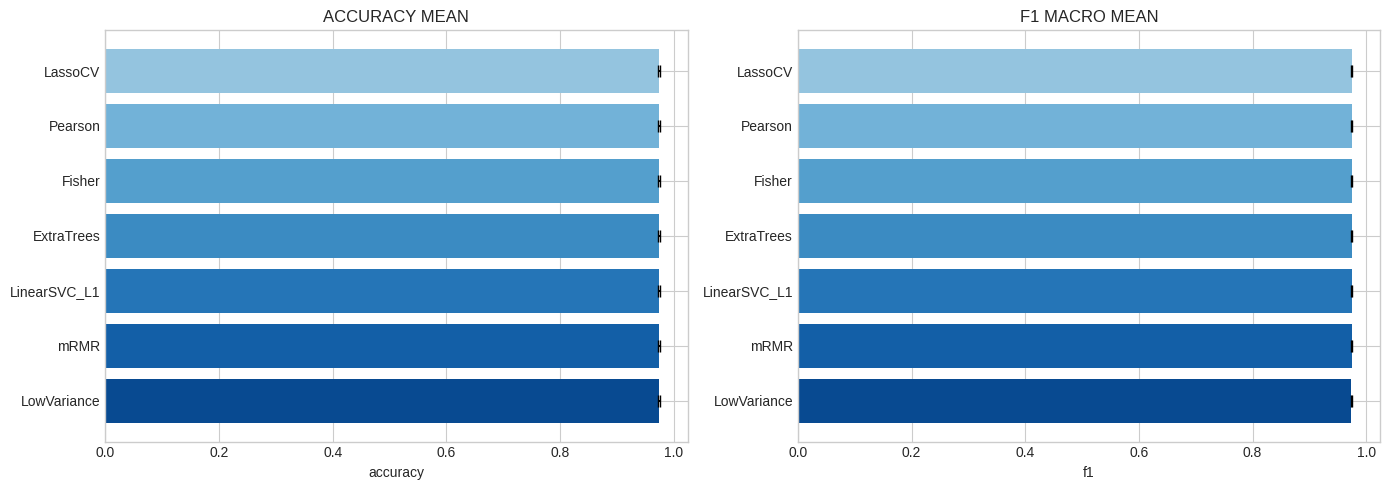

In [63]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Seletores reexecutados por fold para evitar vazamento

def _selector_functions():
    def select_mrmr(X_tr, y_tr):
        if not globals().get('MRMR_AVAILABLE', False):
            return []
        try:
            K_mrmr_local = globals().get('K_mrmr', globals().get('K', 15))
            K_use = min(K_mrmr_local, X_tr.shape[1])
            return mrmr_classif(X_tr, y_tr, K=K_use)
        except Exception as e:
            print(f"[mRMR] fallback por erro: {e}")
            return []

    def select_fisher(X_tr, y_tr):
        scores = fisher_score(X_tr, y_tr)
        df_sel = pd.DataFrame({'feature': X_tr.columns, 'fisher_score': scores}).sort_values('fisher_score', ascending=False)
        return df_sel.head(min(globals().get('K_fisher', 15), len(df_sel)))['feature'].tolist()

    def select_pearson(X_tr, y_tr):
        corrs = X_tr.apply(lambda col: np.corrcoef(col, y_tr)[0, 1])
        abs_corr = corrs.abs().fillna(0)
        return abs_corr.sort_values(ascending=False).head(min(globals().get('K_pearson', 15), len(abs_corr))).index.tolist()

    def select_extratrees(X_tr, y_tr):
        K_use = min(globals().get('K_tree', 15), X_tr.shape[1])
        model = ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1)
        model.fit(X_tr, y_tr)
        imp = pd.Series(model.feature_importances_, index=X_tr.columns)
        return imp.sort_values(ascending=False).head(K_use).index.tolist()

    def select_svc(X_tr, y_tr):
        K_use = min(globals().get('K_svc', 15), X_tr.shape[1])
        scaler_local = StandardScaler()
        X_scaled_tr = scaler_local.fit_transform(X_tr)
        svc_local = LinearSVC(C=0.1, penalty='l1', dual=False, max_iter=5000, random_state=42)
        svc_local.fit(X_scaled_tr, y_tr)
        coef_importance = np.mean(np.abs(svc_local.coef_), axis=0) if len(svc_local.coef_.shape) > 1 else np.abs(svc_local.coef_[0])
        imp = pd.Series(coef_importance, index=X_tr.columns)
        return imp.sort_values(ascending=False).head(K_use).index.tolist()

    def select_lasso(X_tr, y_tr):
        K_use = min(globals().get('K_lasso', 15), X_tr.shape[1])
        scaler_local = StandardScaler()
        X_scaled_tr = scaler_local.fit_transform(X_tr)
        lasso_local = LassoCV(cv=3, random_state=42, max_iter=10000, n_jobs=-1)
        lasso_local.fit(X_scaled_tr, y_tr)
        imp = pd.Series(np.abs(lasso_local.coef_), index=X_tr.columns)
        return imp.sort_values(ascending=False).head(K_use).index.tolist()

    def select_low_variance(X_tr, y_tr):
        selector_local = VarianceThreshold(threshold=0.0)
        selector_local.fit(X_tr)
        return X_tr.columns[selector_local.get_support(indices=True)].tolist()

    return {
        "mRMR": select_mrmr,
        "Fisher": select_fisher,
        "Pearson": select_pearson,
        "ExtraTrees": select_extratrees,
        "LinearSVC_L1": select_svc,
        "LassoCV": select_lasso,
        "LowVariance": select_low_variance,
    }


def evaluate_selectors_cv(X_full, y_full, selectors=None, cv_splits=5, model_factory=None):
    selectors = selectors or _selector_functions()
    if model_factory is None:
        model_factory = lambda: RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)

    records = []
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    for name, sel_fn in selectors.items():
        fold_metrics = {m: [] for m in ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']}
        for train_idx, val_idx in skf.split(X_full, y_full):
            X_tr, X_val = X_full.iloc[train_idx], X_full.iloc[val_idx]
            y_tr, y_val = y_full[train_idx], y_full[val_idx]

            cols = sel_fn(X_tr, y_tr)
            if not cols:
                continue
            clf = model_factory()
            clf.fit(X_tr[cols], y_tr)
            y_pred = clf.predict(X_val[cols])
            fold_metrics['accuracy'].append(accuracy_score(y_val, y_pred))
            fold_metrics['precision_macro'].append(precision_score(y_val, y_pred, average='macro', zero_division=0))
            fold_metrics['recall_macro'].append(recall_score(y_val, y_pred, average='macro', zero_division=0))
            fold_metrics['f1_macro'].append(f1_score(y_val, y_pred, average='macro', zero_division=0))

        if fold_metrics['accuracy']:
            record = {'selector': name}
            for metric, vals in fold_metrics.items():
                record[f'{metric}_mean'] = float(np.mean(vals))
                record[f'{metric}_std'] = float(np.std(vals))
            records.append(record)
    return pd.DataFrame(records)


# Executar CV para todos os seletores
selector_funcs = _selector_functions()
cv_selector_results = evaluate_selectors_cv(X, y, selectors=selector_funcs, cv_splits=5)
cv_selector_results = cv_selector_results.sort_values('accuracy_mean', ascending=False)
print("\nResultados de validação cruzada por seletor (5-fold, RF):")
display(cv_selector_results)

# Gráficos comparativos (acurácia e F1)
if not cv_selector_results.empty:
    metrics_to_plot = ['accuracy_mean', 'f1_macro_mean']
    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(14, 5))
    for ax, metric in zip(axes, metrics_to_plot):
        err_col = metric.replace('_mean', '_std')
        ax.barh(cv_selector_results['selector'], cv_selector_results[metric],
                xerr=cv_selector_results[err_col], color=plt.cm.Blues(np.linspace(0.4, 0.9, len(cv_selector_results))),
                capsize=4)
        ax.invert_yaxis()
        ax.set_title(metric.replace('_', ' ').upper())
        ax.set_xlabel(metric.split('_')[0])
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum resultado de CV gerado (verifique os seletores).")

## Validação cruzada por seletor e por modelo (sem vazamento)
Cada seletor é reexecutado em cada fold (`StratifiedKFold`) e avaliado com vários modelos (RF, Regressão Logística, Naive Bayes, SVM, Decision Tree). Métricas: accuracy, precision, recall, F1, log loss, MCC. Valores numéricos são anotados nos gráficos.

In [64]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    matthews_corrcoef,
)

# Modelos a avaliar (factories para não compartilhar estado entre folds)
model_factories = {
    "RandomForest": lambda: RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1),
    "LogisticRegression": lambda: LogisticRegression(max_iter=2000, n_jobs=-1, solver="lbfgs"),
    "GaussianNB": lambda: GaussianNB(),
    "SVM_RBF": lambda: SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42),
    "DecisionTree": lambda: DecisionTreeClassifier(random_state=42),
}

# Seletores reexecutados por fold

def _selector_functions():
    def select_mrmr(X_tr, y_tr):
        if not globals().get("MRMR_AVAILABLE", False):
            return []
        try:
            K_mrmr_local = globals().get("K_mrmr", globals().get("K", 15))
            K_use = min(K_mrmr_local, X_tr.shape[1])
            return mrmr_classif(X_tr, y_tr, K=K_use)
        except Exception as e:
            print(f"[mRMR] fallback por erro: {e}")
            return []

    def select_fisher(X_tr, y_tr):
        scores = fisher_score(X_tr, y_tr)
        df_sel = pd.DataFrame({"feature": X_tr.columns, "fisher_score": scores}).sort_values(
            "fisher_score", ascending=False
        )
        return df_sel.head(min(globals().get("K_fisher", 15), len(df_sel))) ["feature"].tolist()

    def select_pearson(X_tr, y_tr):
        corrs = X_tr.apply(lambda col: np.corrcoef(col, y_tr)[0, 1])
        abs_corr = corrs.abs().fillna(0)
        return abs_corr.sort_values(ascending=False).head(min(globals().get("K_pearson", 15), len(abs_corr))).index.tolist()

    def select_extratrees(X_tr, y_tr):
        K_use = min(globals().get("K_tree", 15), X_tr.shape[1])
        model = ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1)
        model.fit(X_tr, y_tr)
        imp = pd.Series(model.feature_importances_, index=X_tr.columns)
        return imp.sort_values(ascending=False).head(K_use).index.tolist()

    def select_svc(X_tr, y_tr):
        K_use = min(globals().get("K_svc", 15), X_tr.shape[1])
        scaler_local = StandardScaler()
        X_scaled_tr = scaler_local.fit_transform(X_tr)
        svc_local = LinearSVC(C=0.1, penalty="l1", dual=False, max_iter=5000, random_state=42)
        svc_local.fit(X_scaled_tr, y_tr)
        coef_importance = np.mean(np.abs(svc_local.coef_), axis=0) if len(svc_local.coef_.shape) > 1 else np.abs(svc_local.coef_[0])
        imp = pd.Series(coef_importance, index=X_tr.columns)
        return imp.sort_values(ascending=False).head(K_use).index.tolist()

    def select_lasso(X_tr, y_tr):
        K_use = min(globals().get("K_lasso", 15), X_tr.shape[1])
        scaler_local = StandardScaler()
        X_scaled_tr = scaler_local.fit_transform(X_tr)
        lasso_local = LassoCV(cv=3, random_state=42, max_iter=10000, n_jobs=-1)
        lasso_local.fit(X_scaled_tr, y_tr)
        imp = pd.Series(np.abs(lasso_local.coef_), index=X_tr.columns)
        return imp.sort_values(ascending=False).head(K_use).index.tolist()

    def select_low_variance(X_tr, y_tr):
        selector_local = VarianceThreshold(threshold=0.0)
        selector_local.fit(X_tr)
        return X_tr.columns[selector_local.get_support(indices=True)].tolist()

    return {
        "mRMR": select_mrmr,
        "Fisher": select_fisher,
        "Pearson": select_pearson,
        "ExtraTrees": select_extratrees,
        "LinearSVC_L1": select_svc,
        "LassoCV": select_lasso,
        "LowVariance": select_low_variance,
    }


def evaluate_selector_cv(selector_name, selector_fn, X_full, y_full, cv_splits=5):
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    rows = []
    for model_name, factory in model_factories.items():
        metrics_acc = []
        metrics_prec = []
        metrics_rec = []
        metrics_f1 = []
        metrics_ll = []
        metrics_mcc = []

        for train_idx, val_idx in skf.split(X_full, y_full):
            X_tr, X_val = X_full.iloc[train_idx], X_full.iloc[val_idx]
            y_tr, y_val = y_full[train_idx], y_full[val_idx]

            cols = selector_fn(X_tr, y_tr)
            if not cols:
                continue
            model = factory()
            model.fit(X_tr[cols], y_tr)
            y_pred = model.predict(X_val[cols])

            # Probabilidades para log loss (quando disponíveis)
            if hasattr(model, "predict_proba"):
                y_proba = model.predict_proba(X_val[cols])
            elif hasattr(model, "decision_function"):
                df_scores = model.decision_function(X_val[cols])
                # Converter para probabilidades aproximadas via softmax
                if df_scores.ndim == 1:
                    df_scores = np.vstack([-df_scores, df_scores]).T
                y_proba = np.exp(df_scores) / np.exp(df_scores).sum(axis=1, keepdims=True)
            else:
                y_proba = None

            metrics_acc.append(accuracy_score(y_val, y_pred))
            metrics_prec.append(precision_score(y_val, y_pred, average="macro", zero_division=0))
            metrics_rec.append(recall_score(y_val, y_pred, average="macro", zero_division=0))
            metrics_f1.append(f1_score(y_val, y_pred, average="macro", zero_division=0))
            metrics_mcc.append(matthews_corrcoef(y_val, y_pred))
            if y_proba is not None:
                try:
                    metrics_ll.append(log_loss(y_val, y_proba))
                except Exception:
                    pass

        if metrics_acc:
            rows.append({
                "selector": selector_name,
                "model": model_name,
                "accuracy_mean": float(np.mean(metrics_acc)),
                "accuracy_std": float(np.std(metrics_acc)),
                "precision_mean": float(np.mean(metrics_prec)),
                "precision_std": float(np.std(metrics_prec)),
                "recall_mean": float(np.mean(metrics_rec)),
                "recall_std": float(np.std(metrics_rec)),
                "f1_mean": float(np.mean(metrics_f1)),
                "f1_std": float(np.std(metrics_f1)),
                "mcc_mean": float(np.mean(metrics_mcc)),
                "mcc_std": float(np.std(metrics_mcc)),
                "logloss_mean": float(np.mean(metrics_ll)) if metrics_ll else np.nan,
                "logloss_std": float(np.std(metrics_ll)) if metrics_ll else np.nan,
            })
    return pd.DataFrame(rows)


def plot_selector_results(df_sel, title):
    if df_sel.empty:
        print("Sem resultados para plotar.")
        return
    metrics_to_plot = [
        ("accuracy_mean", "Accuracy"),
        ("precision_mean", "Precision"),
        ("recall_mean", "Recall"),
        ("f1_mean", "F1"),
        ("mcc_mean", "MCC"),
        ("logloss_mean", "Log Loss"),
    ]
    ncols = 3
    nrows = int(np.ceil(len(metrics_to_plot) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
    axes = axes.flatten()
    for ax, (metric, label) in zip(axes, metrics_to_plot):
        err_col = metric.replace("_mean", "_std")
        vals = df_sel[metric]
        errs = df_sel[err_col]
        bars = ax.barh(df_sel["model"], vals, xerr=errs, color=plt.cm.Blues(np.linspace(0.4, 0.9, len(df_sel))), capsize=4)
        ax.invert_yaxis()
        ax.set_title(label)
        ax.set_xlabel(label if label != "Log Loss" else "Lower is better")
        for bar, val in zip(bars, vals):
            ax.text(bar.get_width() + (0.01 if np.isfinite(val) else 0), bar.get_y() + bar.get_height() / 2,
                    f"{val:.3f}" if np.isfinite(val) else "nan", va="center", fontsize=9)
    # Hide unused subplots
    for j in range(len(metrics_to_plot), len(axes)):
        axes[j].axis("off")
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


selector_funcs = _selector_functions()
print("Seletores disponíveis:", list(selector_funcs.keys()))

Seletores disponíveis: ['mRMR', 'Fisher', 'Pearson', 'ExtraTrees', 'LinearSVC_L1', 'LassoCV', 'LowVariance']


### Agrupando os seletores de características para hard votting

In [ ]:
def voting_selector

### Criando um classificador de voting

In [59]:
# hard_voting = VotingClassifier (
#     estimators=[('mrmr', selec)]
# )

In [2]:
# Avaliar mRMR
sel_name = "mRMR"
df_mrmr = evaluate_selector_cv(sel_name, selector_funcs[sel_name], X, y, cv_splits=5)
display(df_mrmr)
plot_selector_results(df_mrmr, f"{sel_name} - Resultados CV")

NameError: name 'X' is not defined

In [ ]:
# Avaliar Fisher
sel_name = "Fisher"
df_fisher_cv = evaluate_selector_cv(sel_name, selector_funcs[sel_name], X, y, cv_splits=5)
display(df_fisher_cv)
plot_selector_results(df_fisher_cv, f"{sel_name} - Resultados CV")

,selector,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,Pearson,RandomForest,0.970050,0.000888,0.970468,0.000838,0.969664,0.000927,0.969984,0.000892,0.940131,0.001757,0.256307,0.010215
1,Pearson,LogisticRegression,0.924798,0.001722,0.934798,0.001489,0.922081,0.001766,0.923934,0.001760,0.856784,0.003245,0.171345,0.003212
2,Pearson,GaussianNB,0.923435,0.001799,0.932908,0.001625,0.920783,0.001835,0.922585,0.001834,0.853605,0.003452,2.585310,0.079713
3,Pearson,SVM_RBF,0.926288,0.001726,0.937822,0.001277,0.923375,0.001792,0.925355,0.001776,0.861076,0.003078,0.222613,0.003701
4,Pearson,DecisionTree,0.966996,0.001083,0.967146,0.001060,0.966771,0.001107,0.966936,0.001086,0.933917,0.002165,0.656284,0.028932


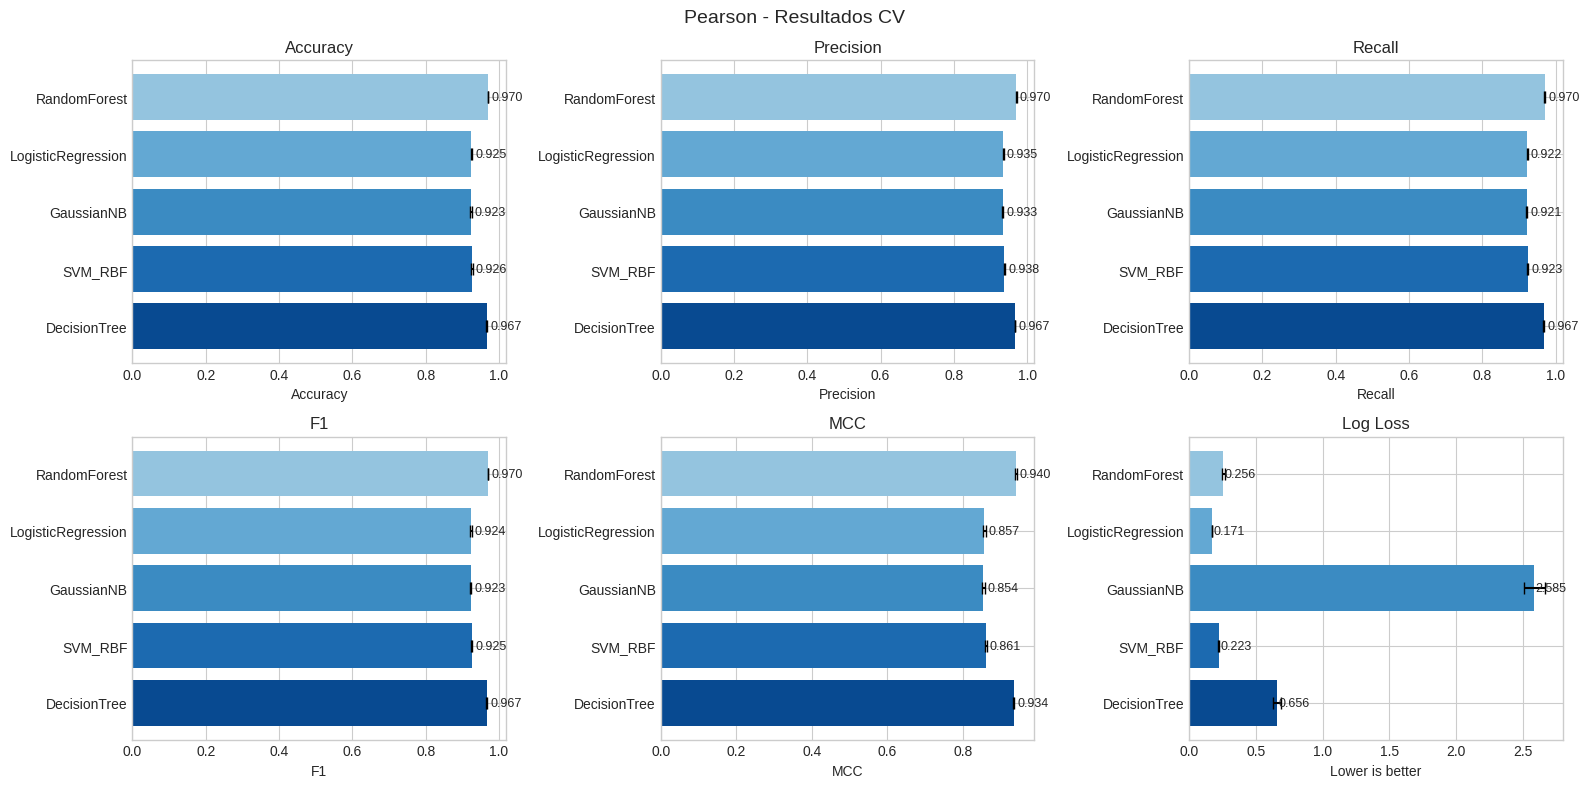

In [ ]:
# Avaliar Pearson
sel_name = "Pearson"
df_pearson_cv = evaluate_selector_cv(sel_name, selector_funcs[sel_name], X, y, cv_splits=5)
display(df_pearson_cv)
plot_selector_results(df_pearson_cv, f"{sel_name} - Resultados CV")

,selector,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,ExtraTrees,RandomForest,0.970071,0.000918,0.970490,0.000867,0.969684,0.000957,0.970005,0.000923,0.940174,0.001817,0.259296,0.010010
1,ExtraTrees,LogisticRegression,0.924671,0.001706,0.934621,0.001480,0.921960,0.001748,0.923808,0.001743,0.856487,0.003218,0.171352,0.003228
2,ExtraTrees,GaussianNB,0.923435,0.001799,0.932908,0.001625,0.920783,0.001835,0.922585,0.001834,0.853605,0.003452,2.723560,0.072391
3,ExtraTrees,SVM_RBF,0.926288,0.001726,0.937822,0.001277,0.923375,0.001792,0.925355,0.001776,0.861076,0.003078,0.222534,0.003673
4,ExtraTrees,DecisionTree,0.967081,0.001055,0.967234,0.001033,0.966852,0.001078,0.967020,0.001059,0.934087,0.002109,0.653237,0.024619


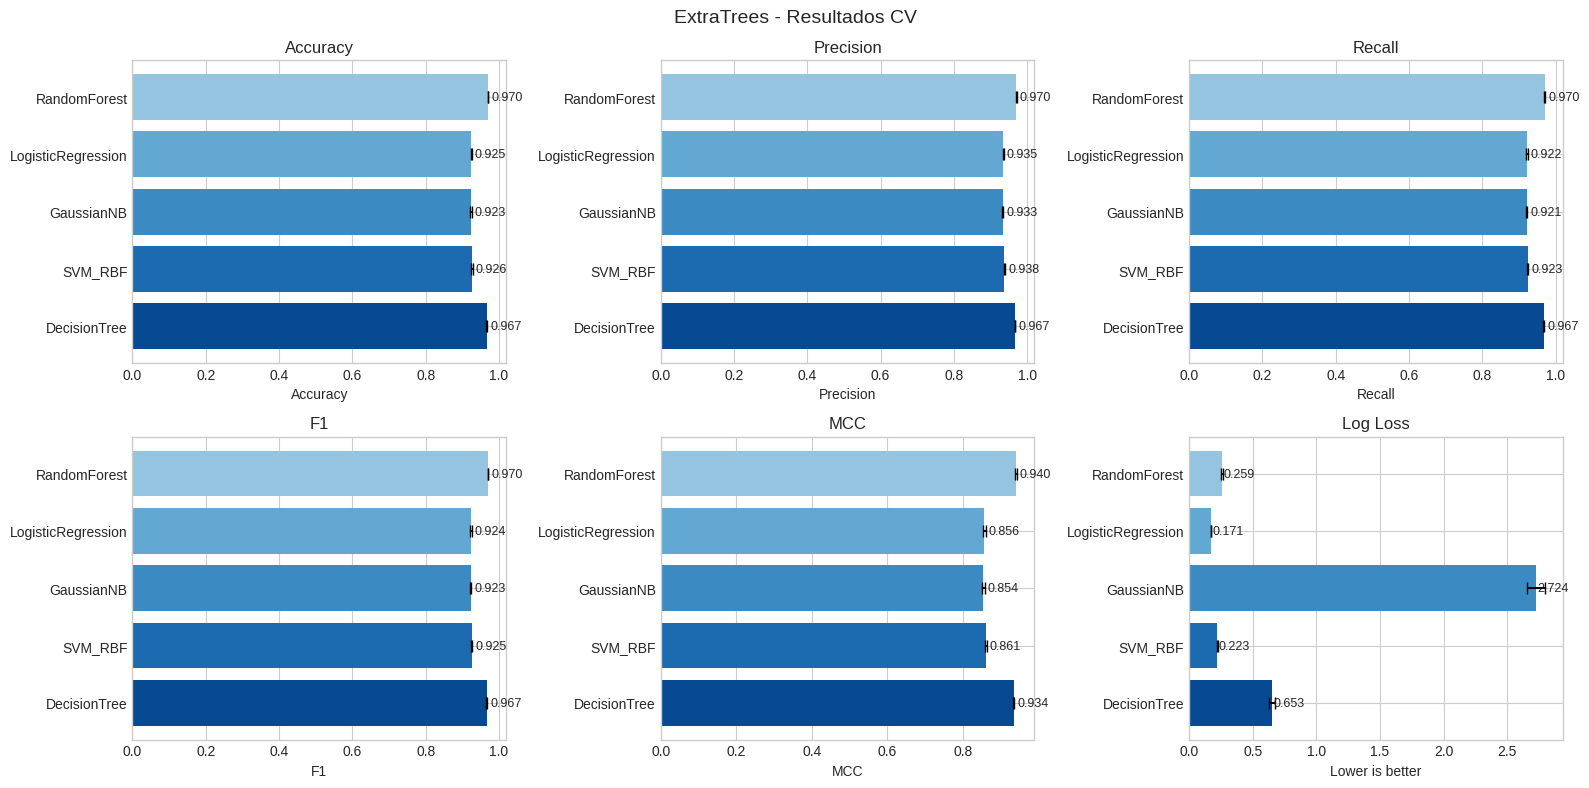

In [ ]:
# Avaliar ExtraTrees
sel_name = "ExtraTrees"
df_extratrees_cv = evaluate_selector_cv(sel_name, selector_funcs[sel_name], X, y, cv_splits=5)
display(df_extratrees_cv)
plot_selector_results(df_extratrees_cv, f"{sel_name} - Resultados CV")

,selector,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,LinearSVC_L1,RandomForest,0.970135,0.000899,0.970561,0.000846,0.969744,0.000940,0.970068,0.000904,0.940305,0.001779,0.258265,0.011045
1,LinearSVC_L1,LogisticRegression,0.924734,0.001706,0.934727,0.001480,0.922018,0.001748,0.923870,0.001743,0.856650,0.003219,0.171343,0.003160
2,LinearSVC_L1,GaussianNB,0.923424,0.001792,0.932894,0.001619,0.920773,0.001828,0.922574,0.001826,0.853581,0.003438,2.253055,0.097253
3,LinearSVC_L1,SVM_RBF,0.925622,0.001834,0.937332,0.001354,0.922683,0.001905,0.924670,0.001889,0.859890,0.003269,0.222550,0.003741
4,LinearSVC_L1,DecisionTree,0.967007,0.001062,0.967159,0.001040,0.966779,0.001085,0.966946,0.001066,0.933938,0.002124,0.655903,0.027174


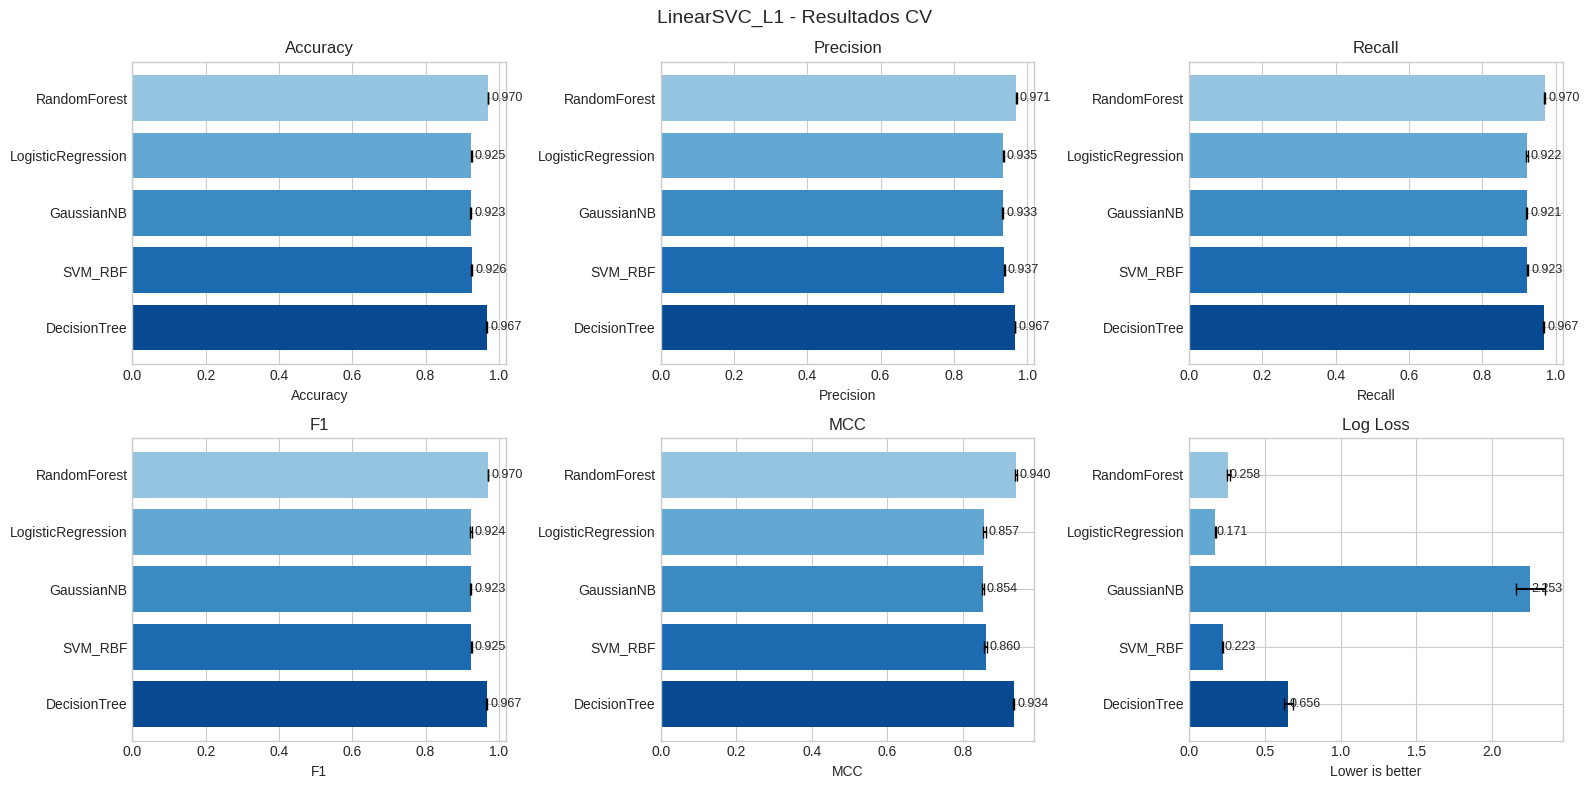

In [ ]:
# Avaliar LinearSVC (L1)
sel_name = "LinearSVC_L1"
df_svc_cv = evaluate_selector_cv(sel_name, selector_funcs[sel_name], X, y, cv_splits=5)
display(df_svc_cv)
plot_selector_results(df_svc_cv, f"{sel_name} - Resultados CV")

,selector,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,logloss_mean,logloss_std
0,LassoCV,RandomForest,0.970092,0.000898,0.970513,0.000845,0.969705,0.000938,0.970026,0.000903,0.940217,0.001776,0.258255,0.011541
1,LassoCV,LogisticRegression,0.924787,0.001690,0.934796,0.001462,0.922069,0.001733,0.923923,0.001727,0.856770,0.003184,0.171404,0.003157
2,LassoCV,GaussianNB,0.923424,0.001792,0.932894,0.001619,0.920773,0.001828,0.922574,0.001826,0.853581,0.003438,2.164241,0.093102
3,LassoCV,SVM_RBF,0.925728,0.001490,0.937408,0.001101,0.922793,0.001550,0.924779,0.001534,0.860077,0.002659,0.222686,0.003633
4,LassoCV,DecisionTree,0.967007,0.001082,0.967155,0.001059,0.966783,0.001106,0.966946,0.001086,0.933937,0.002164,0.655903,0.028535


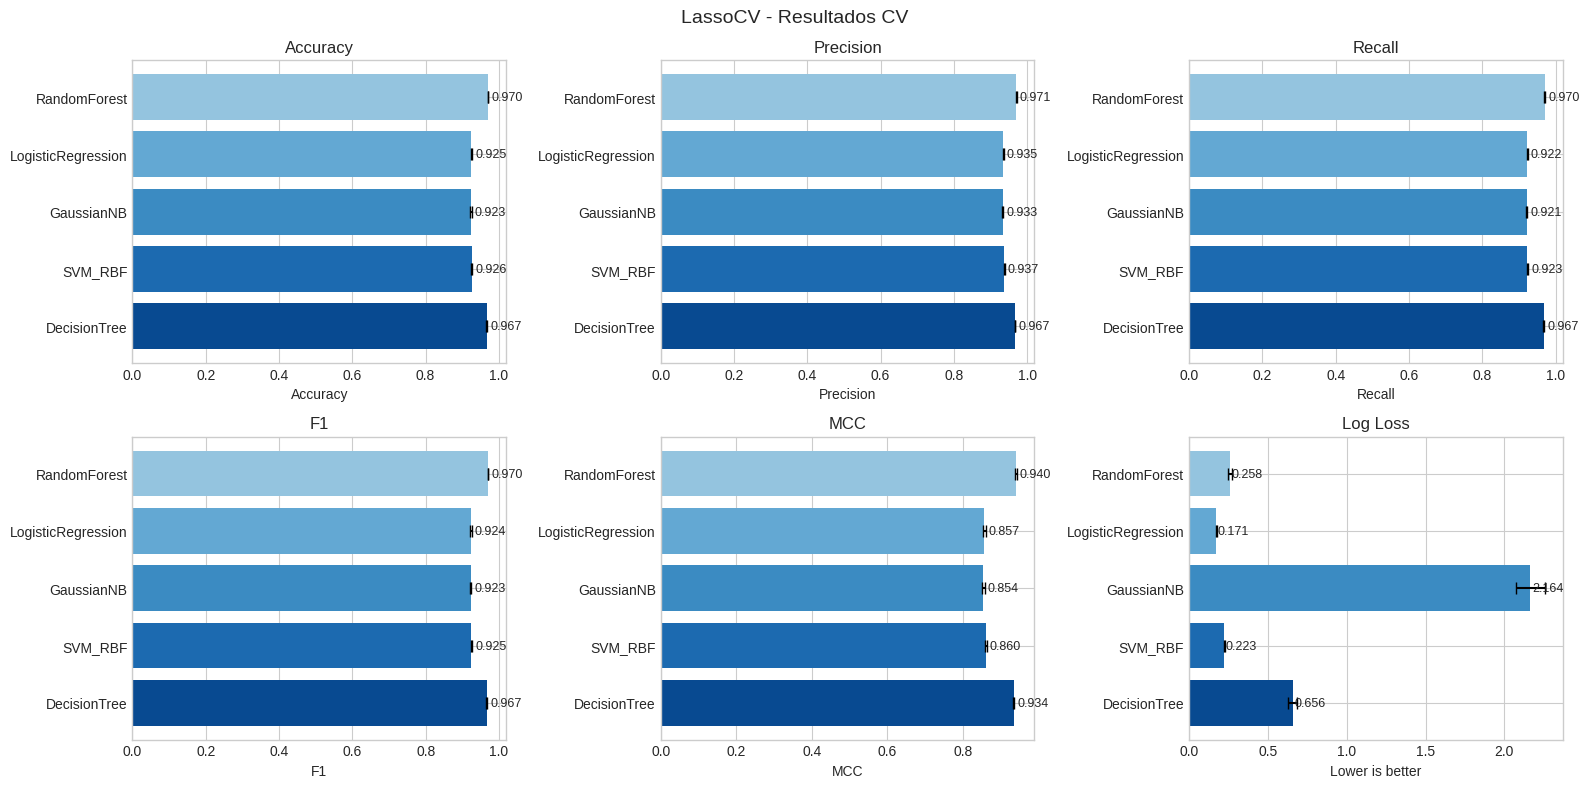

In [ ]:
# Avaliar LassoCV
sel_name = "LassoCV"
df_lasso_cv = evaluate_selector_cv(sel_name, selector_funcs[sel_name], X, y, cv_splits=5)
display(df_lasso_cv)
plot_selector_results(df_lasso_cv, f"{sel_name} - Resultados CV")